# 독립 실행 통합본

**이 파일 하나에 코드·상세 설명·실행·시각화·기존 실험 결과가 모두 들어 있습니다.** 기본 DEMO=True는 인공 데이터로 전체 흐름을 검증합니다. 실제 데이터는 DEMO=False로 바꾸고 원본 파일 경로를 설정하세요. 생성되는 `_runtime`과 출력 폴더는 자동 생성물이므로 별도로 복사할 필요가 없습니다.

## 이 통합본의 읽는 순서

1. 환경과 데이터 설정 — 기본값은 인공 데이터 DEMO
2. 전처리 → 그래프 → GNN 6종 → 학습 함수별 설명·코드
3. 클러스터링·IPW·SMOTE·WGAN-GP 상세 설명과 함수 코드
4. 실제 실행 결과 — 데이터 요약, 그래프, 6종 학습, 군집/증강 그림, 코드 검사
5. 기존 실제 데이터의 54개 GNN·72개 증강 실험 결과
6. 기존 실제 거래·증강 표본 그림과 감사 기록

이미 실행 결과와 그림을 저장해 두었으므로 실행하지 않고도 읽을 수 있습니다. 처음부터 다시 실행하면 기본 인공 데이터 결과가 재생성됩니다. 현재 출력에 보이는 임시 폴더 경로는 제작 시 실행 위치이며 실행 코드가 그 경로에 의존하지 않습니다.


# 거래 데이터 → 그래프 → GNN 6종 학습

**이 통합본 파일 하나를 다른 컴퓨터로 복사하세요.** 기존 프로젝트·체크포인트·절대 경로가 필요하지 않습니다. Python 3.11 또는 3.12 커널에서 이 노트북을 위에서부터 실행합니다.

1. 필요한 라이브러리 확인/설치
2. 예제 또는 원본 데이터 경로 설정
3. 설명 노트북의 함수 코드 준비
4. 데이터 전처리 → 그래프 생성 → 모델 학습 → 결과 비교

**기본값은 인공 예제 데이터와 CPU에서 6종을 한 에폭씩 실행하는 데모입니다.** 결과는 설치/동작 확인용이며 연구 성능이 아닙니다. 실제 데이터 학습은 `DEMO=False`로 바꾸세요. 그 상태에서 Run All하면 전체 전처리와 학습이 시작됩니다.

| 단계 | 입력 | 처리 | 출력 |
|---|---|---|---|
| 전처리 | 거래 CSV, 계좌 CSV, 패턴 TXT | 열/값 검사, 완전 중복 제거, 계좌 ID, 과거 이력, 피처 | `outputs/data/` DB·감사표·피처 |
| 그래프 | 정제 DB·피처 | 일별 노드/연결, 2홉 문맥, 19+17 피처 | `outputs/graphs/날짜/` 배열 |
| 학습 | 저장 그래프 | 학습 표본 선택, 6개 GNN, 검증 | `outputs/models/`, 비교 CSV |

전체 학습의 기본 설정은 원본 학습 거래 사용입니다. `sampling`은 `original`, `random_under`, `cluster_under` 중 선택합니다. 클러스터 모드는 새 17차원 거래 입력으로 군집을 적합하고, **검증 거래는 세 방식 모두 전체를 사용합니다.** 기존 연구의 18차원 군집/고정 클러스터 검증 표본과 다른 새 실행이므로 기존 결과를 그대로 재현한다고 해석하면 안 됩니다. 테스트 기간은 학습·검증에 사용하지 않습니다.

학습 다음에는 클러스터 표본 감사·시각화, 잠재공간 증강 비교·시각화, 코드 검사와 기존 실험 결과 비교를 이어서 실행합니다.


## 1. 라이브러리 준비

Jupyter가 없는 컴퓨터에서는 터미널에서 `python -m pip install notebook` 후 `python -m notebook`으로 시작할 수 있습니다. 설치 후 필요하면 커널을 재시작하세요. CPU로도 실행할 수 있지만 실제 대용량 실험은 GPU 사용을 권장합니다.

In [1]:
# 설치가 필요한 첫 실행에서만 True로 변경하세요. 현재 커널에 설치됩니다.
INSTALL_DEPENDENCIES = False
import sys, subprocess, importlib.util
packages = ['numpy>=1.26,<3', 'pandas>=2.1,<3', 'duckdb>=1.1,<2',
            'pyarrow>=15', 'scikit-learn>=1.4,<2', 'torch>=2.5,<3',
            'torch-geometric>=2.6,<3', 'nbformat>=5.10', 'nbclient>=0.10', 'ipykernel>=6', 'matplotlib>=3.8']
if INSTALL_DEPENDENCIES:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *packages])
modules = ['numpy', 'pandas', 'duckdb', 'pyarrow', 'sklearn', 'torch', 'torch_geometric', 'nbformat', 'nbclient', 'ipykernel', 'matplotlib']
missing = [name for name in modules if importlib.util.find_spec(name) is None]
if missing:
    raise RuntimeError('라이브러리 설치 후 커널을 재시작하세요: ' + ', '.join(missing))
print('라이브러리 준비 완료. GPU 사용 시 해당 컴퓨터의 CUDA와 호환되는 PyTorch가 필요합니다.')


라이브러리 준비 완료. GPU 사용 시 해당 컴퓨터의 CUDA와 호환되는 PyTorch가 필요합니다.


## 2. 작은 예제 데이터 생성 함수

`make_demo_data(folder)`는 가상 계좌 8개와 거래 288건을 CSV로 저장하고 폴더를 반환합니다. DEMO 모드에서만 호출하며 실제 데이터 파일은 건드리지 않습니다.

In [2]:
def make_demo_data(folder):
    """실제 고객 데이터가 없는 작은 가상 거래/계좌 파일을 만듭니다."""
    import csv
    import pandas as pd
    folder.mkdir(parents=True, exist_ok=True)
    transactions = []
    for date in pd.date_range('2022-08-01', '2022-08-06'):
        for index in range(48):
            transactions.append([date.strftime('%Y/%m/%d') + f' {index // 4:02d}:{(index % 4) * 10:02d}',
                '1', f'{index % 8 + 1:X}', '1', f'{(index + 3) % 8 + 1:X}',
                str(10 + index * 13), 'US Dollar', str(10 + index * 13), 'US Dollar', 'ACH', str(int(index % 6 == 0))])
    with (folder / 'HI-Large_Trans.csv').open('w', newline='', encoding='utf-8') as stream:
        writer = csv.writer(stream)
        writer.writerow(['Timestamp','From Bank','Account','To Bank','Account','Amount Received','Receiving Currency','Amount Paid','Payment Currency','Payment Format','Is Laundering'])
        writer.writerows(transactions)
    with (folder / 'HI-Large_accounts.csv').open('w', newline='', encoding='utf-8') as stream:
        writer = csv.writer(stream)
        writer.writerow(['Bank Name','Bank ID','Account Number','Entity ID','Entity Name'])
        writer.writerows([['Demo Bank', '1', f'{i:X}', str(i), f'Individual #{i}'] for i in range(1,9)])
    with (folder / 'HI-Large_Patterns.txt').open('w', newline='', encoding='utf-8') as stream:
        stream.write('BEGIN LAUNDERING ATTEMPT - DEMO\n')
        csv.writer(stream).writerow(transactions[0])
        stream.write('END LAUNDERING ATTEMPT\n')
    return folder


## 3. 실행 설정

실제 데이터 폴더에 `HI-Large_Trans.csv`, `HI-Large_accounts.csv`, `HI-Large_Patterns.txt`를 두세요. Patterns는 평가용 메타데이터이며 입력 피처가 아닙니다. 원본 파일 규격이 다르면 10번의 입력 처리 코드를 먼저 조정해야 합니다. 날짜 구간은 시작 포함·끝 제외입니다. 새 출력 경로에는 DB와 그래프를 저장할 충분한 디스크 공간이 필요합니다.

In [3]:
from pathlib import Path
import json, sys
WORKSPACE = Path.cwd().resolve()  # 이 ipynb 5개가 있는 폴더에서 실행
if not (WORKSPACE / '통합본_전체코드_시각화_결과.ipynb').exists():
    raise FileNotFoundError('작업 폴더를 이 노트북들이 있는 폴더로 바꾸세요.')
DEMO = True
RAW_DATA_DIR = 'data'  # 실제 예: 'D:/AML/data' 또는 '/home/user/data'
OUTPUT_DIR = 'outputs/data'  # 조건 변경 시 outputs_v2/data처럼 새 상위 폴더 사용
settings = {'data': {'source': 'data', 'output': 'outputs/data', 'calibration_start': '2022-08-01', 'train_start': '2022-08-08', 'val_start': '2022-09-28', 'test_start': '2022-10-15', 'test_end': '2022-11-01', 'history_days': 30, 'incoming_neighbors': 10, 'target_batch_size': 4096, 'duplicate_policy': 'drop_exact', 'memory_limit': '3GB', 'threads': 2, 'epochs': 5, 'patience': 2, 'hidden': 128, 'heads': 2, 'lr': 0.002, 'pos_weight': 300.0, 'seed': 42}, 'models': ['tgnn', 'gat', 'gatv2', 'gine', 'edge_sage', 'edge_weighted_gcn'], 'seeds': [42, 43, 44], 'sampling': 'original', 'negative_rate': 0.01, 'clusters': 32, 'device': 'auto'}
settings['data']['source'] = RAW_DATA_DIR
settings['data']['output'] = OUTPUT_DIR
# 실제 전체 실험 설정: models, seeds, epochs, sampling 등을 여기서 변경
settings['sampling'] = 'original'
if DEMO:
    make_demo_data(WORKSPACE / 'demo_data')
    settings['data'].update(source='demo_data', output='demo_outputs/data',
        calibration_start='2022-08-01', train_start='2022-08-03', val_start='2022-08-05',
        test_start='2022-08-07', test_end='2022-08-08', epochs=1, patience=1,
        hidden=16, target_batch_size=32, memory_limit='1GB', threads=2)
    settings['seeds'] = [42]
    settings['device'] = 'cpu'
CONFIG_PATH = WORKSPACE / ('demo_config.json' if DEMO else 'config.json')
CONFIG_PATH.write_text(json.dumps(settings, indent=2), encoding='utf-8')
print('설정:', CONFIG_PATH, '실행 모드:', '인공 데이터 데모' if DEMO else '실제 전체 데이터')


설정: /tmp/gnn_integrated_verify_69ps48pv/demo_config.json 실행 모드: 인공 데이터 데모


## 4. 함수 코드 준비

전처리·그래프·6종 모델·학습·분석 코드를 아래에서 순서대로 정의합니다. 셀별 설명을 읽으며 실행할 수 있고, 필요한 내부 모듈은 이 통합본의 코드 셀에서 자동 생성됩니다. 다른 노트북이나 기존 프로젝트 파일은 필요하지 않습니다.

# 전체 구현 코드 — 함수별 설명

다음 셀은 전처리·그래프·6종 모델·학습·클러스터링·증강 코드를 순서대로 정의합니다. **이 통합본 파일 하나만 복사해도 실행할 수 있습니다.** 내부 모듈은 아래 코드 셀에서 자동 생성됩니다.

# 데이터전처리_함수설명

각 설명 다음의 코드 셀을 Shift+Enter로 실행하세요. 이 노트북은 함수를 정의하고 내부 모듈을 준비합니다. 실제 전처리·학습 호출은 이 통합본의 **실제 실행** 부분에서 합니다. 내부 파일은 셀에서 자동 생성하므로 별도 Python 파일을 준비할 필요가 없습니다.

In [4]:
from pathlib import Path
import sys, json
# 통합 노트북은 이 폴더를 작업 폴더로 지정합니다. 개별 실행도 같은 폴더에서 하세요.
WORKSPACE = Path.cwd().resolve()
RUNTIME = WORKSPACE / '_runtime'
(RUNTIME / 'gnn_pipeline').mkdir(parents=True, exist_ok=True)
(RUNTIME / 'gnn_pipeline' / '__init__.py').touch()
if str(RUNTIME) not in sys.path:
    sys.path.insert(0, str(RUNTIME))


## 실행 셀을 내부 모듈로 연결

아래 함수는 이 노트북의 코드 셀을 그대로 저장해 다음 단계에서 import할 수 있게 합니다.

In [5]:
def export_cells(notebook_name, module_name):
    """이 노트북의 실제 코드 셀을 모아 내부 import용 모듈을 생성합니다."""
    notebook = json.loads((WORKSPACE / notebook_name).read_text(encoding='utf-8'))
    blocks = [cell['source'] for cell in notebook['cells']
              if cell['cell_type'] == 'code' and cell.get('metadata', {}).get('module') == module_name]
    source = '\n\n'.join(''.join(block) if isinstance(block, list) else block for block in blocks) + '\n'
    path = RUNTIME / 'gnn_pipeline' / (module_name + '.py')
    compile(source, str(path), 'exec')
    path.write_text(source, encoding='utf-8')
    print('내부 모듈 준비:', path.name)
    return path


## 라이브러리·상수 준비

다음 함수가 사용하는 라이브러리와 설정을 준비합니다.

In [6]:
"""Daily-close AML pipeline. Offline labels are never input features.

Input dates are half-open. A scoring day sees that day and prior days only.
Full builds are explicit: importing this module performs no data processing.
"""
from __future__ import annotations
import csv, hashlib, json, re, sys
from dataclasses import dataclass, asdict
from pathlib import Path
import numpy as np
import pandas as pd
import duckdb
ROOT = Path.cwd()
RAW_COLUMNS = ['timestamp_raw', 'from_bank', 'from_account', 'to_bank', 'to_account', 'amount_received_raw', 'receiving_currency', 'amount_paid_raw', 'payment_currency', 'payment_format', 'label_raw']
HEADERS = ['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']
ACCOUNT_HEADERS = ['Bank Name', 'Bank ID', 'Account Number', 'Entity ID', 'Entity Name']
ACCOUNT_COLUMNS = ['bank_name', 'bank_id', 'account_number', 'entity_id', 'entity_name']
ENTITY_TYPES = ['Corporation', 'Partnership', 'Sole Proprietorship', 'Individual', 'Country', 'Direct']
EDGE_FEATURES = ['pair_prior_count', 'pair_gap_minutes', 'pair_count_1h', 'sender_gap_minutes', 'sender_count_1h', 'receiver_gap_minutes', 'receiver_count_1h', 'paid_currency_z', 'pair_history_count', 'reverse_history_count', 'pair_age_at_day_start', 'same_entity', 'same_known_country', 'both_countries_known', 'same_currency', 'is_self_transfer', 'paid_currency_unseen', 'received_currency_unseen']
NODE_FEATURES = ['log_out_count', 'log_in_count', 'log_out_neighbors', 'log_in_neighbors', 'log_self_count', 'log_reciprocal_neighbors', 'net_count_ratio', 'reciprocity_ratio', 'mean_paid_currency_z', 'mean_received_currency_z', 'paid_outlier_fraction', 'received_outlier_fraction', 'log_currency_count', 'log_active_days'] + ['type_' + x for x in ENTITY_TYPES] + ['log_entity_observed_accounts', 'log_entity_out_diversity', 'log_entity_in_diversity']
assert len(NODE_FEATURES) == len(set(NODE_FEATURES)) == 23
assert len(EDGE_FEATURES) == len(set(EDGE_FEATURES)) == 18


## `Config`

원본 데이터 위치, 날짜 경계, 이웃 수, 학습 설정을 한 곳에 보관합니다. validate는 날짜와 설정값을 검사합니다.

**메서드:** `validate`. 클래스 내부 메서드는 같은 상태를 공유하므로 함께 정의합니다.

In [7]:
@dataclass(frozen=True)
class Config:
    source: str = 'data'
    output: str = str(ROOT / 'outputs' / 'data')
    calibration_start: str = '2022-08-01'
    train_start: str = '2022-08-08'
    val_start: str = '2022-09-01'
    test_start: str = '2022-10-01'
    test_end: str = '2022-11-01'
    history_days: int = 30
    incoming_neighbors: int = 10
    target_batch_size: int = 4096
    duplicate_policy: str = 'keep'
    memory_limit: str = '3GB'
    threads: int = 2
    epochs: int = 5
    patience: int = 2
    hidden: int = 128
    heads: int = 2
    lr: float = 0.002
    pos_weight: float = 300.0
    seed: int = 42

    def validate(self):
        dates = [pd.Timestamp(getattr(self, x)) for x in ['calibration_start', 'train_start', 'val_start', 'test_start', 'test_end']]
        assert all((a < b for a, b in zip(dates, dates[1:]))), 'Date boundaries must be strictly increasing'
        assert self.duplicate_policy in {'keep', 'drop_exact'}
        assert self.history_days >= 1 and self.incoming_neighbors >= 1 and (self.target_batch_size >= 1)
        assert self.epochs >= 1 and self.patience >= 1 and (self.hidden % self.heads == 0)

## `sql_string`

문자열을 SQL 문자열 리터럴로 안전하게 이스케이프합니다.

**입력:** `x`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `"'" + str(x).replace("'", "''") + "'"`

In [8]:
def sql_string(x):
    return "'" + str(x).replace("'", "''") + "'"

## `file_fingerprint`

파일 크기·수정 시각·앞뒤 일부 바이트 해시로 원본 변경 여부를 확인할 정보를 만듭니다.

**입력:** `p`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `{'path': str(p.resolve()), 'bytes': s.st_size, 'mtime_ns': s.st_mtime_ns, 'head_tail_sha256': hashlib.sha256(head + tail).hexdigest()}`

In [9]:
def file_fingerprint(p):
    p = Path(p)
    s = p.stat()
    with p.open('rb') as f:
        head = f.read(1024 * 1024)
        f.seek(max(0, s.st_size - 1024 * 1024))
        tail = f.read()
    return {'path': str(p.resolve()), 'bytes': s.st_size, 'mtime_ns': s.st_mtime_ns, 'head_tail_sha256': hashlib.sha256(head + tail).hexdigest()}

## `json_write`

JSON을 임시 파일에 저장한 뒤 교체해 중간 파일을 완료 결과로 오인하지 않게 합니다.

**입력:** `p`, `data`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** 명시적 반환값 없이 파일 저장·상태 변경을 수행합니다. 위 역할 설명을 확인하세요.

In [10]:
def json_write(p, data):
    p = Path(p)
    tmp = p.with_suffix(p.suffix + '.tmp')
    tmp.write_text(json.dumps(data, ensure_ascii=False, indent=2))
    tmp.replace(p)

## `base`

출력 폴더를 만들고 설정값을 검사합니다.

**입력:** `cfg`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `p`

In [11]:
def base(cfg):
    cfg.validate()
    p = Path(cfg.output)
    p.mkdir(parents=True, exist_ok=True)
    return p

## `connect`

DuckDB에 연결하고 메모리 한도와 스레드 수를 적용합니다. 읽기 전용 연결도 지원합니다.

**입력:** `cfg`, `read_only`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `c`

In [12]:
def connect(cfg, read_only=False):
    p = base(cfg)
    c = duckdb.connect(str(p / 'daily.duckdb'), read_only=read_only)
    c.execute(f'SET memory_limit={sql_string(cfg.memory_limit)}')
    c.execute(f'SET threads={cfg.threads}')
    c.execute(f'SET temp_directory={sql_string(p / 'spill')}')
    c.execute('SET preserve_insertion_order=true')
    return c

## `stage_manifest`

단계의 완료 상태와 입력·코드 정보를 JSON으로 기록합니다.

**입력:** `cfg`, `stage`, `details`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** 명시적 반환값 없이 파일 저장·상태 변경을 수행합니다. 위 역할 설명을 확인하세요.

In [13]:
def stage_manifest(cfg, stage, details):
    json_write(base(cfg) / (stage + '.json'), {'stage': stage, 'complete': True, 'config': asdict(cfg), 'code_sha256': hashlib.sha256(Path(__file__).read_bytes()).hexdigest(), **details})

## `require_stage`

선행 단계의 완료 여부·설정·코드·원본 파일 지문이 일치하는지 확인합니다.

**입력:** `cfg`, `stage`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `m`

In [14]:
def require_stage(cfg, stage):
    p = base(cfg) / (stage + '.json')
    assert p.exists(), f'Run {stage} first'
    m = json.loads(p.read_text())
    assert m.get('complete'), f'Incomplete {stage}'
    assert m['config'] == asdict(cfg), 'Configuration changed: use a new output directory or rebuild stages'
    assert m['code_sha256'] == hashlib.sha256(Path(__file__).read_bytes()).hexdigest(), 'Code changed: rebuild into a new output directory'
    if 'sources' in m:
        for spec in m['sources'].values():
            assert file_fingerprint(spec['path']) == spec, 'Source changed; use new output directory'
    return m

## `fresh_stage`

이미 완료된 전처리 단계를 실수로 덮어쓰지 않도록 검사합니다.

**입력:** `cfg`, `name`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** 명시적 반환값 없이 파일 저장·상태 변경을 수행합니다. 위 역할 설명을 확인하세요.

In [15]:
def fresh_stage(cfg, name):
    p = base(cfg) / (name + '.json')
    if p.exists():
        raise FileExistsError(f'{name} already completed. Use a new output directory; do not overwrite dependencies.')

## `finite`

배열에 NaN이나 무한대가 없는지 검사하고 문제가 있으면 위치를 알려줍니다.

**입력:** `name`, `x`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `x`

In [16]:
def finite(name, x):
    x = np.asarray(x)
    bad = ~np.isfinite(x)
    if bad.any():
        example = np.argwhere(bad)[:5].tolist()
        raise ValueError(f'{name}: {int(bad.sum())} NaN/Inf values, first positions={example}')
    return x

## `_country_of`

은행 이름에서 지원하는 국가 코드를 추출합니다.

**입력:** `name`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `'UNKNOWN'` / `value or 'UNKNOWN'`

In [17]:
def _country_of(name):
    m = re.match('^(.*?) Bank #', str(name))
    value = m.group(1).strip() if m else 'UNKNOWN'
    if value.lower() in {'crypto', 'crytpo'}:
        return 'UNKNOWN'
    return value or 'UNKNOWN'

## `build_dataset`

CSV 열과 값 검사 → 완전 중복 처리 → 계좌 ID 매핑 → 거래 정규화 → 감사 결과 저장 순서로 전처리합니다. 원본 파일은 수정하지 않습니다.

**입력:** `cfg`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `summary`

In [18]:
def build_dataset(cfg=Config()):
    """Strict original-column ingest, exact duplicate audit, normalized KYC join.
    Fresh output required. Durable edge_id is original zero-based CSV row position.
    """
    fresh_stage(cfg, 'dataset')
    p = base(cfg)
    src = Path(cfg.source)
    files = {'transactions': src / 'HI-Large_Trans.csv', 'accounts': src / 'HI-Large_accounts.csv', 'patterns': src / 'HI-Large_Patterns.txt'}
    specs = {k: file_fingerprint(v) for k, v in files.items()}
    for key, expected in [('transactions', HEADERS), ('accounts', ACCOUNT_HEADERS)]:
        with files[key].open(newline='') as f:
            actual = next(csv.reader(f))
        if actual != expected:
            raise ValueError(f'{key}: unexpected column order/header: {actual}')
    c = connect(cfg)
    try:
        cols = '{' + ','.join((sql_string(x) + ":'VARCHAR'" for x in RAW_COLUMNS)) + '}'
        ingest_marker = p / 'raw_ingest.json'
        if ingest_marker.exists():
            ing = json.loads(ingest_marker.read_text())
            assert ing['sources'] == specs, 'Source changed since raw ingestion'
            assert ing['raw_columns'] == RAW_COLUMNS and ing['parser_version'] == 1
            assert c.execute('SELECT count(*) FROM raw').fetchone()[0] == ing['rows']
        else:
            c.execute(f"CREATE OR REPLACE TABLE raw AS SELECT row_number() OVER ()-1 AS edge_id,*\n              FROM read_csv({sql_string(files['transactions'])},header=true,columns={cols},\n              parallel=false,strict_mode=true,nullstr='')")
            c.execute('CHECKPOINT')
            json_write(ingest_marker, {'sources': specs, 'rows': c.execute('SELECT count(*) FROM raw').fetchone()[0], 'raw_columns': RAW_COLUMNS, 'parser_version': 1})
        invalid = []
        for x in RAW_COLUMNS:
            invalid.append(f"{x} IS NULL OR trim({x})='' OR lower(trim({x})) IN ('null','none','nan','na','n/a','?') OR {x}!=trim({x})")
        invalid += [f"NOT regexp_full_match({x},'[0-9]+') OR try_cast({x} AS BIGINT) IS NULL" for x in ['from_bank', 'to_bank']]
        invalid += [f"NOT regexp_full_match({x},'[0-9A-Fa-f]+')" for x in ['from_account', 'to_account']]
        invalid += [f"NOT regexp_full_match({x},'[0-9]+([.][0-9]{{1,8}})?') OR coalesce(try_cast({x} AS DECIMAL(18,8))::DECIMAL(38,8),try_cast({x} AS DECIMAL(38,8))) IS NULL" for x in ['amount_paid_raw', 'amount_received_raw']]
        invalid += ["label_raw NOT IN ('0','1')", "try_strptime(timestamp_raw,'%Y/%m/%d %H:%M') IS NULL"]
        cond = ' OR '.join(('(' + x + ')' for x in invalid))
        count = c.execute('SELECT count(*) FROM raw WHERE ' + cond).fetchone()[0]
        if count:
            c.execute('SELECT * FROM raw WHERE ' + cond + ' LIMIT 50').fetchdf().to_csv(p / 'invalid_raw_examples.csv', index=False)
            raise ValueError(f'{count} invalid source rows; see invalid_raw_examples.csv')
        raw_cols = ','.join(RAW_COLUMNS)
        c.execute(f'CREATE OR REPLACE TABLE raw_hash AS SELECT edge_id,hash({raw_cols}) AS h FROM raw')
        c.execute('CREATE OR REPLACE TEMP TABLE candidate_hash AS SELECT h FROM raw_hash GROUP BY h HAVING count(*)>1')
        c.execute(f'CREATE OR REPLACE TABLE duplicate_groups AS SELECT {','.join(('r.' + x for x in RAW_COLUMNS))},\n            min(r.edge_id) AS first_edge_id,count(*) AS multiplicity\n            FROM raw r JOIN raw_hash h USING(edge_id) JOIN candidate_hash q USING(h)\n            GROUP BY {','.join(('r.' + x for x in RAW_COLUMNS))} HAVING count(*)>1')
        join = ' AND '.join(('r.' + x + '=d.' + x for x in RAW_COLUMNS))
        c.execute(f'CREATE OR REPLACE TABLE duplicate_rows AS SELECT r.edge_id,d.first_edge_id AS duplicate_group_id,\n            d.multiplicity FROM raw r JOIN raw_hash h USING(edge_id) JOIN candidate_hash q USING(h)\n            JOIN duplicate_groups d ON {join}')
        c.execute('SELECT * FROM duplicate_rows ORDER BY edge_id').fetchdf().to_csv(p / 'duplicate_audit.csv', index=False)
        c.execute(f'CREATE OR REPLACE TABLE retained AS SELECT r.*,d.duplicate_group_id\n            FROM raw r LEFT JOIN duplicate_rows d USING(edge_id)\n            {('WHERE d.duplicate_group_id IS NULL OR r.edge_id=d.duplicate_group_id' if cfg.duplicate_policy == 'drop_exact' else '')}')
        bank = lambda x: f'cast(cast({x} AS BIGINT) AS VARCHAR)'
        c.execute(f'CREATE OR REPLACE TABLE nodes AS SELECT row_number() OVER(ORDER BY bank,account)-1 AS node_id,bank,account FROM\n          (SELECT {bank('from_bank')} AS bank,from_account AS account FROM retained UNION\n           SELECT {bank('to_bank')},to_account FROM retained)')
        acols = '{' + ','.join((sql_string(x) + ":'VARCHAR'" for x in ACCOUNT_COLUMNS)) + '}'
        c.execute(f"CREATE OR REPLACE TABLE accounts_raw AS SELECT * FROM read_csv({sql_string(files['accounts'])},header=true,\n            columns={acols},parallel=false,strict_mode=true,nullstr='')")
        acond = ' OR '.join((f"{x} IS NULL OR trim({x})='' OR {x}!=trim({x})" for x in ACCOUNT_COLUMNS))
        acond += " OR NOT regexp_full_match(bank_id,'[0-9]+') OR try_cast(bank_id AS BIGINT) IS NULL OR NOT regexp_full_match(account_number,'[0-9A-Fa-f]+')"
        assert c.execute('SELECT count(*) FROM accounts_raw WHERE ' + acond).fetchone()[0] == 0, 'Invalid account registry'
        c.execute(f'CREATE OR REPLACE TABLE accounts AS SELECT *,{bank('bank_id')} AS bank FROM accounts_raw')
        conflicts = c.execute('SELECT count(*) FROM (SELECT bank,account_number FROM accounts GROUP BY 1,2 HAVING count(*)>1)').fetchone()[0]
        assert conflicts == 0, f'{conflicts} duplicate registry keys: resolve explicitly, never choose first silently'
        c.execute('CREATE OR REPLACE TABLE kyc AS SELECT n.*,a.entity_id,a.entity_name,a.bank_name,\n          CASE WHEN a.entity_id IS NULL THEN 1 ELSE 0 END AS kyc_missing,\n          coalesce(ec.acct_count,0) AS acct_count\n          FROM nodes n LEFT JOIN accounts a ON n.bank=a.bank AND n.account=a.account_number\n          LEFT JOIN (SELECT entity_id,count(*) AS acct_count FROM accounts GROUP BY entity_id) ec ON a.entity_id=ec.entity_id')
        k = c.execute('SELECT * FROM kyc ORDER BY node_id').fetchdf()
        k['country'] = k.bank_name.map(_country_of)
        k['entity_type'] = k.entity_name.str.extract('^([A-Za-z ]+?)\\s*#')[0].fillna('UNKNOWN')
        c.register('kyc_final', k)
        c.execute('CREATE OR REPLACE TABLE kyc AS SELECT * FROM kyc_final')
        c.unregister('kyc_final')
        k.to_parquet(p / 'node_mapping.parquet', index=False)
        dec = lambda x: f'coalesce(try_cast({x} AS DECIMAL(18,8))::DECIMAL(38,8),try_cast({x} AS DECIMAL(38,8)))'
        split = f"CASE WHEN ts<{sql_string(cfg.train_start)}::TIMESTAMP THEN 'calibration' WHEN ts<{sql_string(cfg.val_start)}::TIMESTAMP THEN 'train' WHEN ts<{sql_string(cfg.test_start)}::TIMESTAMP THEN 'val' WHEN ts<{sql_string(cfg.test_end)}::TIMESTAMP THEN 'test' ELSE 'outside' END"
        c.execute(f"CREATE OR REPLACE TABLE tx AS SELECT *,cast(ts AS DATE) AS day,{split} AS split FROM (\n            SELECT r.edge_id,strptime(timestamp_raw,'%Y/%m/%d %H:%M') AS ts,s.node_id AS src,d.node_id AS dst,\n            {dec('amount_paid_raw')} AS paid,{dec('amount_received_raw')} AS received,\n            payment_currency,receiving_currency,payment_format,cast(label_raw AS TINYINT) AS y,duplicate_group_id\n            FROM retained r JOIN nodes s ON s.bank={bank('r.from_bank')} AND s.account=r.from_account\n            JOIN nodes d ON d.bank={bank('r.to_bank')} AND d.account=r.to_account)")
        total = c.execute('SELECT count(*) FROM retained').fetchone()[0]
        assert total == c.execute('SELECT count(*) FROM tx').fetchone()[0], 'Node join changed edge count'
        records = []
        attempt = -1
        ptype = None
        with files['patterns'].open(newline='') as f:
            for line_no, line in enumerate(f, 1):
                raw = line.rstrip('\r\n')
                s = raw.strip()
                if not s:
                    continue
                if s.startswith('BEGIN'):
                    if ptype is not None:
                        raise ValueError('Nested pattern block')
                    m = re.fullmatch('BEGIN LAUNDERING ATTEMPT - ([^:]+)(?::.*)?', s)
                    if not m:
                        raise ValueError(f'Bad BEGIN line {line_no}')
                    attempt += 1
                    ptype = m.group(1).strip()
                elif s.startswith('END'):
                    if ptype is None:
                        raise ValueError('Unmatched END')
                    ptype = None
                else:
                    vals = next(csv.reader([raw]))
                    if ptype is None or len(vals) != 11:
                        raise ValueError(f'Bad pattern transaction {line_no}')
                    records.append(dict(zip(RAW_COLUMNS, vals), attempt_id=attempt, pattern_type=ptype, pattern_row_id=len(records)))
        if ptype is not None:
            raise ValueError('Unclosed pattern block')
        pat = pd.DataFrame(records, columns=RAW_COLUMNS + ['attempt_id', 'pattern_type', 'pattern_row_id'])
        c.register('pattern_input', pat)
        on = ' AND '.join(('r.' + x + '=p.' + x for x in RAW_COLUMNS))
        matched = c.execute(f'SELECT r.edge_id,p.attempt_id,p.pattern_type,p.pattern_row_id FROM pattern_input p\n            LEFT JOIN retained r ON {on}').fetchdf()
        if matched.edge_id.isna().any():
            raise ValueError('Unmatched pattern rows; inspect source formatting instead of silently changing labels')
        assert not matched.pattern_row_id.duplicated().any(), 'Ambiguous pattern transaction match'
        assert not matched.edge_id.duplicated().any(), 'One edge belongs to multiple pattern records'
        matched['edge_id'] = matched.edge_id.astype('int64')
        matched.to_parquet(p / 'pattern_labels.parquet', index=False)
        c.execute(f'COPY (SELECT * FROM tx ORDER BY ts,edge_id) TO {sql_string(p / 'edges.parquet')} (FORMAT PARQUET,COMPRESSION SNAPPY)')
        summary = c.execute('SELECT split,count(*) AS rows,sum(y) AS positives,min(ts) AS first_ts,max(ts) AS last_ts FROM tx GROUP BY split ORDER BY first_ts').fetchdf()
        summary.to_csv(p / 'dataset_summary.csv', index=False)
        for name, spec in specs.items():
            assert file_fingerprint(files[name]) == spec, 'Source changed during ingest'
        c.execute('DROP TABLE raw_hash')
        c.execute('DROP TABLE retained')
        c.execute('DROP TABLE raw')
        c.execute('CHECKPOINT')
        ingest_marker.unlink(missing_ok=True)
        stage_manifest(cfg, 'dataset', {'sources': specs, 'rows': total, 'nodes': len(k), 'kyc_unmatched_nodes': int(k.kyc_missing.sum()), 'duplicate_extra_rows': int(c.execute('SELECT coalesce(sum(multiplicity-1),0) FROM duplicate_groups').fetchone()[0]), 'node_map': file_fingerprint(p / 'node_mapping.parquet'), 'pattern_labels': file_fingerprint(p / 'pattern_labels.parquet')})
        return summary
    finally:
        c.close()

## `build_pairagg`

당일 시작 전까지의 계좌 쌍별 거래 이력을 계산합니다. 현재 날짜의 거래나 정답 레이블을 이력에 넣지 않습니다.

**입력:** `cfg`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `{'pair_days': count}`

In [19]:
def build_pairagg(cfg=Config()):
    """Per-pair day-start snapshot: excludes the whole current day, no label input."""
    require_stage(cfg, 'dataset')
    fresh_stage(cfg, 'pairagg')
    c = connect(cfg)
    p = base(cfg)
    try:
        c.execute('CREATE OR REPLACE TABLE pair_daily_state AS SELECT src,dst,day,\n          sum(n) OVER(PARTITION BY src,dst ORDER BY day ROWS UNBOUNDED PRECEDING) AS history_count,\n          max(last_ts) OVER(PARTITION BY src,dst ORDER BY day ROWS UNBOUNDED PRECEDING) AS last_ts\n          FROM (SELECT src,dst,day,count(*) AS n,max(ts) AS last_ts FROM tx GROUP BY src,dst,day)')
        c.execute("CREATE OR REPLACE TABLE pair_features AS SELECT t.src,t.dst,t.day,\n          coalesce(f.history_count,0)::BIGINT AS pair_history_count,\n          coalesce(r.history_count,0)::BIGINT AS reverse_history_count,\n          CASE WHEN f.last_ts IS NULL THEN -1 ELSE date_diff('minute',f.last_ts,t.day::TIMESTAMP) END AS pair_age_at_day_start\n          FROM (SELECT DISTINCT src,dst,day FROM tx) t\n          ASOF LEFT JOIN pair_daily_state f ON t.src=f.src AND t.dst=f.dst AND t.day>f.day\n          ASOF LEFT JOIN pair_daily_state r ON t.src=r.dst AND t.dst=r.src AND t.day>r.day")
        assert c.execute('SELECT count(*) FROM pair_features WHERE pair_history_count<0 OR reverse_history_count<0 OR pair_age_at_day_start< -1').fetchone()[0] == 0
        c.execute(f'COPY pair_features TO {sql_string(p / 'pair_daily_features.parquet')} (FORMAT PARQUET)')
        count = c.execute('SELECT count(*) FROM pair_features').fetchone()[0]
        c.execute('CHECKPOINT')
        stage_manifest(cfg, 'pairagg', {'pair_days': count, 'as_of': 'strictly before day start', 'label_inputs': False})
        return {'pair_days': count}
    finally:
        c.close()

## `build_features`

학습 이전 보정 구간으로 통화별 기준을 만들고 거래 간격·빈도·계좌 관계 피처를 계산합니다.

**입력:** `cfg`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `{'rows': n, 'edge_features': EDGE_FEATURES, 'node_features': NODE_FEATURES}`

In [20]:
def build_features(cfg=Config()):
    """Strictly prior-minute rhythm + prior-day pair state + label-free KYC.
    Currency baselines are fitted in a dedicated period BEFORE training starts.
    No daily input feature uses transaction labels or future days.
    """
    require_stage(cfg, 'dataset')
    require_stage(cfg, 'pairagg')
    fresh_stage(cfg, 'features')
    c = connect(cfg)
    p = base(cfg)
    try:
        c.execute(f'CREATE OR REPLACE TEMP TABLE calibration_amounts AS SELECT * FROM (\n           SELECT payment_currency AS currency,paid::DOUBLE AS a FROM tx WHERE ts>={sql_string(cfg.calibration_start)}::TIMESTAMP AND ts<{sql_string(cfg.train_start)}::TIMESTAMP\n           UNION ALL SELECT receiving_currency,received::DOUBLE FROM tx WHERE ts>={sql_string(cfg.calibration_start)}::TIMESTAMP AND ts<{sql_string(cfg.train_start)}::TIMESTAMP\n          )')
        c.execute('CREATE OR REPLACE TABLE currency_stats AS WITH scales AS (SELECT currency,median(a) FILTER(WHERE a>0) AS scale FROM calibration_amounts GROUP BY currency), z AS (SELECT c.currency,s.scale,ln(1+c.a/s.scale) AS a FROM calibration_amounts c JOIN scales s USING(currency)) SELECT currency,scale,median(a) AS med,greatest(quantile_cont(a,.75)-quantile_cont(a,.25),.001) AS iqr FROM z GROUP BY currency,scale')
        stats = c.execute('SELECT * FROM currency_stats ORDER BY currency').fetchdf()
        if stats.empty:
            raise ValueError('Calibration period has no transactions')
        finite('currency baseline', stats[['scale', 'med', 'iqr']].to_numpy(float))
        if (stats.scale <= 0).any():
            raise ValueError('No positive calibration scale for currency')
        global_med = float(stats.med.median())
        global_iqr = float(stats.iqr.median())
        stats.to_parquet(p / 'currency_stats.parquet', index=False)
        json_write(p / 'currency_fallback.json', {'med': global_med, 'iqr': global_iqr, 'method': 'unseen currency receives neutral amount z=0; separate missing-baseline flags are emitted'})
        defs = []
        for key, part in [('pair', 'src,dst'), ('sender', 'src'), ('receiver', 'dst')]:
            defs += [f"count(*) OVER(PARTITION BY {part} ORDER BY ts RANGE BETWEEN UNBOUNDED PRECEDING AND INTERVAL '1 minute' PRECEDING) AS {key}_prior_count", f"max(ts) OVER(PARTITION BY {part} ORDER BY ts RANGE BETWEEN UNBOUNDED PRECEDING AND INTERVAL '1 minute' PRECEDING) AS {key}_last_ts", f"count(*) OVER(PARTITION BY {part} ORDER BY ts RANGE BETWEEN INTERVAL '60 minutes' PRECEDING AND INTERVAL '1 minute' PRECEDING) AS {key}_count_1h"]
        c.execute('CREATE OR REPLACE TABLE temporal AS SELECT edge_id,' + ','.join(defs) + ' FROM tx')
        gap = lambda name: f"CASE WHEN z.{name}_last_ts IS NULL THEN 0 ELSE ln(2+date_diff('minute',z.{name}_last_ts,t.ts)) END"
        pz = 'CASE WHEN ps.scale IS NULL THEN 0 ELSE greatest(-8,least(8,(ln(1+t.paid::DOUBLE/ps.scale)-ps.med)/ps.iqr)) END'
        rz = 'CASE WHEN rs.scale IS NULL THEN 0 ELSE greatest(-8,least(8,(ln(1+t.received::DOUBLE/rs.scale)-rs.med)/rs.iqr)) END'
        expr = ['ln(1+z.pair_prior_count)', gap('pair'), 'ln(1+z.pair_count_1h)', gap('sender'), 'ln(1+z.sender_count_1h)', gap('receiver'), 'ln(1+z.receiver_count_1h)', pz, 'ln(1+p.pair_history_count)', 'ln(1+p.reverse_history_count)', 'CASE WHEN p.pair_age_at_day_start<0 THEN 0 ELSE ln(2+p.pair_age_at_day_start) END', 'CASE WHEN sk.entity_id IS NOT NULL AND sk.entity_id=dk.entity_id THEN 1 ELSE 0 END', "CASE WHEN sk.country!='UNKNOWN' AND dk.country!='UNKNOWN' AND sk.country=dk.country THEN 1 ELSE 0 END", "CASE WHEN sk.country!='UNKNOWN' AND dk.country!='UNKNOWN' THEN 1 ELSE 0 END", 'CASE WHEN t.payment_currency=t.receiving_currency THEN 1 ELSE 0 END', 'CASE WHEN t.src=t.dst THEN 1 ELSE 0 END', 'CASE WHEN ps.scale IS NULL THEN 1 ELSE 0 END', 'CASE WHEN rs.scale IS NULL THEN 1 ELSE 0 END']
        select = ','.join((f'cast(({v}) AS FLOAT) AS {name}' for name, v in zip(EDGE_FEATURES, expr)))
        c.execute(f'CREATE OR REPLACE TABLE features AS SELECT t.edge_id,t.ts,t.day,t.src,t.dst,{select},\n            cast(({rz}) AS FLOAT) AS received_currency_z\n          FROM tx t JOIN temporal z USING(edge_id) JOIN pair_features p ON t.src=p.src AND t.dst=p.dst AND t.day=p.day\n          JOIN kyc sk ON sk.node_id=t.src JOIN kyc dk ON dk.node_id=t.dst\n          LEFT JOIN currency_stats ps ON ps.currency=t.payment_currency LEFT JOIN currency_stats rs ON rs.currency=t.receiving_currency')
        bad = ' OR '.join((f'{x} IS NULL OR NOT isfinite({x})' for x in EDGE_FEATURES + ['received_currency_z']))
        nbad = c.execute('SELECT count(*) FROM features WHERE ' + bad).fetchone()[0]
        if nbad:
            raise ValueError(f'{nbad} nonfinite feature rows; no automatic imputation')
        n = c.execute('SELECT count(*) FROM features').fetchone()[0]
        assert n == c.execute('SELECT count(*) FROM tx').fetchone()[0]
        assert c.execute('SELECT count(*) FROM (SELECT edge_id FROM features GROUP BY edge_id HAVING count(*)!=1)').fetchone()[0] == 0
        c.execute(f'COPY (SELECT * FROM features ORDER BY ts,edge_id) TO {sql_string(p / 'edge_features.parquet')} (FORMAT PARQUET,COMPRESSION SNAPPY)')
        c.execute('DROP TABLE temporal')
        c.execute('CHECKPOINT')
        stage_manifest(cfg, 'features', {'rows': n, 'edge_features': EDGE_FEATURES, 'node_features': NODE_FEATURES, 'currency_fit_before': cfg.train_start, 'label_inputs': False, 'edge_alignment': 'explicit edge_id join, not row position'})
        return {'rows': n, 'edge_features': EDGE_FEATURES, 'node_features': NODE_FEATURES}
    finally:
        c.close()

## `DayData`

하루 그래프의 계좌 ID·특징, 연결, 대상 거래, 정답 배열을 저장합니다.

**메서드:** . 클래스 내부 메서드는 같은 상태를 공유하므로 함께 정의합니다.

In [21]:
@dataclass
class DayData:
    day: str
    node_ids: np.ndarray
    node_x: np.ndarray
    context_src: np.ndarray
    context_dst: np.ndarray
    context_x: np.ndarray
    target_ids: np.ndarray
    target_src: np.ndarray
    target_dst: np.ndarray
    target_x: np.ndarray
    labels: np.ndarray | None

## `load_day`

하루의 판정 대상 거래와 과거~당일까지의 문맥 거래를 모아 그래프를 만듭니다. with_labels는 정답을 별도 배열로 읽을지 지정합니다.

**입력:** `cfg`, `day`, `with_labels`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `DayData(str(day.date()), node_ids, nx, context.src.to_numpy(np.int64), context.dst.to_numpy(np.int64), finite('context edges', context[EDGE_FEATURES].to_numpy(np.float32)), targets`

In [22]:
def load_day(cfg, day, with_labels=False):
    """Fixed daily-close context. Targets are this day's transactions only.
    Context edges are selected once per recipient, not once per target batch.
    Node statistics use all window transactions, in currency-normalized units.
    Labels are loaded only when explicitly requested by training/evaluation.
    """
    require_stage(cfg, 'features')
    day = pd.Timestamp(day).normalize()
    start = day - pd.Timedelta(days=cfg.history_days - 1)
    if day < pd.Timestamp(cfg.train_start):
        raise ValueError('No predictions during baseline calibration')
    c = connect(cfg, read_only=True)
    try:
        c.execute(f'CREATE TEMP VIEW hist AS SELECT f.*,t.payment_currency,t.receiving_currency,\n           ks.entity_id AS source_entity,kd.entity_id AS target_entity\n           FROM features f JOIN tx t USING(edge_id) JOIN kyc ks ON ks.node_id=f.src JOIN kyc kd ON kd.node_id=f.dst\n           WHERE f.day>={sql_string(str(start.date()))}::DATE AND f.day<={sql_string(str(day.date()))}::DATE')
        agg = c.execute('WITH outgoing AS (SELECT src AS node_id,count(*) AS out_n,count(DISTINCT dst) AS out_u,\n              count(*) FILTER(WHERE src=dst) AS self_n,avg(paid_currency_z) AS out_z,\n              avg(CASE WHEN abs(paid_currency_z)>=3 THEN 1.0 ELSE 0 END) AS out_tail FROM hist GROUP BY src),\n          incoming AS (SELECT dst AS node_id,count(*) AS in_n,count(DISTINCT src) AS in_u,avg(received_currency_z) AS in_z,\n              avg(CASE WHEN abs(received_currency_z)>=3 THEN 1.0 ELSE 0 END) AS in_tail FROM hist GROUP BY dst),\n          pairs AS (SELECT DISTINCT src,dst FROM hist WHERE src!=dst),\n          reciprocal AS (SELECT a.src AS node_id,count(*) AS reciprocal_n FROM pairs a JOIN pairs b ON a.src=b.dst AND a.dst=b.src GROUP BY a.src),\n          currency_set AS (SELECT src AS node_id,payment_currency AS currency FROM hist UNION SELECT dst,receiving_currency FROM hist),\n          currencies AS (SELECT node_id,count(*) AS n_currency FROM currency_set GROUP BY node_id),\n          active AS (SELECT src AS node_id,day FROM hist UNION SELECT dst,day FROM hist),\n          active_days AS (SELECT node_id,count(*) AS n_days FROM active GROUP BY node_id),\n          ent_pairs AS (SELECT DISTINCT source_entity,target_entity FROM hist WHERE source_entity IS NOT NULL AND target_entity IS NOT NULL),\n          ent_out AS (SELECT source_entity AS entity_id,count(*) AS ent_out_n FROM ent_pairs GROUP BY source_entity),\n          ent_in AS (SELECT target_entity AS entity_id,count(*) AS ent_in_n FROM ent_pairs GROUP BY target_entity)\n          SELECT k.*,CASE WHEN k.entity_id IS NULL THEN 0 ELSE count(*) OVER(PARTITION BY k.entity_id) END AS observed_entity_accounts,coalesce(o.out_n,0) AS out_n,coalesce(i.in_n,0) AS in_n,coalesce(o.out_u,0) AS out_u,\n           coalesce(i.in_u,0) AS in_u,coalesce(o.self_n,0) AS self_n,coalesce(r.reciprocal_n,0) AS reciprocal_n,\n           coalesce(o.out_z,0) AS out_z,coalesce(i.in_z,0) AS in_z,coalesce(o.out_tail,0) AS out_tail,\n           coalesce(i.in_tail,0) AS in_tail,cu.n_currency,ad.n_days,coalesce(eo.ent_out_n,0) AS ent_out_n,\n           coalesce(ei.ent_in_n,0) AS ent_in_n\n          FROM active_days ad JOIN kyc k USING(node_id) LEFT JOIN outgoing o USING(node_id)\n          LEFT JOIN incoming i USING(node_id) LEFT JOIN reciprocal r USING(node_id)\n          JOIN currencies cu USING(node_id) LEFT JOIN ent_out eo ON k.entity_id=eo.entity_id\n          LEFT JOIN ent_in ei ON k.entity_id=ei.entity_id ORDER BY node_id').fetchdf()
        if agg.empty:
            raise ValueError(f'No graph history on {day.date()}')
        v = lambda name: agg[name].to_numpy(np.float64)
        outn, inn = (v('out_n'), v('in_n'))
        ou, iu = (v('out_u'), v('in_u'))
        rec = v('reciprocal_n')
        fields = [np.log1p(outn), np.log1p(inn), np.log1p(ou), np.log1p(iu), np.log1p(v('self_n')), np.log1p(rec), (outn - inn) / np.maximum(outn + inn, 1), rec / np.maximum(ou + iu, 1), v('out_z'), v('in_z'), v('out_tail'), v('in_tail'), np.log1p(v('n_currency')), np.log1p(v('n_days'))]
        fields += [(agg.entity_type == typ).to_numpy(np.float64) for typ in ENTITY_TYPES]
        fields += [np.log1p(v('observed_entity_accounts')), np.log1p(v('ent_out_n')), np.log1p(v('ent_in_n'))]
        nx = finite('daily node features', np.stack(fields, axis=1).astype(np.float32))
        node_ids = agg.node_id.to_numpy(np.int64)
        names = ','.join(EDGE_FEATURES)
        context = c.execute(f'SELECT edge_id,src,dst,{names} FROM hist\n          QUALIFY row_number() OVER(PARTITION BY dst ORDER BY ts DESC,edge_id DESC)<={cfg.incoming_neighbors}\n          ORDER BY dst,ts DESC,edge_id DESC').fetchdf()
        targets = c.execute(f'SELECT f.edge_id,f.src,f.dst,{','.join(('f.' + x for x in EDGE_FEATURES))}\n          {(',t.y' if with_labels else '')} FROM features f {('JOIN tx t USING(edge_id)' if with_labels else '')}\n          WHERE f.day={sql_string(str(day.date()))}::DATE ORDER BY f.edge_id').fetchdf()
        if targets.empty:
            raise ValueError(f'No target transactions on {day.date()}')
        return DayData(str(day.date()), node_ids, nx, context.src.to_numpy(np.int64), context.dst.to_numpy(np.int64), finite('context edges', context[EDGE_FEATURES].to_numpy(np.float32)), targets.edge_id.to_numpy(np.int64), targets.src.to_numpy(np.int64), targets.dst.to_numpy(np.int64), finite('target edges', targets[EDGE_FEATURES].to_numpy(np.float32)), targets.y.to_numpy(np.int8) if with_labels else None)
    finally:
        c.close()

## `FixedNeighborSampler`

판정할 거래 양 끝 계좌에서 들어오는 이웃을 두 번 따라가 배치 그래프를 만듭니다. batch는 모델에 전달할 다섯 배열을 반환합니다.

**메서드:** `__init__`, `incoming`, `batch`. 클래스 내부 메서드는 같은 상태를 공유하므로 함께 정의합니다.

In [23]:
class FixedNeighborSampler:
    """Deterministic two-hop incoming neighborhoods, independent of batch members.
    A fixed full incoming list is expanded for seeds then first-hop sources.
    This matches two-layer GNN outputs on the fixed sampled daily graph.
    """

    def __init__(self, day):
        self.day = day
        self.dest, self.start, self.count = np.unique(day.context_dst, return_index=True, return_counts=True)
        assert np.all(day.context_dst[:-1] <= day.context_dst[1:])

    def incoming(self, nodes):
        nodes = np.unique(nodes)
        i = np.searchsorted(self.dest, nodes)
        ok = i < len(self.dest)
        ok[ok] = self.dest[i[ok]] == nodes[ok]
        i = i[ok]
        if not len(i):
            return np.empty(0, np.int64)
        counts = self.count[i]
        starts = self.start[i]
        offsets = np.arange(counts.sum()) - np.repeat(np.cumsum(counts) - counts, counts)
        return np.repeat(starts, counts) + offsets

    def batch(self, positions):
        d = self.day
        positions = np.asarray(positions, dtype=np.int64)
        seeds = np.unique(np.r_[d.target_src[positions], d.target_dst[positions]])
        first = self.incoming(seeds)
        second = self.incoming(d.context_src[first])
        ci = np.union1d(first, second)
        nodes = np.unique(np.r_[seeds, d.context_src[ci], d.context_dst[ci]])
        ni = np.searchsorted(d.node_ids, nodes)
        assert (ni < len(d.node_ids)).all() and np.array_equal(d.node_ids[ni], nodes), 'Unknown node mapping'
        ei = np.stack([np.searchsorted(nodes, d.context_src[ci]), np.searchsorted(nodes, d.context_dst[ci])])
        targets = np.stack([np.searchsorted(nodes, d.target_src[positions]), np.searchsorted(nodes, d.target_dst[positions])])
        return (d.node_x[ni], ei, d.context_x[ci], targets, d.target_x[positions])

## `torch_modules`

현재 커널에 설치된 PyTorch와 PyTorch Geometric을 가져옵니다.

**입력:** 없음.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `(torch, TransformerConv)`

In [24]:
def torch_modules():
    import torch
    from torch_geometric.nn import TransformerConv
    return (torch, TransformerConv)

## `tensor_batch`

배치 배열을 PyTorch 텐서로 변환합니다. 인덱스는 정수, 피처는 실수로 지정합니다.

**입력:** `batch`, `device`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `tuple((torch.as_tensor(x, dtype=torch.long if i in {1, 3} else torch.float32, device=device) for i, x in enumerate(batch)))`

In [25]:
def tensor_batch(batch, device):
    torch, _ = torch_modules()
    return tuple((torch.as_tensor(x, dtype=torch.long if i in {1, 3} else torch.float32, device=device) for i, x in enumerate(batch)))

## `split_days`

설정한 반열린 날짜 구간에서 날짜 목록을 생성합니다.

**입력:** `cfg`, `split`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `[str(x[0]) for x in c.execute('SELECT DISTINCT day FROM tx WHERE split=? ORDER BY day', [split]).fetchall()]`

In [26]:
def split_days(cfg, split):
    c = connect(cfg, read_only=True)
    try:
        return [str(x[0]) for x in c.execute('SELECT DISTINCT day FROM tx WHERE split=? ORDER BY day', [split]).fetchall()]
    finally:
        c.close()

## `select_threshold`

검증 정밀도와 재현율로 F1을 계산해 최대 F1의 임계값을 선택합니다.

**입력:** `validation`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `float(threshold[int(np.argmax(f))])`

In [27]:
def select_threshold(validation):
    from sklearn.metrics import precision_recall_curve
    if validation.y.nunique() != 2:
        raise ValueError('Validation must contain both labels to select an F1 threshold')
    p, r, threshold = precision_recall_curve(validation.y, validation.score)
    f = 2 * p[:-1] * r[:-1] / np.maximum(p[:-1] + r[:-1], 1e-12)
    return float(threshold[int(np.argmax(f))])

## `evaluate_scores`

정답과 예측 점수로 AP·정밀도·재현율·F1·혼동행렬을 계산합니다.

**입력:** `frame`, `threshold`, `pattern_labels`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `metrics`

In [28]:
def evaluate_scores(frame, threshold, pattern_labels=None):
    from sklearn.metrics import average_precision_score, precision_score, recall_score, f1_score, confusion_matrix
    finite('evaluation scores', frame.score.to_numpy())
    if not frame.y.isin([0, 1]).all():
        raise ValueError('Invalid evaluation label')
    y = frame.y.to_numpy(np.int8)
    pred = (frame.score.to_numpy() >= threshold).astype(np.int8)
    positives = int(y.sum())
    rank = np.argsort(-frame.score.to_numpy(), kind='stable')
    metrics = {'threshold': threshold, 'rows': len(frame), 'positives': positives, 'AP': float(average_precision_score(y, frame.score)) if positives else None, 'precision': float(precision_score(y, pred, zero_division=0)), 'recall': float(recall_score(y, pred, zero_division=0)), 'F1': float(f1_score(y, pred, zero_division=0)), 'confusion_matrix': confusion_matrix(y, pred, labels=[0, 1]).tolist(), 'recall_at_1_percent': float(y[rank[:max(1, int(np.ceil(len(y) * 0.01)))]].sum() / positives) if positives else None, 'alarms': int(pred.sum()), 'threshold_source': 'validation only', 'pattern_recall': {}}
    if pattern_labels is not None:
        pl = pd.read_parquet(pattern_labels)
        z = frame.assign(pred=pred).merge(pl[['edge_id', 'pattern_type']], on='edge_id', how='left', validate='one_to_one')
        z = z[z.y == 1].copy()
        z['pattern_type'] = z.pattern_type.fillna('패턴 파일 미연결 양성')
        metrics['pattern_recall'] = {k: {'positives': len(g), 'recall': float(g.pred.mean())} for k, g in z.groupby('pattern_type')}
    return metrics

## 다음 단계에 연결

실행한 코드 셀을 내부 모듈로 저장합니다. 내용을 수정했다면 이 셀을 다시 실행하고 통합 노트북의 커널을 재시작하세요.

In [29]:
export_cells('통합본_전체코드_시각화_결과.ipynb', 'data')

내부 모듈 준비: data.py


PosixPath('/tmp/gnn_integrated_verify_69ps48pv/_runtime/gnn_pipeline/data.py')

# 그래프생성_함수설명

각 설명 다음의 코드 셀을 Shift+Enter로 실행하세요. 이 노트북은 함수를 정의하고 내부 모듈을 준비합니다. 실제 전처리·학습 호출은 이 통합본의 **실제 실행** 부분에서 합니다. 내부 파일은 셀에서 자동 생성하므로 별도 Python 파일을 준비할 필요가 없습니다.

In [30]:
from pathlib import Path
import sys, json
# 통합 노트북은 이 폴더를 작업 폴더로 지정합니다. 개별 실행도 같은 폴더에서 하세요.
WORKSPACE = Path.cwd().resolve()
RUNTIME = WORKSPACE / '_runtime'
(RUNTIME / 'gnn_pipeline').mkdir(parents=True, exist_ok=True)
(RUNTIME / 'gnn_pipeline' / '__init__.py').touch()
if str(RUNTIME) not in sys.path:
    sys.path.insert(0, str(RUNTIME))


## 실행 셀을 내부 모듈로 연결

아래 함수는 이 노트북의 코드 셀을 그대로 저장해 다음 단계에서 import할 수 있게 합니다.

In [31]:
def export_cells(notebook_name, module_name):
    """이 노트북의 실제 코드 셀을 모아 내부 import용 모듈을 생성합니다."""
    notebook = json.loads((WORKSPACE / notebook_name).read_text(encoding='utf-8'))
    blocks = [cell['source'] for cell in notebook['cells']
              if cell['cell_type'] == 'code' and cell.get('metadata', {}).get('module') == module_name]
    source = '\n\n'.join(''.join(block) if isinstance(block, list) else block for block in blocks) + '\n'
    path = RUNTIME / 'gnn_pipeline' / (module_name + '.py')
    compile(source, str(path), 'exec')
    path.write_text(source, encoding='utf-8')
    print('내부 모듈 준비:', path.name)
    return path


## 라이브러리·상수 준비

다음 함수가 사용하는 라이브러리와 설정을 준비합니다.

In [32]:
"""Ordered preprocessing, graph construction and validation-only training."""
from dataclasses import asdict, replace
from pathlib import Path
import hashlib
import json
import os
import numpy as np
import pandas as pd
from gnn_pipeline import data

SCHEMA = {'node_features': ['log_out_count', 'log_in_count', 'log_out_neighbors', 'log_in_neighbors', 'log_self_count', 'log_reciprocal_neighbors', 'mean_paid_currency_z', 'paid_outlier_fraction', 'log_currency_count', 'log_active_days', 'type_Corporation', 'type_Partnership', 'type_Sole Proprietorship', 'type_Individual', 'type_Country', 'type_Direct', 'log_entity_observed_accounts', 'log_entity_out_diversity', 'log_entity_in_diversity'], 'edge_features': ['pair_prior_count', 'pair_gap_minutes', 'pair_count_1h', 'sender_gap_minutes', 'sender_count_1h', 'receiver_gap_minutes', 'receiver_count_1h', 'paid_currency_z', 'pair_history_count', 'reverse_history_count', 'pair_age_at_day_start', 'same_entity', 'same_known_country', 'both_countries_known', 'same_currency', 'is_self_transfer', 'amt_z_pay_ccy']}



## `load_settings`

설정 JSON을 읽습니다. 상대 경로는 설정 파일이 있는 폴더 기준으로 계산하므로 컴퓨터가 바뀌어도 사용할 수 있습니다.

**입력:** `path`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `(settings, cfg)`

In [33]:
def load_settings(path):
    """Resolve relative paths from config.json, never from the original machine."""
    path = Path(path).resolve()
    settings = json.loads(path.read_text())
    for key in ('source', 'output'):
        value = Path(settings['data'][key]).expanduser()
        settings['data'][key] = str(value if value.is_absolute() else (path.parent / value).resolve())
    cfg = data.Config(**settings['data'])
    cfg.validate()
    if settings['sampling'] not in ('original', 'random_under', 'cluster_under'):
        raise ValueError('Unknown sampling method')
    if not 0 < settings['negative_rate'] <= 1 or settings['clusters'] < 1:
        raise ValueError('Invalid sampling settings')
    from gnn_pipeline.models import MODEL_NAMES
    if not settings['models'] or not set(settings['models']) <= set(MODEL_NAMES):
        raise ValueError('Invalid model names')
    if not settings['seeds'] or len(set(settings['seeds'])) != len(settings['seeds']):
        raise ValueError('Seeds must be nonempty and unique')
    return settings, cfg

## `bind_run`

설정·피처·코드의 지문을 저장합니다. 변경된 조건으로 기존 결과를 잘못 재사용하면 중단합니다.

**입력:** `settings`, `cfg`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `root`

In [34]:
def bind_run(settings, cfg):
    """Prevent changed settings/code from silently reusing cached results."""
    root = Path(cfg.output).parent
    root.mkdir(parents=True, exist_ok=True)
    package = Path(__file__).parent
    identity = {'settings': settings, 'schema': SCHEMA,
                'code': {p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in sorted(package.glob('*.py'))}}
    path = root / 'pipeline_manifest.json'
    if path.exists() and json.loads(path.read_text()) != identity:
        raise ValueError('Settings/code changed. Choose a new data.output parent directory.')
    data.json_write(path, identity)
    return root

## `preprocess`

데이터 정제, 과거 이력, 피처 생성을 순서대로 호출합니다. 완료된 단계는 설정과 원본 파일이 일치할 때 재사용합니다.

**입력:** `cfg`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `pd.read_csv(Path(cfg.output) / 'dataset_summary.csv')`

In [35]:
def preprocess(cfg):
    """Validate raw files, normalize transactions, then build history and features."""
    stages = [('dataset', data.build_dataset), ('pairagg', data.build_pairagg), ('features', data.build_features)]
    for name, action in stages:
        if (Path(cfg.output) / f'{name}.json').exists():
            data.require_stage(cfg, name)
            print('Reusing checked stage:', name, flush=True)
        else:
            print('Building:', name, flush=True)
            action(cfg)
    return pd.read_csv(Path(cfg.output) / 'dataset_summary.csv')

## `amount_z`

학습 이전 기간에서 구한 통화별 평균과 표준편차로 지불 금액을 표준화합니다. 거래 ID를 맞춰 문맥·대상 거래에 연결합니다.

**입력:** `cfg`, `day`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `(z[np.searchsorted(raw.edge_id, context.edge_id)], z[np.searchsorted(raw.edge_id, day.target_ids)])`

In [36]:
def amount_z(cfg, day):
    """Join context/target IDs to paid-amount z-scores fitted before training."""
    connection = data.connect(cfg, read_only=True)
    try:
        start = str((pd.Timestamp(day.day) - pd.Timedelta(days=cfg.history_days - 1)).date())
        context = connection.execute(f'''SELECT edge_id, src, dst FROM tx
            WHERE day >= {data.sql_string(start)}::DATE AND day <= {data.sql_string(day.day)}::DATE
            QUALIFY row_number() OVER(PARTITION BY dst ORDER BY ts DESC, edge_id DESC) <= {cfg.incoming_neighbors}
            ORDER BY dst, ts DESC, edge_id DESC''').fetchdf()
        np.testing.assert_array_equal(context.src, day.context_src)
        np.testing.assert_array_equal(context.dst, day.context_dst)
        connection.register('wanted', pd.DataFrame({'edge_id': np.union1d(context.edge_id, day.target_ids)}))
        raw = connection.execute('''SELECT t.edge_id, ln(1+t.paid::DOUBLE) AS amount, t.payment_currency
                                   FROM tx t JOIN wanted USING(edge_id) ORDER BY edge_id''').fetchdf()
        stats = connection.execute(f'''SELECT payment_currency, avg(ln(1+paid::DOUBLE)) AS m,
            stddev_pop(ln(1+paid::DOUBLE)) AS sd FROM tx
            WHERE day >= {data.sql_string(cfg.calibration_start)}::DATE AND day < {data.sql_string(cfg.train_start)}::DATE
            GROUP BY payment_currency''').fetchdf().set_index('payment_currency')
        aligned = stats.reindex(raw.payment_currency)
        mean, sd = aligned.m.to_numpy(), aligned.sd.to_numpy()
        z = np.where(np.isfinite(mean) & np.isfinite(sd),
                     np.clip((raw.amount.to_numpy() - mean) / (sd + 1e-6), -10, 10), 0.).astype('float32')
        data.finite('paid amount z', z)
        return z[np.searchsorted(raw.edge_id, context.edge_id)], z[np.searchsorted(raw.edge_id, day.target_ids)]
    finally:
        connection.close()

## `graph36`

원래 그래프에서 계좌 특징 19개와 거래 특징 16개를 선택하고 금액 특징 1개를 추가합니다. 결과는 19+17 피처입니다.

**입력:** `cfg`, `date`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `replace(day, node_x=day.node_x[:, nodes], context_x=np.column_stack([day.context_x[:, edges], context_z]), target_x=np.column_stack([day.target_x[:, edges], target_z]))`

In [37]:
def graph36(cfg, date):
    """Build a daily graph and select 19 node plus 17 transaction features."""
    day = data.load_day(cfg, date, with_labels=True)
    context_z, target_z = amount_z(cfg, day)
    nodes = [data.NODE_FEATURES.index(name) for name in SCHEMA['node_features']]
    edges = [data.EDGE_FEATURES.index(name) for name in SCHEMA['edge_features'][:-1]]
    return replace(day, node_x=day.node_x[:, nodes],
                   context_x=np.column_stack([day.context_x[:, edges], context_z]),
                   target_x=np.column_stack([day.target_x[:, edges], target_z]))

## `graph_dates`

실제 거래가 존재하는 학습/검증 날짜만 읽습니다. 테스트 구간은 처리하지 않습니다.

**입력:** `cfg`, `split`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `[row[0] for row in rows]`

In [38]:
def graph_dates(cfg, split):
    """Read observed dates in the requested train/validation interval."""
    if split not in ('train', 'val'):
        raise ValueError('This pipeline does not evaluate test labels')
    start, end = (cfg.train_start, cfg.val_start) if split == 'train' else (cfg.val_start, cfg.test_start)
    connection = data.connect(cfg, read_only=True)
    try:
        rows = connection.execute(f"SELECT DISTINCT strftime(day, '%Y-%m-%d') FROM tx WHERE day >= {data.sql_string(start)}::DATE AND day < {data.sql_string(end)}::DATE ORDER BY 1").fetchall()
        return [row[0] for row in rows]
    finally:
        connection.close()

## `build_graphs`

학습·검증 날짜별 그래프를 만들고 배열로 저장합니다. 다음 단계는 이 파일을 그대로 읽습니다.

**입력:** `cfg`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `frame`

In [39]:
def build_graphs(cfg):
    """Cache daily arrays. Target labels stay separate from model features."""
    root = Path(cfg.output).parent / 'graphs'
    rows = []
    for split in ('train', 'val'):
        dates = graph_dates(cfg, split)
        if not dates:
            raise ValueError(f'No {split} transactions in configured dates')
        for date in dates:
            folder = root / date
            if not (folder / 'complete.json').exists():
                day = graph36(cfg, date)
                folder.mkdir(parents=True, exist_ok=True)
                for name, value in vars(day).items():
                    if name != 'day':
                        with (folder / f'{name}.tmp').open('wb') as stream:
                            np.save(stream, value, allow_pickle=False)
                        os.replace(folder / f'{name}.tmp', folder / f'{name}.npy')
                data.json_write(folder / 'complete.json', {'date': date, 'targets': len(day.target_ids)})
            day = read_graph(cfg, date)
            if day.node_x.shape[1] != 19 or day.target_x.shape[1] != 17:
                raise ValueError('Graph feature dimensions differ from schema')
            rows.append({'split': split, 'date': date, 'nodes': len(day.node_ids),
                         'context_edges': len(day.context_src), 'targets': len(day.target_ids),
                         'positives': int(day.labels.sum())})
            print('Graph ready:', split, date, flush=True)
    frame = pd.DataFrame(rows)
    frame.to_csv(root / 'index.csv', index=False)
    return frame

## `read_graph`

날짜 하나의 저장 그래프를 메모리 매핑으로 읽어 전체 기간을 한꺼번에 RAM에 올리지 않습니다.

**입력:** `cfg`, `date`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `data.DayData(day=date, **values)`

In [40]:
def read_graph(cfg, date):
    """Read only one day's arrays at a time using memory mapping."""
    folder = Path(cfg.output).parent / 'graphs' / date
    if not (folder / 'complete.json').exists():
        raise FileNotFoundError(f'Generate graph first: {date}')
    values = {name: np.load(folder / f'{name}.npy', mmap_mode='r', allow_pickle=False)
              for name in data.DayData.__annotations__ if name != 'day'}
    return data.DayData(day=date, **values)

## 다음 단계에 연결

실행한 코드 셀을 내부 모듈로 저장합니다. 내용을 수정했다면 이 셀을 다시 실행하고 통합 노트북의 커널을 재시작하세요.

In [41]:
export_cells('통합본_전체코드_시각화_결과.ipynb', 'pipeline')

내부 모듈 준비: pipeline.py


PosixPath('/tmp/gnn_integrated_verify_69ps48pv/_runtime/gnn_pipeline/pipeline.py')

# GNN6종_모델설명

각 설명 다음의 코드 셀을 Shift+Enter로 실행하세요. 이 노트북은 함수를 정의하고 내부 모듈을 준비합니다. 실제 전처리·학습 호출은 이 통합본의 **실제 실행** 부분에서 합니다. 내부 파일은 셀에서 자동 생성하므로 별도 Python 파일을 준비할 필요가 없습니다.

**모델은 총 6종입니다:** TGNN, GAT, GATv2, GINE, Edge GraphSAGE, Edge-weighted GCN. 아래에 각각 `모델 1/6`부터 `모델 6/6`까지 설명과 코드 셀이 있습니다. `TransactionGNN`은 6종이 공유하는 거래 분류 구조이며 별도의 일곱 번째 모델이 아닙니다.

In [42]:
from pathlib import Path
import sys, json
# 통합 노트북은 이 폴더를 작업 폴더로 지정합니다. 개별 실행도 같은 폴더에서 하세요.
WORKSPACE = Path.cwd().resolve()
RUNTIME = WORKSPACE / '_runtime'
(RUNTIME / 'gnn_pipeline').mkdir(parents=True, exist_ok=True)
(RUNTIME / 'gnn_pipeline' / '__init__.py').touch()
if str(RUNTIME) not in sys.path:
    sys.path.insert(0, str(RUNTIME))


## 실행 셀을 내부 모듈로 연결

아래 함수는 이 노트북의 코드 셀을 그대로 저장해 다음 단계에서 import할 수 있게 합니다.

In [43]:
def export_cells(notebook_name, module_name):
    """이 노트북의 실제 코드 셀을 모아 내부 import용 모듈을 생성합니다."""
    notebook = json.loads((WORKSPACE / notebook_name).read_text(encoding='utf-8'))
    blocks = [cell['source'] for cell in notebook['cells']
              if cell['cell_type'] == 'code' and cell.get('metadata', {}).get('module') == module_name]
    source = '\n\n'.join(''.join(block) if isinstance(block, list) else block for block in blocks) + '\n'
    path = RUNTIME / 'gnn_pipeline' / (module_name + '.py')
    compile(source, str(path), 'exec')
    path.write_text(source, encoding='utf-8')
    print('내부 모듈 준비:', path.name)
    return path


## 6개 모델의 차이

| 모델 | 이웃 정보를 모으는 방식 |
|---|---|
| TGNN | Transformer 어텐션. 거래 특징을 중요도와 전달 정보에 반영 |
| GAT | 이웃별 어텐션. 거래 특징을 중요도에 반영 |
| GATv2 | GAT와 어텐션 계산 순서를 바꾼 구조 |
| GINE | 거래 특징을 더한 이웃 메시지 합산 후 신경망 적용 |
| Edge GraphSAGE | 변환한 이웃+거래 메시지의 평균 |
| Edge-weighted GCN | 거래 특징으로 연결 가중치를 학습한 GCN |

6종 모두 송신·수신 계좌 표현과 대상 거래 특징으로 거래 한 건을 분류합니다. GNN 2층 + 분류기를 공유합니다. GraphSAGE와 GCN은 엣지 특징을 반영한 확장형입니다. 클러스터링은 별도의 MiniBatch K-means가 수행하며 특정 GNN을 대신 사용하는 단계가 아닙니다.

## 라이브러리·상수 준비

다음 함수가 사용하는 라이브러리와 설정을 준비합니다.

In [44]:
"""Six edge-aware classifiers sharing the same two-layer transaction head."""
import torch
from torch import nn
from torch_geometric.nn import GATConv, GATv2Conv, GCNConv, GINEConv, MessagePassing, TransformerConv

MODEL_NAMES = ('tgnn', 'gat', 'gatv2', 'gine', 'edge_sage', 'edge_weighted_gcn')



## `EdgeSAGE`

이웃 계좌와 거래 특징을 변환해 더한 메시지의 평균을 구하고 자기 계좌 정보를 더합니다.

**메서드:** `__init__`, `forward`, `message`. 클래스 내부 메서드는 같은 상태를 공유하므로 함께 정의합니다.

In [45]:
class EdgeSAGE(MessagePassing):
    """Average transformed neighbors plus transaction attributes; retain the root."""
    def __init__(self, inputs, edges, hidden):
        super().__init__(aggr='mean')
        self.neighbor = nn.Linear(inputs, hidden, bias=False)
        self.edge = nn.Linear(edges, hidden, bias=False)
        self.root = nn.Linear(inputs, hidden)

    def forward(self, x, edge_index, edge_attr):
        messages = self.propagate(edge_index, x=self.neighbor(x),
                                  edge_attr=self.edge(edge_attr), size=(len(x), len(x)))
        return self.root(x) + messages

    def message(self, x_j, edge_attr):
        return x_j + edge_attr

## `EdgeWeightedGCN`

거래 특징을 0~2 범위의 연결 가중치로 바꿔 GCN에 전달하고 자기 계좌 정보를 더합니다.

**메서드:** `__init__`, `forward`. 클래스 내부 메서드는 같은 상태를 공유하므로 함께 정의합니다.

In [46]:
class EdgeWeightedGCN(nn.Module):
    """Convert transaction attributes to positive GCN edge weights."""
    def __init__(self, inputs, edges, hidden):
        super().__init__()
        self.conv = GCNConv(inputs, hidden, add_self_loops=False, cached=False)
        self.edge_weight = nn.Linear(edges, 1)
        self.root = nn.Linear(inputs, hidden, bias=False)

    def forward(self, x, edge_index, edge_attr):
        weights = 2 * torch.sigmoid(self.edge_weight(edge_attr).squeeze(-1))
        return self.conv(x, edge_index, edge_weight=weights) + self.root(x)

## 모델 1/6 — TGNN

Transformer 어텐션으로 이웃과 거래 정보를 반영합니다. 이 프로젝트의 TGNN은 시간 메모리 TGN이 아닌 Graph Transformer입니다.

**입력:** `inputs`는 계좌 입력 차원, `edges`는 거래 피처 수, `hidden`은 출력 차원, `heads`는 어텐션 헤드 수입니다. 어텐션을 사용하지 않는 모델도 공통 호출을 위해 같은 인자를 받습니다.

**반환:** `TransformerConv` 계층 하나. 공통 `TransactionGNN`이 이 생성 함수를 두 번 호출해 GNN 두 층을 구성합니다.

**실행:** 아래 셀은 이 모델의 생성 함수를 정의하며, 마지막 확인 셀에서 실제 모델 생성과 예측을 실행합니다.

In [47]:
def make_tgnn_layer(inputs, edges, hidden, heads):
    """Create one TGNN layer."""
    if hidden % heads:
        raise ValueError("hidden must be divisible by heads")
    return TransformerConv(inputs, hidden // heads, heads=heads, edge_dim=edges, dropout=0.)


## 모델 2/6 — GAT

이웃별 중요도를 어텐션으로 학습합니다. 거래 특징을 중요도 계산에 반영하고 자기 계좌 정보는 residual 경로로 전달합니다.

**입력:** `inputs`는 계좌 입력 차원, `edges`는 거래 피처 수, `hidden`은 출력 차원, `heads`는 어텐션 헤드 수입니다. 어텐션을 사용하지 않는 모델도 공통 호출을 위해 같은 인자를 받습니다.

**반환:** `GATConv` 계층 하나. 공통 `TransactionGNN`이 이 생성 함수를 두 번 호출해 GNN 두 층을 구성합니다.

**실행:** 아래 셀은 이 모델의 생성 함수를 정의하며, 마지막 확인 셀에서 실제 모델 생성과 예측을 실행합니다.

In [48]:
def make_gat_layer(inputs, edges, hidden, heads):
    """Create one GAT layer."""
    if hidden % heads:
        raise ValueError("hidden must be divisible by heads")
    return GATConv(inputs, hidden // heads, heads=heads, edge_dim=edges,
                   dropout=0., add_self_loops=False, residual=True)


## 모델 3/6 — GATv2

GAT와 다른 어텐션 계산 순서를 사용합니다. GAT와는 별개의 계층이며 별개의 모델로 학습합니다.

**입력:** `inputs`는 계좌 입력 차원, `edges`는 거래 피처 수, `hidden`은 출력 차원, `heads`는 어텐션 헤드 수입니다. 어텐션을 사용하지 않는 모델도 공통 호출을 위해 같은 인자를 받습니다.

**반환:** `GATv2Conv` 계층 하나. 공통 `TransactionGNN`이 이 생성 함수를 두 번 호출해 GNN 두 층을 구성합니다.

**실행:** 아래 셀은 이 모델의 생성 함수를 정의하며, 마지막 확인 셀에서 실제 모델 생성과 예측을 실행합니다.

In [49]:
def make_gatv2_layer(inputs, edges, hidden, heads):
    """Create one GATv2 layer."""
    if hidden % heads:
        raise ValueError("hidden must be divisible by heads")
    return GATv2Conv(inputs, hidden // heads, heads=heads, edge_dim=edges,
                     dropout=0., add_self_loops=False, residual=True)


## 모델 4/6 — GINE

거래 특징을 포함한 이웃 메시지를 합산한 뒤 신경망으로 변환합니다. 자기 정보 비중을 조절하는 epsilon도 학습합니다.

**입력:** `inputs`는 계좌 입력 차원, `edges`는 거래 피처 수, `hidden`은 출력 차원, `heads`는 어텐션 헤드 수입니다. 어텐션을 사용하지 않는 모델도 공통 호출을 위해 같은 인자를 받습니다.

**반환:** `GINEConv` 계층 하나. 공통 `TransactionGNN`이 이 생성 함수를 두 번 호출해 GNN 두 층을 구성합니다.

**실행:** 아래 셀은 이 모델의 생성 함수를 정의하며, 마지막 확인 셀에서 실제 모델 생성과 예측을 실행합니다.

In [50]:
def make_gine_layer(inputs, edges, hidden, heads):
    """Create one GINE layer."""
    if hidden % heads:
        raise ValueError("hidden must be divisible by heads")
    network = nn.Sequential(nn.Linear(inputs, hidden), nn.ReLU(), nn.Linear(hidden, hidden))
    return GINEConv(network, edge_dim=edges, train_eps=True)


## 모델 5/6 — Edge GraphSAGE

위에서 정의한 EdgeSAGE를 사용합니다. 이웃 표현과 거래 특징을 더한 메시지를 평균 내고 자기 정보를 더합니다.

**입력:** `inputs`는 계좌 입력 차원, `edges`는 거래 피처 수, `hidden`은 출력 차원, `heads`는 어텐션 헤드 수입니다. 어텐션을 사용하지 않는 모델도 공통 호출을 위해 같은 인자를 받습니다.

**반환:** `EdgeSAGE` 계층 하나. 공통 `TransactionGNN`이 이 생성 함수를 두 번 호출해 GNN 두 층을 구성합니다.

**실행:** 아래 셀은 이 모델의 생성 함수를 정의하며, 마지막 확인 셀에서 실제 모델 생성과 예측을 실행합니다.

In [51]:
def make_edge_sage_layer(inputs, edges, hidden, heads):
    """Create one Edge GraphSAGE layer."""
    if hidden % heads:
        raise ValueError("hidden must be divisible by heads")
    return EdgeSAGE(inputs, edges, hidden)


## 모델 6/6 — Edge-weighted GCN

위에서 정의한 EdgeWeightedGCN을 사용합니다. 거래 특징으로 양수 연결 가중치를 만든 뒤 GCN 집계에 반영합니다.

**입력:** `inputs`는 계좌 입력 차원, `edges`는 거래 피처 수, `hidden`은 출력 차원, `heads`는 어텐션 헤드 수입니다. 어텐션을 사용하지 않는 모델도 공통 호출을 위해 같은 인자를 받습니다.

**반환:** `EdgeWeightedGCN` 계층 하나. 공통 `TransactionGNN`이 이 생성 함수를 두 번 호출해 GNN 두 층을 구성합니다.

**실행:** 아래 셀은 이 모델의 생성 함수를 정의하며, 마지막 확인 셀에서 실제 모델 생성과 예측을 실행합니다.

In [52]:
def make_edge_weighted_gcn_layer(inputs, edges, hidden, heads):
    """Create one Edge-weighted GCN layer."""
    if hidden % heads:
        raise ValueError("hidden must be divisible by heads")
    return EdgeWeightedGCN(inputs, edges, hidden)


## 6종 선택 함수 — `make_layer`

입력한 모델 이름에 해당하는 위의 생성 함수를 호출합니다. 새로운 모델이 아니라 6종을 공통 학습 코드에 연결하는 함수입니다.

In [53]:
def make_layer(name, inputs, edges, hidden, heads):
    """Select one of six independently defined model-layer factories."""
    factories = {
        'tgnn': make_tgnn_layer,
        'gat': make_gat_layer,
        'gatv2': make_gatv2_layer,
        'gine': make_gine_layer,
        'edge_sage': make_edge_sage_layer,
        'edge_weighted_gcn': make_edge_weighted_gcn_layer,
    }
    if name not in factories:
        raise ValueError(f'Unknown model: {name}')
    return factories[name](inputs, edges, hidden, heads)


## `TransactionGNN`

GNN 두 층으로 계좌 표현을 만든 뒤 송신·수신 계좌와 거래 특징을 합쳐 거래별 logit을 계산합니다.

**메서드:** `__init__`, `forward`. 클래스 내부 메서드는 같은 상태를 공유하므로 함께 정의합니다.

In [54]:
class TransactionGNN(nn.Module):
    """Predict one logit per target transaction, not per account."""
    def __init__(self, name, nodes=19, edges=17, hidden=128, heads=2):
        super().__init__()
        self.conv1 = make_layer(name, nodes, edges, hidden, heads)
        self.conv2 = make_layer(name, hidden, edges, hidden, heads)
        self.head = nn.Sequential(nn.Linear(2 * hidden + edges, hidden), nn.ReLU(), nn.Linear(hidden, 1))

    def forward(self, x, edge_index, edge_attr, targets, target_attr):
        hidden = torch.relu(self.conv1(x, edge_index, edge_attr))
        hidden = torch.relu(self.conv2(hidden, edge_index, edge_attr))
        transaction = torch.cat([hidden[targets[0]], hidden[targets[1]], target_attr], dim=1)
        return self.head(transaction).squeeze(-1)

## 다음 단계에 연결

실행한 코드 셀을 내부 모듈로 저장합니다. 내용을 수정했다면 이 셀을 다시 실행하고 통합 노트북의 커널을 재시작하세요.

In [55]:
export_cells('통합본_전체코드_시각화_결과.ipynb', 'models')

내부 모듈 준비: models.py


PosixPath('/tmp/gnn_integrated_verify_69ps48pv/_runtime/gnn_pipeline/models.py')

## 실제로 6종 생성·예측 확인

작은 임의 그래프에서 모델별로 거래 2건을 예측합니다. 아래 표가 **6행**이면 6종 모두 생성되고 실행된 것입니다. 실제 거래 학습이나 성능 평가는 수행하지 않습니다. 내부 모듈을 새로 불러오므로 위 셀을 수정했다면 내보내기 셀도 다시 실행하세요.

In [56]:
import importlib
import pandas as pd
from gnn_pipeline import models as model_module
model_module = importlib.reload(model_module)
torch.set_num_threads(2)
x = torch.zeros(4, 19)
edge_index = torch.tensor([[0, 1, 2, 3], [1, 2, 3, 0]], dtype=torch.long)
edge_attr = torch.zeros(4, 17)
targets = torch.tensor([[0, 1], [1, 2]], dtype=torch.long)
target_attr = torch.zeros(2, 17)
checks = []
for name in model_module.MODEL_NAMES:
    model = model_module.TransactionGNN(name, hidden=16, heads=2).eval()
    with torch.no_grad():
        logits = model(x, edge_index, edge_attr, targets, target_attr)
    assert logits.shape == (2,) and torch.isfinite(logits).all()
    checks.append({'모델': name, '실제 계층': type(model.conv1).__name__, '거래 출력 개수': len(logits), '실행 성공': True})
assert len(checks) == 6
display(pd.DataFrame(checks))

,모델,실제 계층,거래 출력 개수,실행 성공
0,tgnn,TransformerConv,2,True
1,gat,GATConv,2,True
2,gatv2,GATv2Conv,2,True
3,gine,GINEConv,2,True
4,edge_sage,EdgeSAGE,2,True
5,edge_weighted_gcn,EdgeWeightedGCN,2,True


# 샘플링과학습_함수설명

각 설명 다음의 코드 셀을 Shift+Enter로 실행하세요. 이 노트북은 함수를 정의하고 내부 모듈을 준비합니다. 실제 전처리·학습 호출은 이 통합본의 **실제 실행** 부분에서 합니다. 내부 파일은 셀에서 자동 생성하므로 별도 Python 파일을 준비할 필요가 없습니다.

In [57]:
from pathlib import Path
import sys, json
# 통합 노트북은 이 폴더를 작업 폴더로 지정합니다. 개별 실행도 같은 폴더에서 하세요.
WORKSPACE = Path.cwd().resolve()
RUNTIME = WORKSPACE / '_runtime'
(RUNTIME / 'gnn_pipeline').mkdir(parents=True, exist_ok=True)
(RUNTIME / 'gnn_pipeline' / '__init__.py').touch()
if str(RUNTIME) not in sys.path:
    sys.path.insert(0, str(RUNTIME))


## 실행 셀을 내부 모듈로 연결

아래 함수는 이 노트북의 코드 셀을 그대로 저장해 다음 단계에서 import할 수 있게 합니다.

In [58]:
def export_cells(notebook_name, module_name):
    """이 노트북의 실제 코드 셀을 모아 내부 import용 모듈을 생성합니다."""
    notebook = json.loads((WORKSPACE / notebook_name).read_text(encoding='utf-8'))
    blocks = [cell['source'] for cell in notebook['cells']
              if cell['cell_type'] == 'code' and cell.get('metadata', {}).get('module') == module_name]
    source = '\n\n'.join(''.join(block) if isinstance(block, list) else block for block in blocks) + '\n'
    path = RUNTIME / 'gnn_pipeline' / (module_name + '.py')
    compile(source, str(path), 'exec')
    path.write_text(source, encoding='utf-8')
    print('내부 모듈 준비:', path.name)
    return path


## 라이브러리·상수 준비

다음 함수가 사용하는 라이브러리와 설정을 준비합니다.

In [59]:
import numpy as np

## `allocate`

정상 표본 예산을 군집 크기 비례 75%와 균등 25%로 배분합니다. 존재하는 군집은 최소 한 건을 남깁니다.

**입력:** `counts`, `rate`, `equal_share`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `target`

In [60]:
def allocate(counts, rate=0.01, equal_share=0.25):
    counts = np.asarray(counts, int)
    present = counts > 0
    budget = min(int(counts.sum()), max(int(present.sum()), int(np.ceil(counts.sum() * rate))))
    target = np.zeros(len(counts), int)
    target[present] = 1
    remaining = budget - target.sum()
    weights = (1 - equal_share) * counts / max(1, counts.sum()) + equal_share * present / max(1, present.sum())
    while remaining:
        capacity = counts - target
        active = capacity > 0
        w = weights * active
        w /= w.sum()
        extra = np.minimum(capacity, np.floor(remaining * w).astype(int))
        if not extra.sum():
            eligible = np.flatnonzero(active)
            ix = eligible[np.argsort(-w[eligible], kind='stable')[:remaining]]
            extra[ix] = 1
        target += extra
        remaining -= int(extra.sum())
    assert target.sum() == budget and (target <= counts).all() and (target[present] > 0).all()
    return target

## 다음 단계에 연결

실행한 코드 셀을 내부 모듈로 저장합니다. 내용을 수정했다면 이 셀을 다시 실행하고 통합 노트북의 커널을 재시작하세요.

In [61]:
export_cells('통합본_전체코드_시각화_결과.ipynb', 'allocation')

내부 모듈 준비: allocation.py


PosixPath('/tmp/gnn_integrated_verify_69ps48pv/_runtime/gnn_pipeline/allocation.py')

## 라이브러리·상수 준비

다음 함수가 사용하는 라이브러리와 설정을 준비합니다.

In [62]:
"""Train six models sequentially; select checkpoints and thresholds on validation."""
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score
from gnn_pipeline import data
from gnn_pipeline.allocation import allocate
from gnn_pipeline.models import TransactionGNN
from gnn_pipeline.pipeline import read_graph, graph_dates, bind_run



## `prepare_samples`

학습 정상 거래에만 군집을 적합합니다. 이상 거래는 전부 보존하며, 선택한 정상 표본에 역확률 가중치를 부여합니다. 모든 모델이 같은 표본을 사용합니다.

**입력:** `settings`, `cfg`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `pd.DataFrame(rows)`

In [63]:
def prepare_samples(settings, cfg):
    """Fit clusters on training negatives only; save common IDs/IPW for all models."""
    root = Path(cfg.output).parent / 'samples'
    root.mkdir(parents=True, exist_ok=True)
    dates = graph_dates(cfg, 'train')
    scaler = cluster = None
    if settings['sampling'] == 'cluster_under':
        reference = []
        for index, date in enumerate(dates):
            day = read_graph(cfg, date)
            positions = np.flatnonzero(day.labels == 0)
            rng = np.random.default_rng(cfg.seed + index)
            reference.append(day.target_x[rng.choice(positions, min(4096, len(positions)), replace=False)])
        reference = np.concatenate(reference)
        if len(reference) < settings['clusters']:
            raise ValueError('Fewer training negatives than clusters; lower clusters in config')
        scaler = StandardScaler().fit(reference)
        cluster = MiniBatchKMeans(n_clusters=settings['clusters'], random_state=cfg.seed,
                                  batch_size=8192, n_init=3).fit(scaler.transform(reference))
        np.savez(root / 'cluster_parameters.npz', mean=scaler.mean_, scale=scaler.scale_, centers=cluster.cluster_centers_)
    rows = []
    for index, date in enumerate(dates):
        day = read_graph(cfg, date)
        positive = np.flatnonzero(day.labels == 1)
        negative = np.flatnonzero(day.labels == 0)
        rng = np.random.default_rng(cfg.seed + index)
        selected, weights = list(positive), [1.] * len(positive)
        if settings['sampling'] == 'original':
            selected.extend(negative); weights.extend(np.ones(len(negative)))
        elif settings['sampling'] == 'random_under':
            size = min(len(negative), max(1, int(np.ceil(len(negative) * settings['negative_rate']))))
            if size:
                selected.extend(rng.choice(negative, size, replace=False))
                weights.extend([len(negative) / size] * size)
        elif len(negative):
            labels = cluster.predict(scaler.transform(day.target_x[negative]))
            counts = np.bincount(labels, minlength=settings['clusters'])
            budgets = allocate(counts, settings['negative_rate'])
            for group, size in enumerate(budgets):
                if size:
                    members = negative[labels == group]
                    selected.extend(rng.choice(members, int(size), replace=False))
                    weights.extend([len(members) / size] * int(size))
        order = np.argsort(selected)
        positions = np.asarray(selected, dtype=np.int64)[order]
        weights = np.asarray(weights, dtype=np.float64)[order]
        assert np.isclose(weights.sum(), len(day.labels))
        assert np.array_equal(np.sort(day.target_ids[positive]), np.sort(day.target_ids[positions][day.labels[positions] == 1]))
        table = pd.DataFrame({'position': positions, 'edge_id': day.target_ids[positions],
                              'y': day.labels[positions], 'sample_weight': weights})
        table.to_parquet(root / f'{date}.parquet', index=False)
        rows.append({'day': date, 'population': len(day.labels), 'sampled': len(table), 'positives': len(positive)})
    return pd.DataFrame(rows)

## `predict_validation`

전체 검증 거래의 예측값을 계산합니다. 가중치를 업데이트하지 않고 테스트 구간은 읽지 않습니다.

**입력:** `model`, `cfg`, `device`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `frame`

In [64]:
def predict_validation(model, cfg, device):
    """Predict every validation transaction; never update model parameters."""
    model.eval()
    frames = []
    with torch.no_grad():
        for date in graph_dates(cfg, 'val'):
            day = read_graph(cfg, date)
            sampler = data.FixedNeighborSampler(day)
            scores = []
            for start in range(0, len(day.labels), cfg.target_batch_size):
                ix = np.arange(start, min(start + cfg.target_batch_size, len(day.labels)))
                batch = data.tensor_batch(sampler.batch(ix), device)
                scores.append(torch.sigmoid(model(*batch)).cpu().numpy())
            frames.append(pd.DataFrame({'edge_id': day.target_ids, 'day': date,
                                        'y': day.labels, 'score': np.concatenate(scores)}))
    frame = pd.concat(frames, ignore_index=True)
    if frame.y.nunique() != 2:
        raise ValueError('Validation requires both positive and negative transactions')
    data.finite('validation scores', frame.score.to_numpy())
    return frame

## `train_one`

모델 하나와 시드 하나를 학습합니다. 검증 AP가 가장 높은 가중치를 저장하고 검증 F1로 임계값을 선택합니다.

**입력:** `name`, `seed`, `cfg`, `device`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `json.loads((folder / 'complete.json').read_text())` / `result`

In [65]:
def train_one(name, seed, cfg, device):
    """Train one model/seed; persist the best validation-AP checkpoint and F1 rule."""
    root = Path(cfg.output).parent
    folder = root / 'models' / f'{name}_seed{seed}'
    folder.mkdir(parents=True, exist_ok=True)
    if (folder / 'complete.json').exists():
        return json.loads((folder / 'complete.json').read_text())
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    model = TransactionGNN(name, hidden=cfg.hidden, heads=cfg.heads).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    best, stale, history = -np.inf, 0, []
    for epoch in range(cfg.epochs):
        model.train()
        for index, date in enumerate(graph_dates(cfg, 'train')):
            day = read_graph(cfg, date)
            table = pd.read_parquet(root / 'samples' / f'{date}.parquet')
            sampler = data.FixedNeighborSampler(day)
            order = np.random.default_rng(seed + epoch * 10000 + index).permutation(len(table))
            for start in range(0, len(order), cfg.target_batch_size):
                sample = table.iloc[order[start:start + cfg.target_batch_size]]
                ix = sample.position.to_numpy()
                optimizer.zero_grad(set_to_none=True)
                logits = model(*data.tensor_batch(sampler.batch(ix), device))
                labels = torch.as_tensor(day.labels[ix].copy(), dtype=torch.float32, device=device)
                weights = torch.as_tensor(sample.sample_weight.to_numpy(), dtype=torch.float32, device=device)
                losses = torch.nn.functional.binary_cross_entropy_with_logits(
                    logits, labels, pos_weight=torch.tensor(cfg.pos_weight, device=device), reduction='none')
                loss = (losses * weights).mean() * len(table) / len(day.labels)
                if not torch.isfinite(loss):
                    raise ValueError('Nonfinite training loss')
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5., error_if_nonfinite=True)
                optimizer.step()
        validation = predict_validation(model, cfg, device)
        ap = float(average_precision_score(validation.y, validation.score))
        history.append({'epoch': epoch + 1, 'validation_AP': ap})
        print(name, seed, history[-1], flush=True)
        if ap > best:
            best, stale = ap, 0
            torch.save({key: value.detach().cpu() for key, value in model.state_dict().items()}, folder / 'best.tmp')
            (folder / 'best.tmp').replace(folder / 'model.pt')
        else:
            stale += 1
            if stale >= cfg.patience:
                break
    model.load_state_dict(torch.load(folder / 'model.pt', map_location=device, weights_only=True))
    validation = predict_validation(model, cfg, device)
    threshold = data.select_threshold(validation)
    result = {'model': name, 'seed': seed, **data.evaluate_scores(validation, threshold), 'split': 'validation', 'test_used': False}
    validation.to_parquet(folder / 'validation_scores.parquet', index=False)
    pd.DataFrame(history).to_csv(folder / 'history.csv', index=False)
    data.json_write(folder / 'decision_rule.json', {'threshold': threshold, 'selected_on': 'validation F1'})
    data.json_write(folder / 'complete.json', result)
    return result

## `train_all`

공통 학습 표본을 만들고 선택한 모델·시드를 순서대로 학습한 뒤 비교 표를 저장합니다.

**입력:** `settings`, `cfg`.

**실행:** 이 셀에서는 함수를 정의합니다. 실제 작업은 인자를 넣어 호출할 때 시작됩니다.

**반환/결과:** `frame[['model', 'seed', 'AP', 'precision', 'recall', 'F1']]`

In [66]:
def train_all(settings, cfg):
    """Prepare shared sampling and train the requested model/seed combinations."""
    root = bind_run(settings, cfg)
    torch.set_num_threads(cfg.threads)
    requested = settings.get('device', 'auto')
    device = ('cuda' if torch.cuda.is_available() else 'cpu') if requested == 'auto' else requested
    if device.startswith('cuda') and not torch.cuda.is_available():
        raise RuntimeError('CUDA unavailable; choose cpu or install a compatible PyTorch build')
    prepare_samples(settings, cfg).to_csv(root / 'sampling_summary.csv', index=False)
    results = [train_one(name, seed, cfg, device) for name in settings['models'] for seed in settings['seeds']]
    frame = pd.DataFrame(results)
    frame.drop(columns=['pattern_recall', 'confusion_matrix']).to_csv(root / 'comparison.csv', index=False)
    return frame[['model', 'seed', 'AP', 'precision', 'recall', 'F1']]

## 다음 단계에 연결

실행한 코드 셀을 내부 모듈로 저장합니다. 내용을 수정했다면 이 셀을 다시 실행하고 통합 노트북의 커널을 재시작하세요.

In [67]:
export_cells('통합본_전체코드_시각화_결과.ipynb', 'training')

내부 모듈 준비: training.py


PosixPath('/tmp/gnn_integrated_verify_69ps48pv/_runtime/gnn_pipeline/training.py')

# 클러스터링·증강: 상세 원리, 시각화, 검증

이 노트북은 실행 함수를 정의합니다. **00 통합 실행** 또는 **통합본_전체코드_시각화_결과**에서 실제로 호출합니다.

## 클러스터링을 왜 하는가?

정상 거래가 매우 많을 때 비슷한 거래를 묶은 뒤 각 묶음에서 표본을 뽑아 학습량을 줄입니다. 이상 거래는 전부 유지합니다. `MiniBatchKMeans`는 데이터를 작은 묶음으로 처리하며 중심점을 갱신합니다. K는 실제 데이터 기본 32개이며, 정답을 입력받아 군집을 만드는 지도학습이 아닙니다. 군집 적합 대상으로 정상 학습 거래를 고르는 데만 레이블을 사용합니다.

1. **적합 데이터:** 학습 날짜별 정상 거래에서 최대 4,096건을 고정 시드로 추출합니다. 검증·테스트는 제외합니다.
2. **입력:** 이번 독립 버전에서는 거래 특징 17개입니다. `StandardScaler`를 학습 참조 표본에만 적합한 뒤 평균 0·표준편차 1 기준으로 변환합니다.
3. **군집 적합:** `MiniBatchKMeans(n_clusters=K, batch_size=8192, n_init=3, random_state=seed)`를 사용합니다.
4. **일별 예산:** 정상 건수가 N, 비어 있지 않은 군집 수가 C, 목표 비율이 r이면 `B = min(N, max(C, ceil(N*r)))`입니다. 각 군집에 최소 1건을 배정하고 남은 예산을 **크기 비례 75% + 균등 25%**의 가중치로 배분합니다. 군집 크기보다 많이 뽑지 않도록 상한과 정수 반올림을 처리합니다. 따라서 최종 배분이 정확한 75:25 건수 분할이라는 뜻은 아닙니다.
5. **보정:** 군집 원본이 N_k건이고 n_k건을 뽑았다면 포함확률은 n_k/N_k, IPW는 N_k/n_k입니다. 이상 거래의 IPW는 1입니다. 손실에 이 값을 적용하고 표본수/원본수로 정규화합니다.
6. **문맥 유지:** 표본으로 고르는 것은 학습할 대상 거래입니다. 주변 계좌와 연결을 담은 일별 그래프는 보존하고, 배치에서 필요한 2홉 이웃을 사용합니다.

작은 예제에서는 군집별 최소 1건 때문에 목표 1%보다 훨씬 많이 뽑을 수 있습니다. 군집 수가 정상 거래 수보다 많으면 줄여야 합니다. 정상 패턴의 다양성을 보존하려는 목적이며, 군집화가 성능 향상을 보장하지는 않습니다.

### 시각화와 감사 지표 읽기

- PCA 그림: 17차원을 2차원으로 줄인 **일부 정상 거래**와 추출 거래입니다. PCA는 학습 참조 데이터에만 적합합니다. 그림에서 겹친다고 원래 17차원에서 같다는 뜻은 아닙니다.
- 막대 그림: 군집별 원본 건수와 표본 건수를 로그 축으로 비교합니다.
- KL: 학습 참조값의 분위수 구간을 사용해 `원본 P → 표본 Q`의 차이를 피처별로 계산합니다. 빈 구간에는 1e-8을 더합니다. raw, IPW 보정, 같은 정상 표본 수의 랜덤 추출을 비교합니다. **단변량 KL이 작다고 전체 관계가 보존되거나 탐지 성능이 좋다는 뜻은 아닙니다.**
- 거래 연결 그림: 첫 학습 날짜에서 뽑힌 정상 거래 최대 30건의 계좌·방향 연결입니다. 원형 배치는 보기 위한 배치이고, 실제 계좌 위치나 군집 간 거리를 의미하지 않습니다. 자기 송금은 이 배치에서 잘 보이지 않을 수 있습니다.

## 데이터 증강은 무엇을 만드는가?

**원본 거래 CSV나 계좌 연결을 합성하지 않습니다.** 학습된 GNN 두 층과 기존 분류기의 Linear/ReLU 은닉 투영을 고정한 뒤 거래 표현을 추출합니다. 원래 실험의 표현은 128차원이며 이 노트북의 빠른 데모는 hidden=16이므로 16차원입니다. 각 모델은 자기 모델이 만든 표현을 사용합니다.

| 조건 | 만드는 데이터 | 비교 목적 |
|---|---|---|
| none | 새 데이터 없음 | 같은 고정 인코더·새 분류기 절차의 기준 |
| repeat | 기존 이상 거래 표현 반복 추출 | 단순 반복 효과 |
| smote | 가까운 이상 표현 두 개 사이를 보간 | 보간 생성 효과 |
| wgan_gp | 잡음에서 학습한 이상 표현 생성 | 신경망 생성 효과 |

### SMOTE

학습 양성 표현 x_i의 가까운 이웃 x_j를 찾고 `x_new = x_i + λ(x_j-x_i)`로 만듭니다. λ는 0~1 난수입니다. 자기 자신을 이웃에서 제외하고 기본 k=5, 표본이 작으면 가능한 이웃 수까지 줄입니다. 생성 결과가 실제로 해당 선분 위에 있는지 검사합니다. 범주형 계좌 정보나 거래 원본 열을 직접 보간하는 것이 아닙니다.

### WGAN-GP

생성기: `32차원 잡음 → 128 → 128 → 표현 차원`.
Critic: `표현 차원 → 128 → 128 → 1`.
Critic은 진짜/가짜의 점수 차이를 학습하고, 입력 보간점에서 기울기 크기가 1에 가까워지도록 `10 × (기울기 크기−1)²`를 더합니다. Critic 3번 갱신 후 생성기를 1번 갱신합니다. 학습 이상 표현으로만 표준화·적합합니다.

**손실 곡선만으로 생성 품질을 판단하지 않습니다.** 분산 비율, 가장 가까운 학습 표현까지의 거리, 거의 같은 표본의 비율도 기록합니다. `possible_collapse`는 낮은 분산/과도한 복제를 찾는 휴리스틱이며 품질 인증이 아닙니다. repeat는 원래 복제 방식이므로 해당 경고가 나오는 것이 자연스럽습니다. 데모의 짧은 GAN 학습은 동작 확인용입니다.

### 공정한 비교와 자원 한도

모든 조건은 같은 인코더·훈련/검증 표현·새 분류기 초기값·optimizer·학습 스텝을 사용합니다. repeat/SMOTE/GAN의 추가 표본 수도 같습니다. 양성 데이터가 늘었다는 이유로 손실의 양성 비중까지 늘지 않도록 `(정상 평균 손실 + α×이상 평균 손실)/(1+α)`를 사용합니다. α는 원래 보정된 양성/정상 질량과 pos_weight로 계산합니다.

분류기는 `표현 차원 → 128 → 1`입니다. **다른 컴퓨터에서도 실행 가능하도록 날짜·클래스별 표현 추출에 기본 2,048건 상한**을 둡니다. 학습 표본의 기존 IPW와 추가 추출 확률을 결합하고, 검증도 추출 확률의 역수로 보정합니다. 전체 거래 평가가 아니라 이 표본 기반 검증 추정값이며, 동일한 검증 표본을 모든 증강 조건이 공유합니다. 데모는 작아서 상한에 걸리지 않습니다. 전체 검증이 필요하면 상한을 늘리고 메모리 사용량을 고려하세요.

**기존 연구와의 차이:** 기존 군집 적합은 18개 거래 특징, 기존 잠재공간 증강은 고정 클러스터 표본과 해당 검증 표본을 사용했습니다. 이 독립 버전은 17개 거래 특징과 새로운 표본·검증 절차를 사용합니다. 아래에 함께 제공하는 기존 실험 결과와 새 실행 결과를 섞어 평균 내거나 동일 실험의 재현값으로 취급하지 마세요.


In [68]:
from pathlib import Path
import sys, json
# 통합 노트북은 이 폴더를 작업 폴더로 지정합니다. 개별 실행도 같은 폴더에서 하세요.
WORKSPACE = Path.cwd().resolve()
RUNTIME = WORKSPACE / '_runtime'
(RUNTIME / 'gnn_pipeline').mkdir(parents=True, exist_ok=True)
(RUNTIME / 'gnn_pipeline' / '__init__.py').touch()
if str(RUNTIME) not in sys.path:
    sys.path.insert(0, str(RUNTIME))


## 코드 셀을 내부 모듈에 연결하는 함수

In [69]:
def export_cells(notebook_name, module_name):
    """이 노트북의 실제 코드 셀을 모아 내부 import용 모듈을 생성합니다."""
    notebook = json.loads((WORKSPACE / notebook_name).read_text(encoding='utf-8'))
    blocks = [cell['source'] for cell in notebook['cells']
              if cell['cell_type'] == 'code' and cell.get('metadata', {}).get('module') == module_name]
    source = '\n\n'.join(''.join(block) if isinstance(block, list) else block for block in blocks) + '\n'
    path = RUNTIME / 'gnn_pipeline' / (module_name + '.py')
    compile(source, str(path), 'exec')
    path.write_text(source, encoding='utf-8')
    print('내부 모듈 준비:', path.name)
    return path


## 라이브러리 준비

In [70]:
"""Cluster audit, latent synthesis, matched-head comparisons, and visual checks."""
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import average_precision_score, precision_recall_curve, precision_score, recall_score, f1_score
from gnn_pipeline import data
from gnn_pipeline.models import TransactionGNN
from gnn_pipeline.pipeline import read_graph, graph_dates
from gnn_pipeline.allocation import allocate



## `cluster_audit`

학습 데이터로만 군집과 PCA를 적합하고 첫 학습일의 표본을 실제로 추출합니다. 군집 건수·PCA·분포 KL·실제 거래 연결을 그리고 검사 결과를 반환합니다.

**입력:** `settings`, `cfg`

**반환:** `(table, audit, checks)`

아래 셀은 정의만 수행합니다. 실제 호출은 통합 실행의 학습 다음 단계에 있습니다.

In [71]:
def cluster_audit(settings, cfg):
    """Reproduce training-only clustering and audit one day's sampled population."""
    root = Path(cfg.output).parent / 'analysis'
    root.mkdir(parents=True, exist_ok=True)
    dates = graph_dates(cfg, 'train')
    reference = []
    for index, date in enumerate(dates):
        day = read_graph(cfg, date)
        negative = np.flatnonzero(day.labels == 0)
        rng = np.random.default_rng(cfg.seed + index)
        reference.append(day.target_x[rng.choice(negative, min(4096, len(negative)), replace=False)])
    reference = np.concatenate(reference)
    k = settings['clusters']
    if len(reference) < k:
        raise ValueError('Training negatives fewer than clusters; decrease clusters')
    scaler = StandardScaler().fit(reference)
    km = MiniBatchKMeans(n_clusters=k, random_state=cfg.seed, batch_size=8192, n_init=3).fit(scaler.transform(reference))
    day = read_graph(cfg, dates[0])
    negative = np.flatnonzero(day.labels == 0)
    labels = km.predict(scaler.transform(day.target_x[negative]))
    counts = np.bincount(labels, minlength=k)
    budgets = allocate(counts, settings['negative_rate'])
    rng = np.random.default_rng(cfg.seed)
    # Match prepare_samples: positives first, then independently draw each cluster.
    selected = np.concatenate([rng.choice(np.flatnonzero(labels == group), int(size), replace=False)
                               for group, size in enumerate(budgets) if size])
    ipw = counts[labels[selected]] / budgets[labels[selected]]
    random_sample = np.random.default_rng(cfg.seed).choice(len(negative), len(selected), replace=False)
    table = pd.DataFrame({'cluster': np.arange(k), 'population': counts, 'selected': budgets,
                          'inclusion_probability': np.divide(budgets, counts, out=np.zeros(k, float), where=counts > 0)})
    table.to_csv(root / 'cluster_counts.csv', index=False)
    audits = []
    original = day.target_x[negative]
    for column in range(original.shape[1]):
        cuts = np.unique(np.quantile(reference[:, column], np.linspace(0, 1, 21)[1:-1]))
        bins = np.r_[-np.inf, cuts, np.inf]
        p = np.histogram(original[:, column], bins)[0].astype(float)
        p /= p.sum()
        for method, ids, weights in [('cluster_raw', selected, None), ('cluster_ipw', selected, ipw),
                                      ('random_same_budget', random_sample, None)]:
            q = np.histogram(original[ids, column], bins, weights=weights)[0].astype(float)
            q /= q.sum()
            ps = (p + 1e-8) / (p + 1e-8).sum(); qs = (q + 1e-8) / (q + 1e-8).sum()
            audits.append({'feature': column, 'method': method, 'KL_P_to_Q': float(np.sum(ps * np.log(ps / qs))),
                           'total_variation': float(np.abs(p - q).sum() / 2)})
    audit = pd.DataFrame(audits)
    audit.to_csv(root / 'cluster_distribution_audit.csv', index=False)
    # Fit projection on training references only, never validation/test.
    pca = PCA(n_components=2).fit(scaler.transform(reference))
    visible = np.random.default_rng(42).choice(len(negative), min(2000, len(negative)), replace=False)
    projection = pca.transform(scaler.transform(original[visible]))
    chosen = pca.transform(scaler.transform(original[selected[:2000]]))
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].scatter(projection[:, 0], projection[:, 1], c=labels[visible], s=12, cmap='tab20', alpha=.35)
    axes[0].scatter(chosen[:, 0], chosen[:, 1], s=40, facecolors='none', edgecolors='black', label='Selected')
    axes[0].set_title('Training negatives: clusters and selected rows'); axes[0].legend()
    table.set_index('cluster')[['population', 'selected']].plot.bar(ax=axes[1], logy=True)
    axes[1].set_title('Cluster population vs selected (log scale)')
    audit.groupby('method').KL_P_to_Q.mean().plot.bar(ax=axes[2])
    axes[2].set_title('Mean feature KL: original -> sample')
    fig.tight_layout();fig.savefig(root / 'cluster_audit.png', dpi=160);plt.show()
    # Visualize actual transaction edges; keep parallel transfers as separate curves.
    ids = negative[selected[:30]]
    nodes = np.unique(np.r_[day.target_src[ids], day.target_dst[ids]])
    angles = np.linspace(0, 2 * np.pi, len(nodes), endpoint=False)
    positions = {int(node): (np.cos(t), np.sin(t)) for node, t in zip(nodes, angles)}
    fig, ax = plt.subplots(figsize=(7, 6))
    for order, position in enumerate(ids):
        src, dst = int(day.target_src[position]), int(day.target_dst[position])
        ax.annotate('', xy=positions[dst], xytext=positions[src],
                    arrowprops={'arrowstyle': '->', 'alpha': .45, 'connectionstyle': f'arc3,rad={.12 + .06 * (order % 4)}'})
    for node, (x, y) in positions.items():
        ax.scatter(x, y, s=180, color='lightblue', edgecolor='black');ax.text(x, y, str(node), ha='center', va='center', fontsize=8)
    ax.set_title('Up to 30 selected real transactions; circular layout');ax.axis('off')
    fig.tight_layout();fig.savefig(root / 'cluster_graph_sample.png', dpi=160);plt.show()
    checks = {'all_nonempty_clusters_preserved': bool((budgets[counts > 0] > 0).all()),
              'budget_within_population': bool((budgets <= counts).all()),
              'negative_ipw_total_matches_population': bool(np.isclose(ipw.sum(), len(negative))),
              'projection_train_only': True, 'test_used': False}
    if not all(checks[key] for key in checks if key != 'test_used'):
        raise AssertionError(checks)
    data.json_write(root / 'cluster_checks.json', checks)
    return table, audit, checks

## `extract_latent`

모델 가중치를 불러와 고정한 뒤 날짜/클래스별 상한만큼 표현을 추출합니다. 정답·거래 ID·날짜·추출 보정 가중치를 별도 표로 반환합니다.

**입력:** `name`, `seed`, `cfg`, `split`, `cap_per_class`

**반환:** `(np.concatenate(vectors).astype('float32'), pd.concat(records, ignore_index=True))`

아래 셀은 정의만 수행합니다. 실제 호출은 통합 실행의 학습 다음 단계에 있습니다.

In [72]:
def extract_latent(name, seed, cfg, split, cap_per_class=2048):
    """Freeze one GNN/head projection; extract stratified bounded latent banks."""
    root = Path(cfg.output).parent
    model = TransactionGNN(name, hidden=cfg.hidden, heads=cfg.heads).cpu()
    model.load_state_dict(torch.load(root / 'models' / f'{name}_seed{seed}' / 'model.pt', map_location='cpu', weights_only=True))
    model.eval()
    vectors, records = [], []
    for index, date in enumerate(graph_dates(cfg, split)):
        day = read_graph(cfg, date)
        if split == 'train':
            table = pd.read_parquet(root / 'samples' / f'{date}.parquet').copy()
        else:
            table = pd.DataFrame({'position': np.arange(len(day.labels)), 'edge_id': day.target_ids,
                                  'y': day.labels, 'sample_weight': np.ones(len(day.labels))})
        rng = np.random.default_rng(seed + index)
        parts = []
        for label in (0, 1):
            group = table[table.y == label]
            if len(group):
                count = min(cap_per_class, len(group))
                chosen = group.iloc[rng.choice(len(group), count, replace=False)].copy()
                chosen['sample_weight'] *= len(group) / count
                parts.append(chosen)
        table = pd.concat(parts).sort_values('position').reset_index(drop=True)
        table['day'] = date
        sampler = data.FixedNeighborSampler(day)
        with torch.no_grad():
            for start in range(0, len(table), cfg.target_batch_size):
                ix = table.position.to_numpy()[start:start + cfg.target_batch_size]
                x, ei, ea, targets, ta = data.tensor_batch(sampler.batch(ix), 'cpu')
                hidden = torch.relu(model.conv1(x, ei, ea));hidden = torch.relu(model.conv2(hidden, ei, ea))
                joined = torch.cat([hidden[targets[0]], hidden[targets[1]], ta], dim=1)
                vectors.append(model.head[:2](joined).numpy())
        records.append(table)
    return np.concatenate(vectors).astype('float32'), pd.concat(records, ignore_index=True)

## `latent_smote`

학습 이상 표현을 보간해 추가 표현을 만듭니다. 생성값과 함께 왼쪽/오른쪽 이웃 번호·보간 비율을 반환하므로 수식을 직접 검증할 수 있습니다.

**입력:** `bank`, `count`, `seed`, `k`

**반환:** `(synthetic, {'left': left, 'right': right, 'alpha': alpha})`

아래 셀은 정의만 수행합니다. 실제 호출은 통합 실행의 학습 다음 단계에 있습니다.

In [73]:
def latent_smote(bank, count, seed=42, k=5):
    """Interpolate positive training vectors and return exact construction evidence."""
    if len(bank) < 2:
        raise ValueError('SMOTE needs at least two training positives')
    k = min(k, len(bank) - 1)
    neighbors = NearestNeighbors(n_neighbors=k + 1).fit(bank).kneighbors(bank, return_distance=False)
    neighbors = np.stack([row[row != index][:k] for index, row in enumerate(neighbors)])
    rng = np.random.default_rng(seed)
    left = rng.integers(len(bank), size=count)
    right = neighbors[left, rng.integers(k, size=count)]
    alpha = rng.random((count, 1)).astype('float32')
    synthetic = bank[left] + alpha * (bank[right] - bank[left])
    assert (left != right).all()
    return synthetic, {'left': left, 'right': right, 'alpha': alpha}

## `gradient_penalty`

진짜와 생성 표현 사이의 보간점에서 critic의 입력 기울기를 구하고 그 크기와 1의 차이를 벌점으로 계산합니다.

**입력:** `critic`, `real`, `fake`

**반환:** `((gradient.norm(2, dim=1) - 1) ** 2).mean()`

아래 셀은 정의만 수행합니다. 실제 호출은 통합 실행의 학습 다음 단계에 있습니다.

In [74]:
def gradient_penalty(critic, real, fake):
    """Penalize deviation of interpolated-input gradient norm from one."""
    alpha = torch.rand(len(real), 1)
    mixed = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    score = critic(mixed)
    gradient = torch.autograd.grad(score, mixed, torch.ones_like(score), create_graph=True)[0]
    return ((gradient.norm(2, dim=1) - 1) ** 2).mean()

## `latent_wgan`

학습 이상 표현만 사용해 WGAN-GP를 학습합니다. 생성한 표현과 스텝별 손실·기울기 벌점 표를 반환합니다.

**입력:** `bank`, `count`, `seed`, `steps`

**반환:** `(synthetic, pd.DataFrame(history))`

아래 셀은 정의만 수행합니다. 실제 호출은 통합 실행의 학습 다음 단계에 있습니다.

In [75]:
def latent_wgan(bank, count, seed=42, steps=100):
    """Train a small WGAN-GP only on standardized positive training vectors."""
    torch.manual_seed(seed)
    scaler = StandardScaler().fit(bank)
    real_bank = torch.tensor(scaler.transform(bank), dtype=torch.float32)
    dim = bank.shape[1]
    generator = torch.nn.Sequential(torch.nn.Linear(32, 128), torch.nn.LeakyReLU(.2),
        torch.nn.Linear(128, 128), torch.nn.LeakyReLU(.2), torch.nn.Linear(128, dim))
    critic = torch.nn.Sequential(torch.nn.Linear(dim, 128), torch.nn.LeakyReLU(.2),
        torch.nn.Linear(128, 128), torch.nn.LeakyReLU(.2), torch.nn.Linear(128, 1))
    go = torch.optim.Adam(generator.parameters(), lr=1e-4, betas=(0., .9))
    co = torch.optim.Adam(critic.parameters(), lr=1e-4, betas=(0., .9))
    history = []
    for step in range(steps):
        for _ in range(3):
            real = real_bank[torch.randint(len(bank), (min(64, len(bank)),))]
            fake = generator(torch.randn(len(real), 32)).detach()
            co.zero_grad(set_to_none=True)
            penalty = gradient_penalty(critic, real, fake)
            critic_loss = critic(fake).mean() - critic(real).mean() + 10 * penalty
            critic_loss.backward();co.step()
        go.zero_grad(set_to_none=True)
        generator_loss = -critic(generator(torch.randn(len(real), 32))).mean()
        generator_loss.backward();go.step()
        if not torch.isfinite(critic_loss + generator_loss):
            raise ValueError('Nonfinite GAN loss')
        history.append({'step': step + 1, 'critic_loss': float(critic_loss.detach()),
                        'generator_loss': float(generator_loss.detach()), 'gradient_penalty': float(penalty.detach())})
    with torch.no_grad():
        synthetic = scaler.inverse_transform(generator(torch.randn(count, 32)).numpy()).astype('float32')
    return synthetic, pd.DataFrame(history)

## `synthetic_diagnostics`

생성 표현의 유한성·분산·최근접 거리·복제율을 계산합니다. 붕괴 의심 여부는 참고 진단이며 통과/실패 성능 판정이 아닙니다.

**입력:** `real`, `synthetic`

**반환:** `{'finite': bool(np.isfinite(synthetic).all()), 'median_std_ratio': ratio, 'median_nearest_real_distance': float(np.median(distances)), 'exac`

아래 셀은 정의만 수행합니다. 실제 호출은 통합 실행의 학습 다음 단계에 있습니다.

In [76]:
def synthetic_diagnostics(real, synthetic):
    """Report variance coverage and nearest-real distances, including collapse warning."""
    active = real.std(0) > 1e-6
    ratio = float(np.median(synthetic.std(0)[active] / real.std(0)[active])) if active.any() else 0.
    distances = NearestNeighbors(n_neighbors=1).fit(real).kneighbors(synthetic, return_distance=True)[0][:, 0]
    return {'finite': bool(np.isfinite(synthetic).all()), 'median_std_ratio': ratio,
            'median_nearest_real_distance': float(np.median(distances)),
            'exact_duplicate_fraction': float(np.mean(distances < 1e-6)),
            'possible_collapse': bool(ratio < .05 or np.mean(distances < 1e-6) > .95)}

## `balanced_loss`

반복/합성 표본 수와 무관하게 클래스별 총 손실 비중을 고정합니다.

**입력:** `negative_logits`, `positive_logits`, `alpha`

**반환:** `(torch.nn.functional.softplus(negative_logits).mean() + alpha * torch.nn.functional.softplus(-positive_logits).mean()) / (1 + alpha)`

아래 셀은 정의만 수행합니다. 실제 호출은 통합 실행의 학습 다음 단계에 있습니다.

In [77]:
def balanced_loss(negative_logits, positive_logits, alpha):
    """Keep the total positive loss mass equal across repeat/SMOTE/GAN controls."""
    return (torch.nn.functional.softplus(negative_logits).mean() +
            alpha * torch.nn.functional.softplus(-positive_logits).mean()) / (1 + alpha)

## `fit_head`

고정 표현으로 새 분류기 하나를 학습합니다. 검증 F1로 임계값을 정하고 추출 보정된 검증 AP·F1 등을 반환합니다.

**입력:** `train_x`, `train_table`, `val_x`, `val_table`, `synthetic`, `seed`, `steps`, `pos_weight`

**반환:** `{'AP': float(average_precision_score(y, scores, sample_weight=w)), 'precision': float(precision_score(y, pred, sample_weight=w, zero_divisio`

아래 셀은 정의만 수행합니다. 실제 호출은 통합 실행의 학습 다음 단계에 있습니다.

In [78]:
def fit_head(train_x, train_table, val_x, val_table, synthetic, seed, steps, pos_weight):
    """Fit an identically initialized fresh classifier with equal update budget."""
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    negative = train_x[train_table.y.to_numpy() == 0]
    positive = train_x[train_table.y.to_numpy() == 1]
    negative_w = train_table.loc[train_table.y == 0, 'sample_weight'].to_numpy()
    positive_w = train_table.loc[train_table.y == 1, 'sample_weight'].to_numpy()
    alpha = pos_weight * positive_w.sum() / negative_w.sum()
    if synthetic is None:
        pool, probabilities = positive, positive_w / positive_w.sum()
    else:
        pool = np.concatenate([positive, synthetic])
        probabilities = np.r_[.5 * positive_w / positive_w.sum(), np.full(len(synthetic), .5 / len(synthetic))]
    dim = train_x.shape[1]
    head = torch.nn.Sequential(torch.nn.Linear(dim, 128), torch.nn.ReLU(), torch.nn.Linear(128, 1))
    optimizer = torch.optim.Adam(head.parameters(), lr=.001)
    for _ in range(steps):
        nx = torch.tensor(negative[rng.choice(len(negative), 64, p=negative_w / negative_w.sum())])
        px = torch.tensor(pool[rng.choice(len(pool), 64, p=probabilities)])
        optimizer.zero_grad(set_to_none=True)
        loss = balanced_loss(head(nx), head(px), alpha)
        if not torch.isfinite(loss):
            raise ValueError('Nonfinite classifier loss')
        loss.backward();optimizer.step()
    with torch.no_grad():
        scores = torch.sigmoid(head(torch.tensor(val_x))).numpy().ravel()
    y, w = val_table.y.to_numpy(), val_table.sample_weight.to_numpy()
    precision, recall, thresholds = precision_recall_curve(y, scores, sample_weight=w)
    f1 = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
    threshold = float(thresholds[np.argmax(f1)])
    pred = scores >= threshold
    return {'AP': float(average_precision_score(y, scores, sample_weight=w)),
            'precision': float(precision_score(y, pred, sample_weight=w, zero_division=0)),
            'recall': float(recall_score(y, pred, sample_weight=w, zero_division=0)),
            'F1': float(f1_score(y, pred, sample_weight=w, zero_division=0)),
            'threshold': threshold, 'positive_loss_mass_alpha': float(alpha)}

## `visualize_synthesis`

같은 학습 양성 PCA 좌표계에서 실제/추가 표현을 비교하고 GAN 손실을 그립니다. 그림을 PNG로 저장합니다.

**입력:** `real`, `pools`, `history`, `folder`, `name`

**반환:** 그림 표시와 파일 저장

아래 셀은 정의만 수행합니다. 실제 호출은 통합 실행의 학습 다음 단계에 있습니다.

In [79]:
def visualize_synthesis(real, pools, history, folder, name):
    """Use one train-fitted PCA for all methods and display WGAN diagnostics."""
    folder.mkdir(parents=True, exist_ok=True)
    pca = PCA(n_components=2).fit(real)
    original = pca.transform(real)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, method in zip(axes, ('repeat', 'smote', 'wgan_gp')):
        generated = pca.transform(pools[method])
        ax.scatter(original[:2000, 0], original[:2000, 1], s=15, alpha=.6, label='Real training positives')
        ax.scatter(generated[:2000, 0], generated[:2000, 1], s=12, alpha=.4, label='Added latent vectors')
        ax.set_title(name + ': ' + method);ax.legend(fontsize=7)
    fig.tight_layout();fig.savefig(folder / f'{name}_latent_pca.png', dpi=160);plt.show()
    fig, axes = plt.subplots(1, 2, figsize=(11, 3))
    history.plot(x='step', y=['critic_loss', 'generator_loss'], ax=axes[0]);axes[0].set_title('WGAN training losses')
    history.plot(x='step', y='gradient_penalty', ax=axes[1]);axes[1].set_title('Gradient penalty')
    fig.tight_layout();fig.savefig(folder / f'{name}_gan_losses.png', dpi=160);plt.show()

## `augmentation_comparison`

모델·시드마다 none/repeat/SMOTE/WGAN-GP를 같은 조건으로 비교합니다. 시각화, 진단표, 데이터 분리 검사와 성능 표를 저장합니다.

**입력:** `settings`, `cfg`, `gan_steps`, `head_steps`, `cap_per_class`

**반환:** `(frame, diagnostic_frame, pd.DataFrame(checks))`

아래 셀은 정의만 수행합니다. 실제 호출은 통합 실행의 학습 다음 단계에 있습니다.

In [80]:
def augmentation_comparison(settings, cfg, gan_steps=100, head_steps=100, cap_per_class=2048):
    """Compare none/repeat/SMOTE/WGAN for every requested model and seed."""
    torch.set_num_threads(cfg.threads)
    folder = Path(cfg.output).parent / 'analysis' / 'augmentation'
    folder.mkdir(parents=True, exist_ok=True)
    rows, diagnostics, checks = [], [], []
    for name in settings['models']:
        for seed in settings['seeds']:
            train_x, train_table = extract_latent(name, seed, cfg, 'train', cap_per_class)
            val_x, val_table = extract_latent(name, seed, cfg, 'val', cap_per_class)
            assert set(train_table.edge_id).isdisjoint(val_table.edge_id)
            assert ((train_table.day >= cfg.train_start) & (train_table.day < cfg.val_start)).all()
            assert ((val_table.day >= cfg.val_start) & (val_table.day < cfg.test_start)).all()
            if train_table.y.nunique() != 2 or val_table.y.nunique() != 2:
                raise ValueError('Train/validation latent banks need both classes')
            positive = train_x[train_table.y.to_numpy() == 1]
            rng = np.random.default_rng(seed)
            positive_w = train_table.loc[train_table.y == 1, 'sample_weight'].to_numpy()
            count = len(positive)
            repeated = positive[rng.choice(len(positive), count, p=positive_w / positive_w.sum())]
            smote, evidence = latent_smote(positive, count, seed)
            gan, history = latent_wgan(positive, count, seed, gan_steps)
            pools = {'repeat': repeated, 'smote': smote, 'wgan_gp': gan}
            expected = positive[evidence['left']] + evidence['alpha'] * (positive[evidence['right']] - positive[evidence['left']])
            np.testing.assert_allclose(smote, expected, atol=1e-6)
            for method, values in pools.items():
                assert values.shape == positive.shape and np.isfinite(values).all()
                diagnostics.append({'model': name, 'seed': seed, 'method': method, **synthetic_diagnostics(positive, values)})
            for method in ('none', 'repeat', 'smote', 'wgan_gp'):
                result = fit_head(train_x, train_table, val_x, val_table, pools.get(method), seed, head_steps, cfg.pos_weight)
                rows.append({'model': name, 'seed': seed, 'method': method, 'validation_rows': len(val_table),
                             'cap_per_class_per_day': cap_per_class, **result})
            checks.append({'model': name, 'seed': seed, 'split_disjoint': True,
                           'smote_segment_verified': True, 'same_synthetic_budget': True, 'test_used': False})
            if seed == settings['seeds'][0]:
                visualize_synthesis(positive, pools, history, folder, name)
            history.to_csv(folder / f'{name}_seed{seed}_gan_history.csv', index=False)
            print('Latent comparison completed:', name, seed, flush=True)
    frame = pd.DataFrame(rows)
    control = frame[frame.method == 'none'].set_index(['model', 'seed']).AP
    frame['AP_gain_pp'] = [100 * (row.AP - control.loc[(row.model, row.seed)]) for row in frame.itertuples()]
    frame.to_csv(folder / 'comparison.csv', index=False)
    diagnostic_frame = pd.DataFrame(diagnostics);diagnostic_frame.to_csv(folder / 'diagnostics.csv', index=False)
    data.json_write(folder / 'checks.json', checks)
    summary = frame.groupby(['model', 'method'])[['AP', 'F1', 'AP_gain_pp']].mean()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    summary.AP.unstack().plot.bar(ax=axes[0]);axes[0].set_title('Matched latent-head validation AP')
    summary.AP_gain_pp.unstack().plot.bar(ax=axes[1]);axes[1].axhline(0, color='black', linewidth=.5);axes[1].set_title('AP change vs none (percentage points)')
    fig.tight_layout();fig.savefig(folder / 'method_comparison.png', dpi=160);plt.show()
    return frame, diagnostic_frame, pd.DataFrame(checks)

## `run_method_tests`

군집 예산·SMOTE 선분/재현성·반복 손실 불변성·WGAN-GP 역전파·붕괴 탐지 단위 검사를 수행합니다.

**입력:** 

**반환:** `pd.DataFrame(tests)`

아래 셀은 정의만 수행합니다. 실제 호출은 통합 실행의 학습 다음 단계에 있습니다.

In [81]:
def run_method_tests():
    """Check allocation, SMOTE geometry, constant class mass and GP backward."""
    tests = []
    counts = np.array([0, 1, 10, 100, 1000])
    budget = allocate(counts, .1)
    assert budget.sum() == max(np.count_nonzero(counts), int(np.ceil(counts.sum() * .1)))
    assert (budget <= counts).all() and (budget[counts > 0] > 0).all()
    tests.append({'test': 'cluster budget, minimum one, capacity', 'passed': True})
    bank = np.arange(20, dtype='float32')[:, None] * np.array([[1., 2., 3.]], dtype='float32')
    synthetic, evidence = latent_smote(bank, 100)
    np.testing.assert_allclose(synthetic[:, 1], synthetic[:, 0] * 2, atol=1e-5)
    assert (evidence['left'] != evidence['right']).all()
    np.testing.assert_array_equal(synthetic, latent_smote(bank, 100)[0])
    tests.append({'test': 'SMOTE segment, no self-neighbor, seed repeatability', 'passed': True})
    negative, positive = torch.tensor([-1., .5]), torch.tensor([.1, 2.])
    torch.testing.assert_close(balanced_loss(negative, positive, .7), balanced_loss(negative, positive.repeat(2), .7))
    tests.append({'test': 'repetition does not increase positive loss mass', 'passed': True})
    critic = torch.nn.Sequential(torch.nn.Linear(3, 8), torch.nn.LeakyReLU(.2), torch.nn.Linear(8, 1))
    penalty = gradient_penalty(critic, torch.randn(8, 3), torch.randn(8, 3));penalty.backward()
    assert torch.isfinite(penalty) and all(torch.isfinite(p.grad).all() for p in critic.parameters() if p.grad is not None)
    tests.append({'test': 'WGAN-GP finite gradient and backward', 'passed': True})
    collapsed = np.tile(bank.mean(0), (100, 1))
    assert synthetic_diagnostics(bank, collapsed)['possible_collapse']
    tests.append({'test': 'constant-output collapse detected', 'passed': True})
    return pd.DataFrame(tests)

## 통합 실행에 연결

In [82]:
export_cells('통합본_전체코드_시각화_결과.ipynb', 'analysis')

내부 모듈 준비: analysis.py


PosixPath('/tmp/gnn_integrated_verify_69ps48pv/_runtime/gnn_pipeline/analysis.py')

# 실제 실행 — 전처리 → 그래프 → 학습 → 분석

In [83]:
RUNTIME = WORKSPACE / '_runtime'
if str(RUNTIME) not in sys.path:
    sys.path.insert(0, str(RUNTIME))
from gnn_pipeline.pipeline import load_settings, bind_run, preprocess, build_graphs
from gnn_pipeline.training import train_all
settings, cfg = load_settings(CONFIG_PATH)
RUN_ROOT = bind_run(settings, cfg)
print('실행 출력:', RUN_ROOT)


실행 출력: /tmp/gnn_integrated_verify_69ps48pv/demo_outputs


## 5. 데이터 전처리

**입력:** 원본 CSV/TXT와 cfg. **출력:** 정제 DB, 피처, 구간별 거래 수 표. `preprocess`는 검사·정제 → 과거 이력 → 피처 생성 순서로 실행합니다. 처음 전체 데이터를 처리할 때 오래 걸릴 수 있습니다.

In [84]:
dataset_summary = preprocess(cfg)
display(dataset_summary)

Building: dataset


Building: pairagg


Building: features


,split,rows,positives,first_ts,last_ts
0,calibration,96,16.0,2022-08-01,2022-08-02 11:30:00
1,train,96,16.0,2022-08-03,2022-08-04 11:30:00
2,val,96,16.0,2022-08-05,2022-08-06 11:30:00


## 6. 그래프 생성

**입력:** 전처리 결과. **출력:** 일별 계좌 19피처·거래 17피처 배열과 그래프 크기 표. 당일까지의 거래 문맥을 사용하는 일 마감 방식이며 실시간 거래 직전 탐지 모델은 아닙니다. 정답은 별도 배열로 저장합니다.

In [85]:
graph_summary = build_graphs(cfg)
display(graph_summary)

Graph ready: train 2022-08-03


Graph ready: train 2022-08-04


Graph ready: val 2022-08-05


Graph ready: val 2022-08-06


,split,date,nodes,context_edges,targets,positives
0,train,2022-08-03,8,80,48,8
1,train,2022-08-04,8,80,48,8
2,val,2022-08-05,8,80,48,8
3,val,2022-08-06,8,80,48,8


## 7. 모델 학습

**입력:** 저장 그래프와 모델/시드 설정. **출력:** 모델 가중치·검증 점수·판정 임계값·비교 표. 학습 데이터에서만 샘플링하고 검증은 전체 거래를 사용합니다. 중간에 중단된 모델은 해당 모델의 첫 에폭부터 다시 학습하며, 완료된 모델은 재사용합니다. 설정 또는 코드가 바뀌면 새 출력 상위 폴더를 지정하세요.

In [86]:
comparison = train_all(settings, cfg)
display(comparison)

tgnn 42 {'epoch': 1, 'validation_AP': 0.16611568329332954}


/tmp/gnn_integrated_verify_69ps48pv/_runtime/gnn_pipeline/training.py:118: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  weights = torch.as_tensor(sample.sample_weight.to_numpy(), dtype=torch.float32, device=device)


gat 42 {'epoch': 1, 'validation_AP': 0.19908546555732193}


gatv2 42 {'epoch': 1, 'validation_AP': 0.16781924860343223}


gine 42 {'epoch': 1, 'validation_AP': 0.23570027363206225}


edge_sage 42 {'epoch': 1, 'validation_AP': 0.2937065598127975}


edge_weighted_gcn 42 {'epoch': 1, 'validation_AP': 0.2248698773991028}


,model,seed,AP,precision,recall,F1
0,tgnn,42,0.166116,0.175676,0.8125,0.288889
1,gat,42,0.199085,0.173913,1.0000,0.296296
2,gatv2,42,0.167819,0.173913,1.0000,0.296296
3,gine,42,0.235700,0.166667,1.0000,0.285714
4,edge_sage,42,0.293707,0.204082,0.6250,0.307692
5,edge_weighted_gcn,42,0.224870,0.175000,0.8750,0.291667


## 8. 결과 해석과 파일 위치

AP는 이상 거래 순위의 품질, Precision은 경보 중 실제 이상 비율, Recall은 실제 이상 중 찾은 비율, F1은 Precision과 Recall의 조화평균입니다. 같은 검증셋으로 에폭과 임계값을 선택했으므로 독립 테스트 성능이 아닙니다. 데모 수치로 모델 우열을 판단하지 마세요.

`comparison.csv`: 모델·시드별 비교 / `models/모델_seed번호/model.pt`: 가중치 / `validation_scores.parquet`: 거래별 점수 / `decision_rule.json`: 임계값 / `graphs/index.csv`: 그래프 요약 / `pipeline_manifest.json`: 설정과 코드 지문.

In [87]:
print('결과 폴더:', RUN_ROOT)
print('비교표:', RUN_ROOT / 'comparison.csv')

결과 폴더: /tmp/gnn_integrated_verify_69ps48pv/demo_outputs
비교표: /tmp/gnn_integrated_verify_69ps48pv/demo_outputs/comparison.csv


## 제작 시 실행 검증

노트북 5개만 새 임시 폴더에 복사해 Linux / Python 3.12 / CPU에서 실행했습니다.

- 인공 거래 288건을 원본 CSV/TXT에서 전처리
- 학습 2일·검증 2일의 19+17 피처 그래프 생성
- GNN 6종의 실제 1에폭 학습과 검증 점수·가중치 저장
- 원본 / 랜덤 다운샘플링 / 클러스터 다운샘플링 각각 6종, 총 18개 소형 학습 완료
- 완료된 모델을 재실행했을 때 결과 재사용 확인

이 기록은 코드 동작 확인이며 실제 원본 전체 거래 학습이나 Windows/macOS 실행 검증을 의미하지 않습니다. 새 컴퓨터에서는 먼저 기본 DEMO 모드로 확인하세요. 외부 라이브러리 설치에는 인터넷 연결이 필요할 수 있습니다.


## 9. 클러스터링 방식과 실제 표본 시각화

상세 수식·군집별 배분·IPW·PCA와 KL 해석은 50번 설명을 참고하세요. 이 단계는 설정과 같은 군집화 방식으로 첫 학습 날짜의 표본을 시각화합니다. 원본 학습 모드에서도 진단 목적으로 별도 군집 표본을 보여주며, 이미 학습한 모델의 학습 표본을 바꾸지는 않습니다.

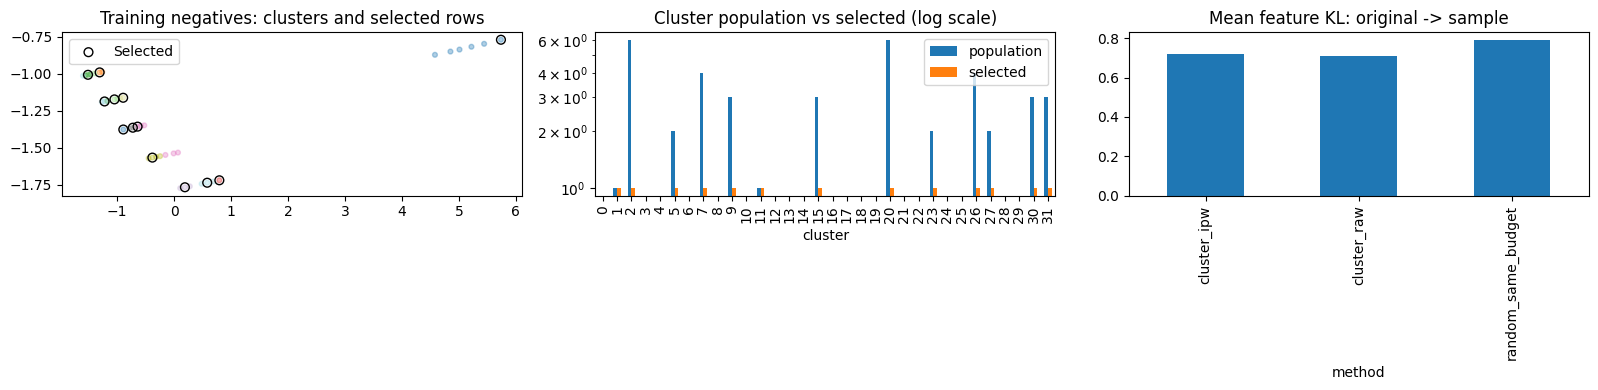

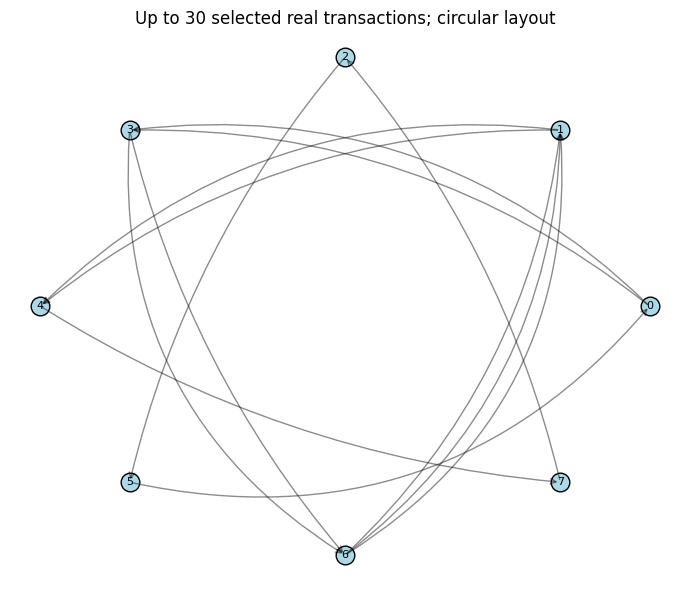

,cluster,population,selected,inclusion_probability
0,0,0,0,0.000000
1,1,1,1,1.000000
2,2,6,1,0.166667
3,3,0,0,0.000000
4,4,0,0,0.000000
5,5,2,1,0.500000
6,6,0,0,0.000000
7,7,4,1,0.250000
8,8,0,0,0.000000
9,9,3,1,0.333333


,KL_P_to_Q,total_variation
method,,
cluster_ipw,0.719461,0.075000
cluster_raw,0.709857,0.082579
random_same_budget,0.790617,0.073190


{'all_nonempty_clusters_preserved': True, 'budget_within_population': True, 'negative_ipw_total_matches_population': True, 'projection_train_only': True, 'test_used': False}


In [88]:
from gnn_pipeline.analysis import cluster_audit, augmentation_comparison, run_method_tests
cluster_counts, cluster_divergence, cluster_checks = cluster_audit(settings, cfg)
display(cluster_counts)
display(cluster_divergence.groupby("method")[["KL_P_to_Q", "total_variation"]].mean())
print(cluster_checks)

## 10. 증강 비교 — 실행 설정

고정 GNN 표현에서 none/repeat/SMOTE/WGAN-GP를 비교합니다. 실제 거래 연결 합성이 아닙니다. DEMO에서는 6종×1시드×4조건=24개 작은 분류기를 학습합니다. GAN/분류기 스텝 수는 동작 확인용이며 수렴을 보장하지 않습니다. 날짜·클래스별 상한이 적용된 표본 기반 검증입니다.

PCA는 학습 양성 표현에만 적합하고 진짜/생성 표현에 동일하게 적용합니다. 원래 GNN 비교와 별개의 실험 표로 해석하세요.

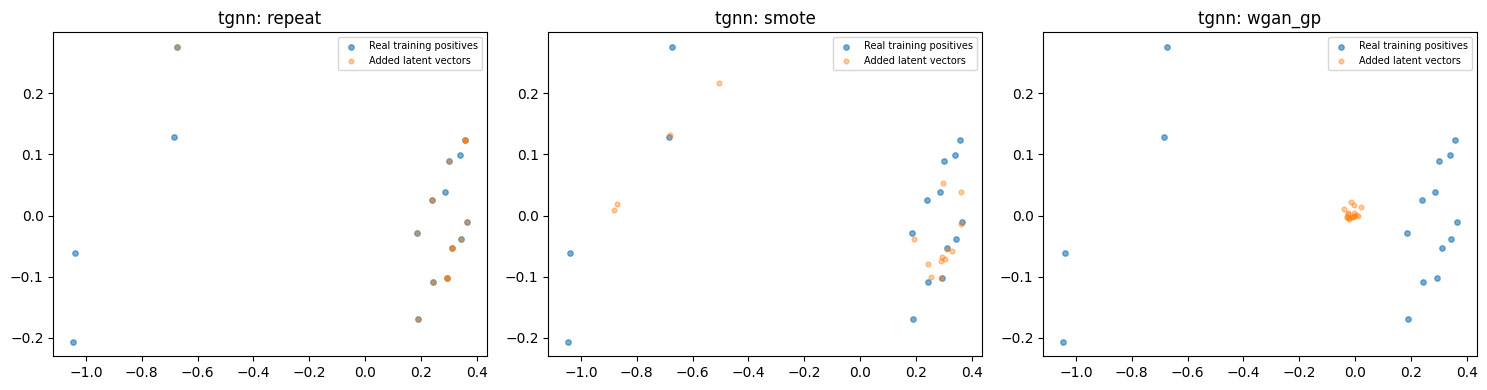

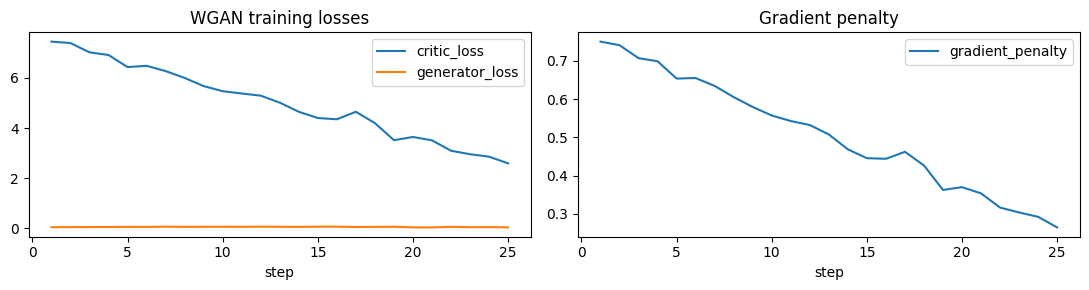

Latent comparison completed: tgnn 42


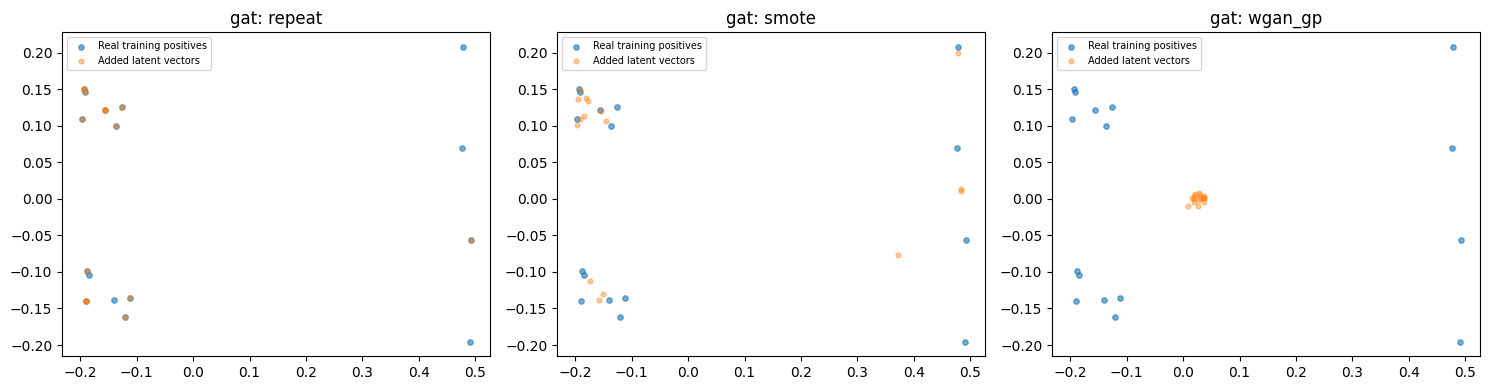

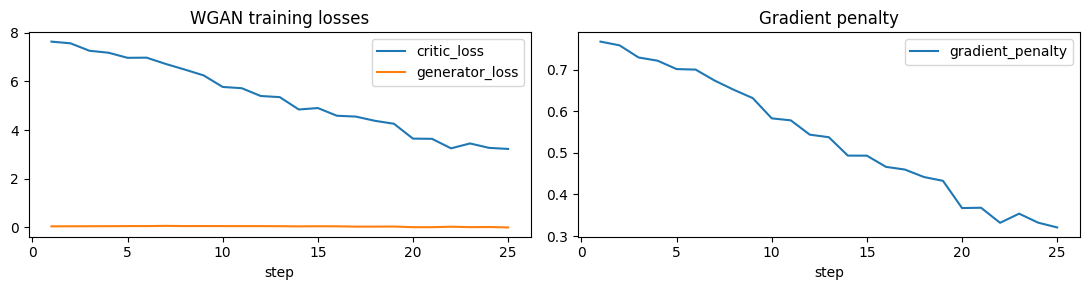

Latent comparison completed: gat 42


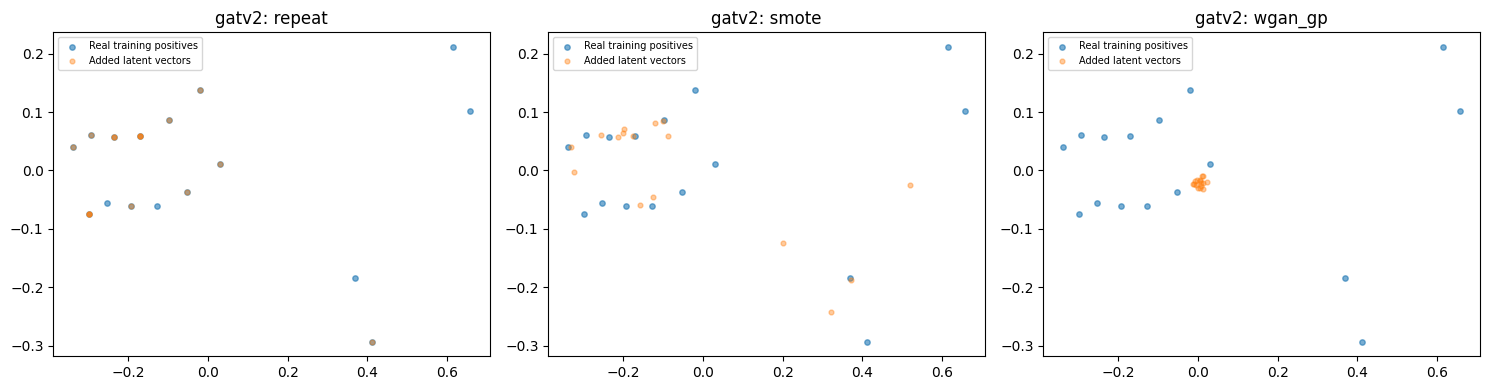

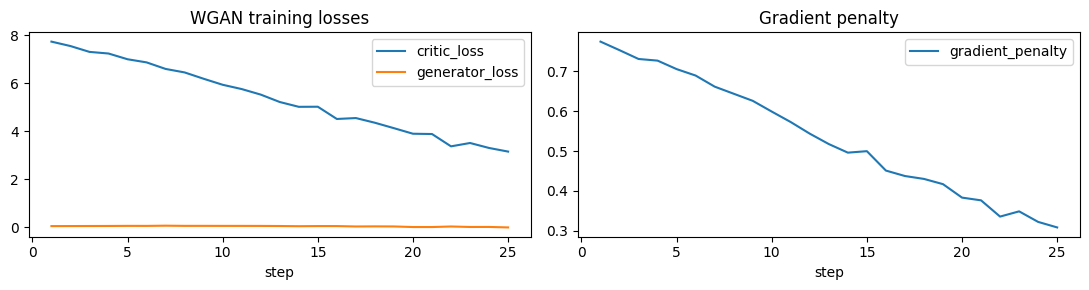

Latent comparison completed: gatv2 42


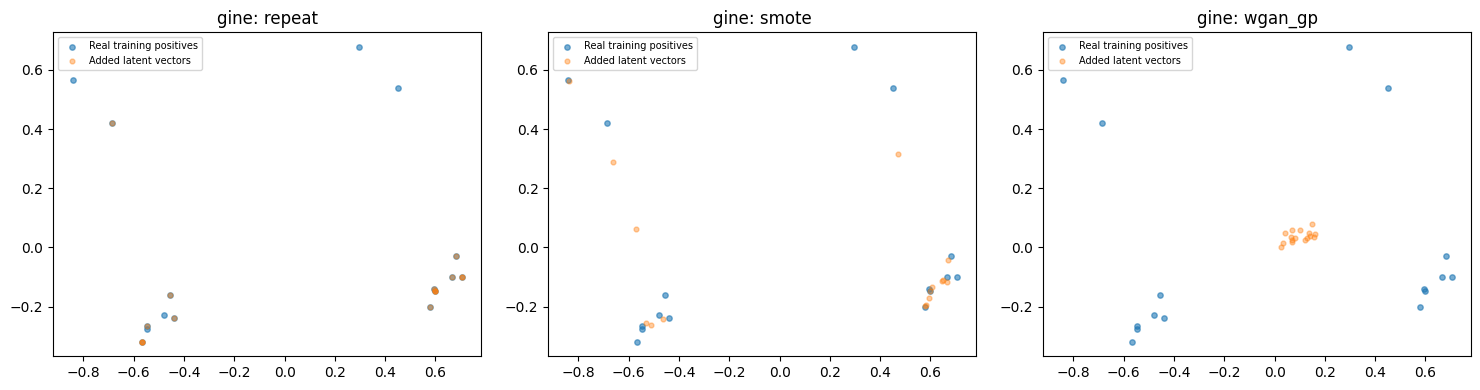

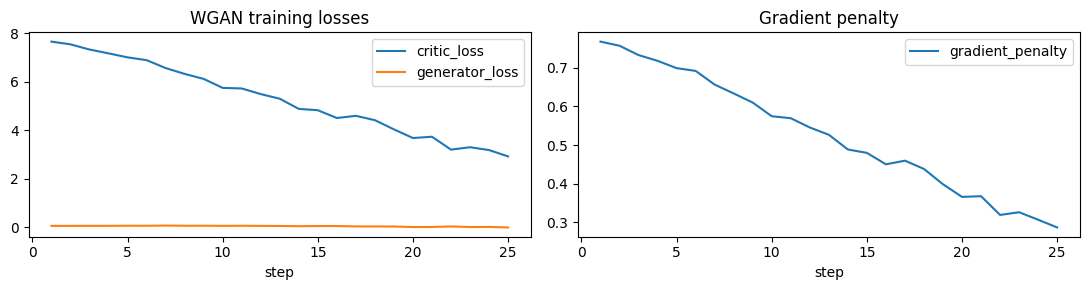

Latent comparison completed: gine 42


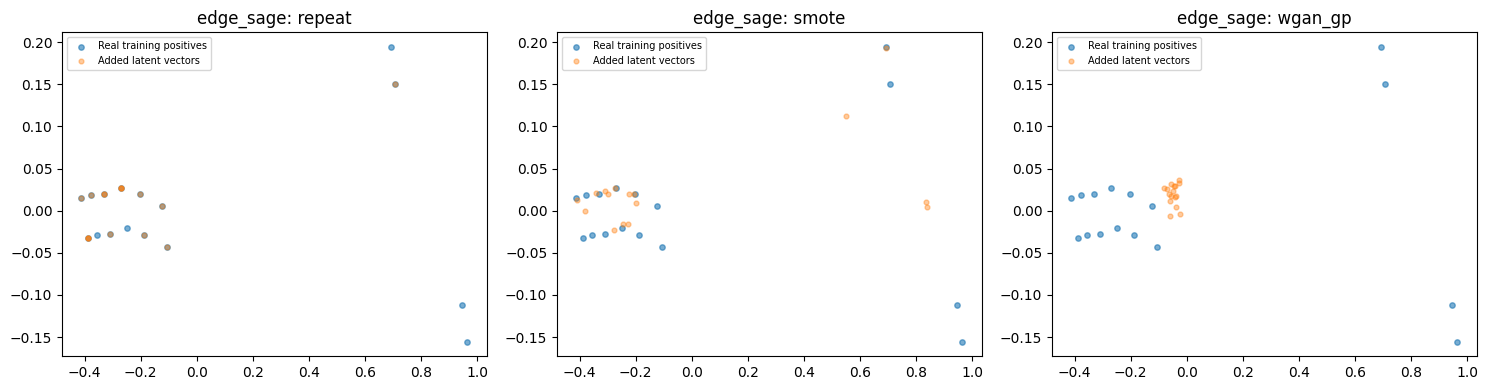

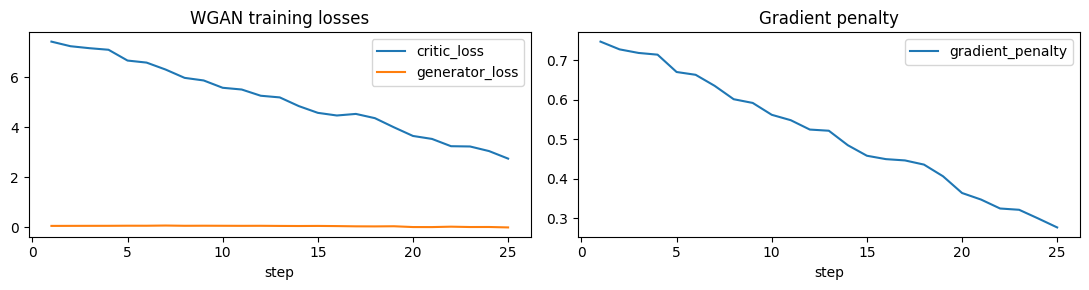

Latent comparison completed: edge_sage 42


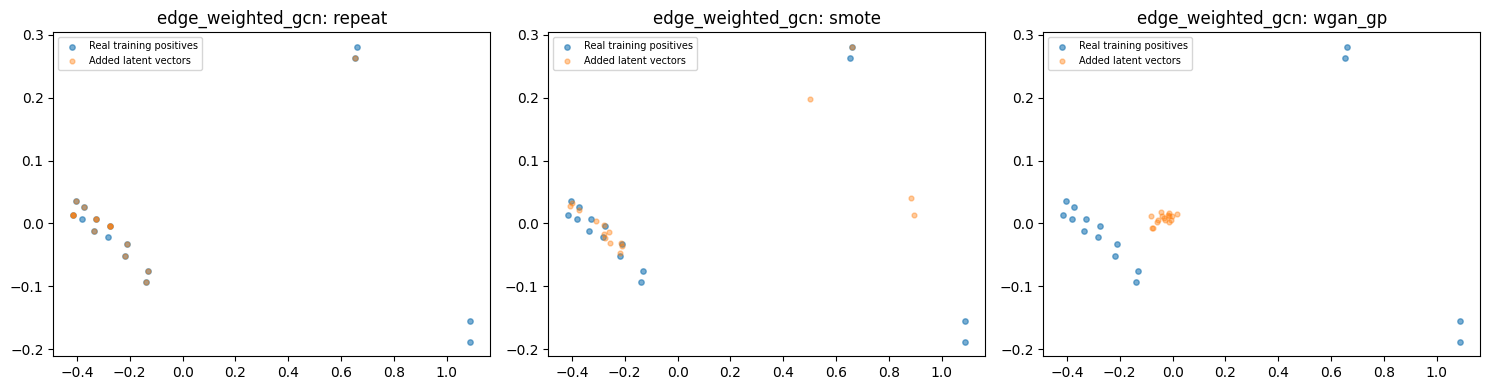

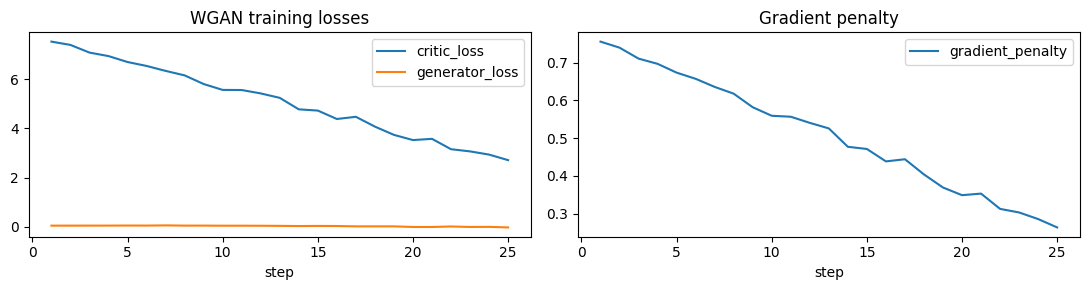

Latent comparison completed: edge_weighted_gcn 42


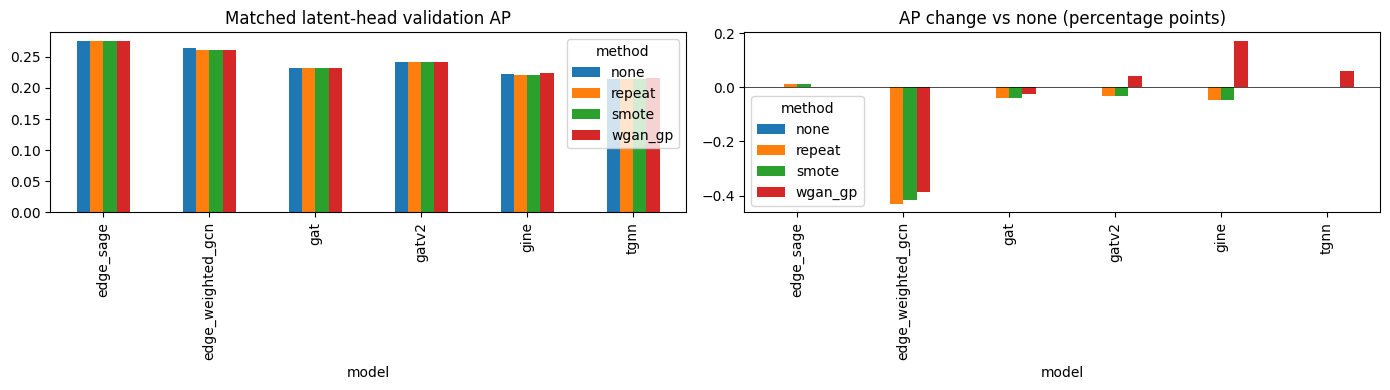

,model,seed,method,validation_rows,cap_per_class_per_day,AP,precision,recall,F1,threshold,positive_loss_mass_alpha,AP_gain_pp
0,tgnn,42,none,96,2048,0.214738,0.212766,0.6250,0.317460,0.845652,60.0,0.000000
1,tgnn,42,repeat,96,2048,0.214738,0.212766,0.6250,0.317460,0.845714,60.0,0.000000
2,tgnn,42,smote,96,2048,0.214738,0.212766,0.6250,0.317460,0.845647,60.0,0.000000
3,tgnn,42,wgan_gp,96,2048,0.215320,0.212766,0.6250,0.317460,0.844567,60.0,0.058218
4,gat,42,none,96,2048,0.232184,0.300000,0.3750,0.333333,0.859568,60.0,0.000000
5,gat,42,repeat,96,2048,0.231794,0.300000,0.3750,0.333333,0.860122,60.0,-0.038993
6,gat,42,smote,96,2048,0.231794,0.300000,0.3750,0.333333,0.859498,60.0,-0.038993
7,gat,42,wgan_gp,96,2048,0.231948,0.300000,0.3750,0.333333,0.862994,60.0,-0.023621
8,gatv2,42,none,96,2048,0.241348,0.234043,0.6875,0.349206,0.774621,60.0,0.000000
9,gatv2,42,repeat,96,2048,0.241043,0.229167,0.6875,0.343750,0.774339,60.0,-0.030474


,model,seed,method,finite,median_std_ratio,median_nearest_real_distance,exact_duplicate_fraction,possible_collapse
0,tgnn,42,repeat,True,0.529009,0.000000,1.0,True
1,tgnn,42,smote,True,0.913520,0.031395,0.0,False
2,tgnn,42,wgan_gp,True,0.074502,0.474731,0.0,False
3,gat,42,repeat,True,0.737787,0.000000,1.0,True
4,gat,42,smote,True,0.942960,0.027167,0.0,False
5,gat,42,wgan_gp,True,0.073570,0.330416,0.0,False
6,gatv2,42,repeat,True,0.631553,0.000000,1.0,True
7,gatv2,42,smote,True,0.788422,0.030587,0.0,False
8,gatv2,42,wgan_gp,True,0.071672,0.402583,0.0,False
9,gine,42,repeat,True,0.931069,0.000000,1.0,True


,model,seed,split_disjoint,smote_segment_verified,same_synthetic_budget,test_used
0,tgnn,42,True,True,True,False
1,gat,42,True,True,True,False
2,gatv2,42,True,True,True,False
3,gine,42,True,True,True,False
4,edge_sage,42,True,True,True,False
5,edge_weighted_gcn,42,True,True,True,False


In [89]:
GAN_STEPS = 25 if DEMO else 100
HEAD_STEPS = 40 if DEMO else 100
LATENT_CAP_PER_CLASS_PER_DAY = 2048
augmentation_results, synthesis_diagnostics, split_checks = augmentation_comparison(
    settings, cfg, gan_steps=GAN_STEPS, head_steps=HEAD_STEPS, cap_per_class=LATENT_CAP_PER_CLASS_PER_DAY)
display(augmentation_results)
display(synthesis_diagnostics)
display(split_checks)

## 11. 코드 검사 결과

아래 테스트는 코드 정합성 검사입니다. 독립 테스트셋 성능 평가와 다릅니다. 군집 예산·SMOTE 생성 수식·손실 비중·GAN 역전파·붕괴 탐지를 확인합니다.

In [90]:
method_test_results = run_method_tests()
display(method_test_results)
method_test_results.to_csv(RUN_ROOT / "analysis" / "method_tests.csv", index=False)

,test,passed
0,"cluster budget, minimum one, capacity",True
1,"SMOTE segment, no self-neighbor, seed repeatab...",True
2,repetition does not increase positive loss mass,True
3,WGAN-GP finite gradient and backward,True
4,constant-output collapse detected,True


# 기존 실제 데이터 실험 결과 — 보관된 결과의 스냅샷

**독립 테스트셋 성능이 아닌 기존 검증셋 결과입니다.** 아래 값은 완료된 CSV 원문을 노트북 안에 포함한 것입니다. 새 컴퓨터에서도 원래 결과 폴더 없이 볼 수 있습니다. 경로와 SHA-256은 출처 확인용이며 실행 경로가 아닙니다.

- 원본/랜덤/클러스터: 6종 × 3시드 × 3방식 = 54개 GNN 실험. 같은 클러스터 검증 ID·IPW를 사용한 결과입니다.
- 잠재공간 증강: 6종 × 3시드 × 4조건 = 72개 새 분류기 실험. 고정 인코더와 클러스터 학습 표본 위의 추가 증강입니다.
- 원본/다운샘플링 표와 증강 표는 학습 절차가 달라 직접 이어 붙인 성능 순위가 아닙니다. 증강 효과는 증강 표의 none과 비교하세요.
- 36피처와 고정 인코더 선택에도 기존 검증셋이 쓰였으므로 독립적인 일반화 성능 주장이 아닙니다. 표준편차는 세 학습 시드의 변동이고 신뢰구간·유의성 검정 결과가 아닙니다.


In [91]:
import io, hashlib
import pandas as pd
import matplotlib.pyplot as plt
SNAPSHOTS = [{'path': 'experiments/gnn36_distribution_v1/seed_summary.csv', 'sha256': '32c22ee5e5765e7807ef890f07420c7a132a9026d5a273e619f9f26d0eeb0a44', 'csv': 'method,model,seeds_completed,AP_mean,AP_std,precision_mean,precision_std,recall_mean,recall_std,F1_mean,F1_std,accuracy_mean,accuracy_std,FPR_mean,FPR_std,ROC_AUC_mean,ROC_AUC_std,recall_at_1_percent_mean,recall_at_1_percent_std,unmatched_recall_at_1_percent_mean,unmatched_recall_at_1_percent_std\ncluster_under,edge_sage,3,0.5869686655477369,0.009340691540217471,0.7831628702992895,0.012146783858258316,0.5135095555392839,0.011724829176277317,0.6202736139961231,0.01164390590114488,0.9992346067712651,2.104478559074456e-05,0.00017330160797697966,9.84900527388004e-06,0.9898055669351505,0.0002215651214308881,0.8493324546630543,0.0026292222322120903,0.6331555928344618,0.0055518583155199685\ncluster_under,edge_weighted_gcn,3,0.580884825945688,0.015323238198376589,0.7801966768734184,0.036349414532818286,0.4996949061531328,0.01642868240639786,0.6091657351605366,0.02281676824952776,0.9992190742726178,5.0168504770837546e-05,0.00017201318815974207,3.1536382676444024e-05,0.9896160338252503,0.0001254826659110749,0.8434909244750353,0.0019382593922546755,0.6211331456074132,0.004845265554154471\ncluster_under,gat,3,0.5896709230441353,0.0051659218979424135,0.809497000148232,0.03066357287028814,0.49875928502273964,0.006077632797599928,0.6169978010515654,0.0061563376464944235,0.9992459132040697,2.5027111169170982e-05,0.00014400103219224645,3.068706909659153e-05,0.9896608058025134,0.000214838436245293,0.8460293052809712,0.002232497687973787,0.6274838735446249,0.005331990569938199\ncluster_under,gatv2,3,0.580829095543551,0.007743090923417188,0.7935580155948304,0.01288125230351248,0.49681482023870543,0.007779182373456346,0.6110105362032493,0.006620658025117894,0.9992298647811692,1.3460978817013847e-05,0.00015769874420021245,1.3047686487281064e-05,0.9895895236881369,0.0001384995036791821,0.8454679326027352,0.0008463224856936529,0.6262257104627243,0.0019692303974724167\ncluster_under,gine,3,0.5656395132079637,0.005265533284475113,0.7526842512558626,0.00261626978450324,0.5050076070065819,0.0037012867578820477,0.6044543002412035,0.0031156231802415267,0.9991953202740521,4.96603553178198e-06,0.0002022722459032478,2.5645959378566984e-06,0.9889706987154288,0.0005076946447940941,0.8443207797385143,0.0021369234184215246,0.6231302298643979,0.0053286234928116676\ncluster_under,tgnn,3,0.6211238772714331,0.005863783987901558,0.8071463733824124,0.014448542246689107,0.5427334781512126,0.012368763936747596,0.6488714928025544,0.004306175018494296,0.9992850012733072,3.203957351352197e-06,0.00015846920325308488,1.8071050882832494e-05,0.990327579482598,0.00012010631637334306,0.8570940421273584,0.0018480529346304353,0.6515087971561521,0.0043511236932506055\noriginal,edge_sage,3,0.6059283631041258,0.012045357870115563,0.7923884862770659,0.016509348982934366,0.5440352118978464,0.004720776288391945,0.6450455666926204,0.0023793739668969663,0.9992709742651678,1.3541589047771382e-05,0.000174100104203465,1.917833160143991e-05,0.9890088402082117,0.0005654880430416264,0.8436129620137821,0.009640481518111046,0.6200147784235016,0.0232117813638537\noriginal,edge_weighted_gcn,3,0.614132833558843,0.005535451849800442,0.8255610443452124,0.020667015290180935,0.5487946759089762,0.010568601170089339,0.6591867019308298,0.00928902532265519,0.9993090875036995,2.1446501307885185e-05,0.000141742122115796,2.1300535722706698e-05,0.9879631019118426,0.0007592660333458856,0.8343299732330998,0.004533580956971271,0.5988257144568929,0.01094351151237617\noriginal,gat,3,0.6134089646422919,0.002001929910685563,0.8191029403329372,0.0038110607062772457,0.5536680416229366,0.0023729738377644733,0.6607184560145279,0.0018658739110245378,0.9993077044561317,4.004576973223293e-06,0.00014906741599689935,4.0356497609378646e-06,0.9867220018836557,0.0008280978759049027,0.8281386021006728,0.002841597203894665,0.5850258622411278,0.007467786756147438\noriginal,gatv2,3,0.6113386824384502,0.016352255941040637,0.8400138775362702,0.013183792282143152,0.5436365559379399,0.011420766423088702,0.6599420472270588,0.004439880253442417,0.99931801699296,1.451905033701485e-06,0.00012651407633309643,1.4919872475013025e-05,0.9870202366870399,0.0011139214269500195,0.8324668668082301,0.009976581854673927,0.5948515167854932,0.0237374866310248\noriginal,gine,3,0.6001259817500546,0.009428341667643118,0.8067676684373337,0.04773047416936529,0.5455891565578904,0.019627587379900415,0.6500719465496478,0.007764251366835474,0.9992846789255742,3.52604689207075e-05,0.00016227297347265487,5.53345016456869e-05,0.988428370100716,0.00027043675882368085,0.8393660556653894,0.0037483871910483297,0.6107483074710923,0.009155645790183213\noriginal,tgnn,3,0.6027666316824568,0.0031297379373271222,0.7801399621647365,0.0306069605232568,0.5449871047000724,0.009102538876407754,0.6413913385914419,0.00538080875636349,0.9992578340954993,2.606428021311161e-05,0.00018841663472669162,3.5882220472273616e-05,0.9872719244652126,0.0014746399044064749,0.8317102340679993,0.01003801598244851,0.5936532662313022,0.023325166134861075\nrandom_under,edge_sage,3,0.5648221815220512,0.01721484409089945,0.7447481899182741,0.03283537619236065,0.5117522149813283,0.008846534769697044,0.6065200544534918,0.015363320888269675,0.9991912002122052,4.106627754406718e-05,0.0002146189069570539,3.426198974639966e-05,0.9896436728471297,0.00022837388282650323,0.8474286690586025,0.001416266537443931,0.628502386515687,0.002980209163739356\nrandom_under,edge_weighted_gcn,3,0.585979026258876,0.002166815947943525,0.7960705424374078,0.011980242003559499,0.5004840822370294,0.00842770896860434,0.6145535792305725,0.00844307399673346,0.9992356790450653,1.6252891052394545e-05,0.0001563501686623241,1.082629206637447e-05,0.9895682228709645,0.0001793168719543962,0.8402691334521165,0.0038150998445738407,0.6143630299762347,0.009590184917129738\nrandom_under,gat,3,0.5938016624366972,0.007176788483799211,0.8010446999056203,0.008336011876070462,0.5168859274446153,0.006329141765402529,0.628326227504273,0.00691129459769656,0.9992555036213134,1.3275348801515382e-05,0.0001564950321666482,6.75055724924136e-06,0.9896356708758193,0.00015353574558325646,0.8455574267978164,0.0032123779158926397,0.6254268767599306,0.006808973767982908\nrandom_under,gatv2,3,0.5967798517225694,0.0039134991013018445,0.8115861686052775,0.01596064324504634,0.5075541236484343,0.01729960347438153,0.6243049122373925,0.011074643869470557,0.9992565911169743,1.442826322169992e-05,0.00014403088068527865,1.865385335552978e-05,0.9896092206119019,8.231556955376236e-05,0.8455818343055657,0.0007484526865087831,0.6250474307511035,0.0011987497212836297\nrandom_under,gine,3,0.5584455031622473,0.0037142416826958942,0.7014523481575657,0.029428884506093184,0.5227681368122168,0.01582435562587535,0.5987483408297677,0.013350153330581298,0.9991468069193598,3.818907096061177e-05,0.00027249455960904565,4.206349692246745e-05,0.9889871421203175,0.0004399033604108786,0.8405782952169419,0.004245105796113813,0.6125456833023785,0.010245042238332034\nrandom_under,tgnn,3,0.6159355775775989,0.002717077630274045,0.7838918010781404,0.013907453850745231,0.5436772351175221,0.005637394620141849,0.6419912549051069,0.004644052790031242,0.9992617177705657,1.374622219273879e-05,0.00018293151395836098,1.6056837410320635e-05,0.9897367961176772,0.0006344698509273446,0.8533271500980368,0.0021548295538750943,0.6424620054720109,0.004942813794797131\n'}, {'path': 'experiments/gnn36_latent_oversampling_v1/seed_summary.csv', 'sha256': '4e8ab9b12dcf8014573b9d8a909c4f6e02ac56c2fa853ffa96eeed58d26c81d5', 'csv': 'model,method,seeds,AP_mean,AP_std,AP_gain_pp,precision,recall,F1,ROC_AUC,recall_at_1_percent\nedge_sage,none,3,0.5669318771439543,0.024936878099790463,0.0,0.7514922348059835,0.516226924735382,0.6118232891752023,0.9899907392519128,0.8499833215363712\nedge_sage,repeat,3,0.5564084991405421,0.020302063987823492,-1.0523378003412187,0.7182323426540337,0.5137699022886107,0.5985940858002191,0.9900073564187002,0.8499182348490395\nedge_sage,smote,3,0.5568584133649509,0.01782040803676569,-1.007346377900331,0.71901525071351,0.5113128798418393,0.5974376318758094,0.9899584032392242,0.8490883795855605\nedge_sage,wgan_gp,3,0.5525684710466102,0.03920308107511395,-1.43634060973441,0.7098174935614416,0.5226949142889686,0.6014370785461813,0.989570274236318,0.8456957360083962\nedge_weighted_gcn,none,3,0.5615133502917029,0.037243002619167236,0.0,0.770188436415113,0.5035675640493683,0.6088660855290849,0.9901037197984155,0.8459479469218065\nedge_weighted_gcn,repeat,3,0.5610013810279016,0.04153231315285791,-0.05119692638012596,0.7407555557819707,0.5168371124291166,0.6086127375222977,0.9897863667452164,0.8426203900319739\nedge_weighted_gcn,smote,3,0.5644405455804232,0.035245017110105165,0.2927195288720245,0.7549787697171992,0.5106782846403554,0.609236158080468,0.9898698801844524,0.8446624848470057\nedge_weighted_gcn,wgan_gp,3,0.5773117817914059,0.02208639128821538,1.579843149970302,0.7634964856165413,0.51023081366495,0.6112606220251146,0.9897869077553864,0.8434583811313693\ngat,none,3,0.5618515919963677,0.027739865033723346,0.0,0.771691278221275,0.5094416375810532,0.6131858452323398,0.9898739784838445,0.8478598683621749\ngat,repeat,3,0.5630093255764611,0.020266267996921807,0.11577335800933379,0.7875754443593422,0.5029085613401348,0.6138361551189738,0.9897835479007013,0.8469242472317818\ngat,smote,3,0.5699267031137305,0.012093430513057732,0.807511111736281,0.7833619737079743,0.518008672801087,0.6235389376240638,0.9900756818955263,0.8499100990131231\ngat,wgan_gp,3,0.5768905824604137,0.0205612731427451,1.5038990464045998,0.7491200804229342,0.5248509108068308,0.6166964384256924,0.9896777186100641,0.8466720363183716\ngatv2,none,3,0.5656714542637279,0.003469882992067228,0.0,0.7480820151712696,0.5260143353428849,0.6171472200318435,0.9898364757874037,0.8461920219993003\ngatv2,repeat,3,0.5686645218700129,0.0046598303626259555,0.2993067606285038,0.7780217700047732,0.525753988593558,0.627315771347016,0.9899447787416694,0.8473473106994378\ngatv2,smote,3,0.5694643563520488,0.0024221863153835073,0.3792902088320986,0.7747021025402591,0.5236468070911946,0.6248973729574296,0.98977950956282,0.8463628745535461\ngatv2,wgan_gp,3,0.5680467757175741,0.005082549239128987,0.23753214538463352,0.7238558995917123,0.5244685265187572,0.6081405265257219,0.9891276904877025,0.8407816911148536\ngine,none,3,0.5683489979920449,0.006622039784457776,0.0,0.744127059477716,0.5103447153677805,0.6050822203788773,0.9898473263754594,0.8450367332991627\ngine,repeat,3,0.5636608338935213,0.016202235966628318,-0.468816409852361,0.7319697642408186,0.5094904525965521,0.6006894780225043,0.989715498623601,0.8437024562088632\ngine,smote,3,0.5733578812828196,0.00486298978752871,0.500888329077472,0.7544863713696409,0.5119230675355739,0.6097495826370709,0.989794634655481,0.8452075858534084\ngine,wgan_gp,3,0.5544628124422796,0.011671585850630845,-1.3886185549765357,0.7268259764271755,0.5055933871925671,0.5960993718485849,0.9897348179096729,0.8433770227722047\ntgnn,none,3,0.5966471075305729,0.02400117264004221,0.0,0.7832443201007274,0.5310422819392578,0.6329440217440797,0.9902150764201888,0.8539698811354373\ntgnn,repeat,3,0.6024969247186829,0.01973769290376544,0.5849817188109915,0.7788349271620923,0.5381285950224955,0.636426747944762,0.990233165940788,0.8539373377917713\ntgnn,smote,3,0.5990912005745476,0.0227122053673174,0.24440930439745637,0.7915663232257134,0.5301473399884471,0.6348312208723882,0.9903452147631628,0.8547021063679189\ntgnn,wgan_gp,3,0.6043842373312384,0.013728825371972477,0.7737129800665506,0.7672847145652514,0.5376160373597585,0.6321021497650741,0.9901698884804709,0.8535468176677812\n'}]

## 결과 원문과 출처 확인

In [92]:
for snapshot in SNAPSHOTS:
    assert hashlib.sha256(snapshot['csv'].encode()).hexdigest() == snapshot['sha256']
    print(snapshot['path'], snapshot['sha256'])
original_results = pd.read_csv(io.StringIO(SNAPSHOTS[0]['csv']))
latent_results = pd.read_csv(io.StringIO(SNAPSHOTS[1]['csv']))
assert len(original_results) == 18 and (original_results.seeds_completed == 3).all()
assert len(latent_results) == 24 and (latent_results.seeds == 3).all()
display(original_results[['method','model','seeds_completed','AP_mean','AP_std','F1_mean']])
display(latent_results[['model','method','seeds','AP_mean','AP_std','AP_gain_pp','F1']])

experiments/gnn36_distribution_v1/seed_summary.csv 32c22ee5e5765e7807ef890f07420c7a132a9026d5a273e619f9f26d0eeb0a44
experiments/gnn36_latent_oversampling_v1/seed_summary.csv 4e8ab9b12dcf8014573b9d8a909c4f6e02ac56c2fa853ffa96eeed58d26c81d5


,method,model,seeds_completed,AP_mean,AP_std,F1_mean
0,cluster_under,edge_sage,3,0.586969,0.009341,0.620274
1,cluster_under,edge_weighted_gcn,3,0.580885,0.015323,0.609166
2,cluster_under,gat,3,0.589671,0.005166,0.616998
3,cluster_under,gatv2,3,0.580829,0.007743,0.611011
4,cluster_under,gine,3,0.565640,0.005266,0.604454
5,cluster_under,tgnn,3,0.621124,0.005864,0.648871
6,original,edge_sage,3,0.605928,0.012045,0.645046
7,original,edge_weighted_gcn,3,0.614133,0.005535,0.659187
8,original,gat,3,0.613409,0.002002,0.660718
9,original,gatv2,3,0.611339,0.016352,0.659942


,model,method,seeds,AP_mean,AP_std,AP_gain_pp,F1
0,edge_sage,none,3,0.566932,0.024937,0.000000,0.611823
1,edge_sage,repeat,3,0.556408,0.020302,-1.052338,0.598594
2,edge_sage,smote,3,0.556858,0.017820,-1.007346,0.597438
3,edge_sage,wgan_gp,3,0.552568,0.039203,-1.436341,0.601437
4,edge_weighted_gcn,none,3,0.561513,0.037243,0.000000,0.608866
5,edge_weighted_gcn,repeat,3,0.561001,0.041532,-0.051197,0.608613
6,edge_weighted_gcn,smote,3,0.564441,0.035245,0.292720,0.609236
7,edge_weighted_gcn,wgan_gp,3,0.577312,0.022086,1.579843,0.611261
8,gat,none,3,0.561852,0.027740,0.000000,0.613186
9,gat,repeat,3,0.563009,0.020266,0.115773,0.613836


## 기존 결과 비교 그림

AP를 0~1 척도로 표시합니다. 오차 막대는 세 시드의 표준편차입니다. 증강 효과의 pp는 퍼센트포인트입니다.

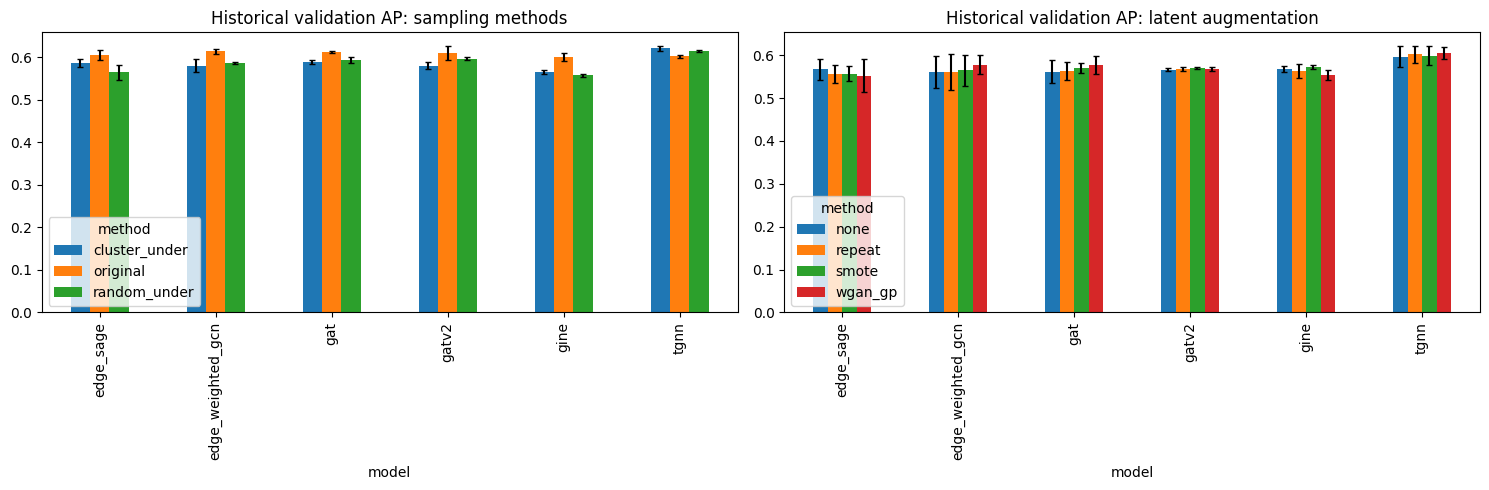

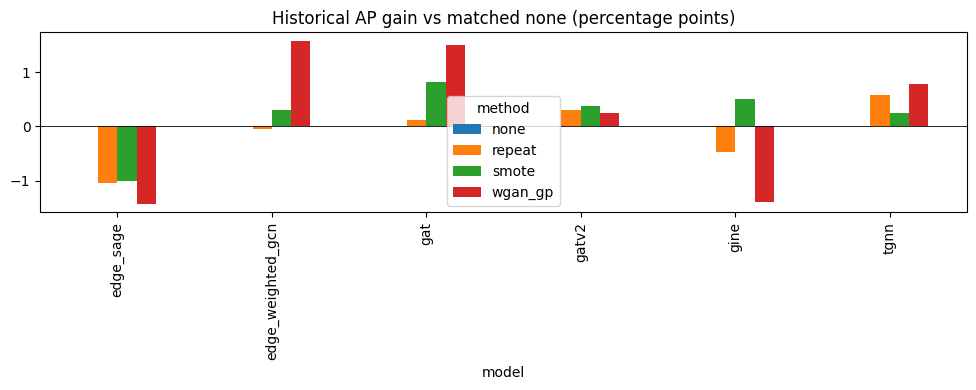

증강별 모델 평균 AP 변화(pp):


,mean,min,max
method,,,
none,0.000000,0.000000,0.000000
repeat,-0.095382,-1.052338,0.584982
smote,0.202912,-1.007346,0.807511
wgan_gp,0.211671,-1.436341,1.579843


In [93]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
p = original_results.pivot(index='model', columns='method', values='AP_mean')
e = original_results.pivot(index='model', columns='method', values='AP_std').reindex_like(p)
p.plot.bar(yerr=e, capsize=2, ax=axes[0]);axes[0].set_title('Historical validation AP: sampling methods')
p = latent_results.pivot(index='model', columns='method', values='AP_mean')
e = latent_results.pivot(index='model', columns='method', values='AP_std').reindex_like(p)
p.plot.bar(yerr=e, capsize=2, ax=axes[1]);axes[1].set_title('Historical validation AP: latent augmentation')
fig.tight_layout();plt.show()
fig, ax = plt.subplots(figsize=(10, 4))
latent_results.pivot(index='model',columns='method',values='AP_gain_pp').plot.bar(ax=ax)
ax.axhline(0, color='black', linewidth=.6);ax.set_title('Historical AP gain vs matched none (percentage points)')
fig.tight_layout();plt.show()
print('증강별 모델 평균 AP 변화(pp):')
display(latent_results.groupby('method').AP_gain_pp.agg(['mean','min','max']))

## 해석

양수 변화는 같은 절차의 none보다 AP가 높았다는 뜻이고 음수는 낮았다는 뜻입니다. 생성 그림이 좋아 보여도 실제 검증 성능이 개선되지 않을 수 있습니다. 최댓값만으로 우열을 확정하지 말고 시드별 변동과 검증셋 재사용을 함께 고려해야 합니다.

# 기존 실제 표본의 시각화와 재검증 기록

아래는 **2026-09-27에 기존 실험 산출물에서 추출·검사해 저장한 시각화**입니다. 위에서 새로 실행한 인공 데이터 데모와 다릅니다. 이미지가 노트북 안에 포함되어 있어 원래 그림 파일 없이 볼 수 있습니다. 이 부분의 재검증 수치는 저장된 감사 기록을 인용한 것이며 이번 통합본 실행에서 대용량 원본을 다시 검사한 결과는 아닙니다.

출처: `reports/gnn_sampling_tables_2026-09-26/build_evidence_visuals.py`, 같은 폴더의 `evidence_visuals/audit.json` 및 `test_verification.txt`.


## 실제 클러스터 표본

2022-08-08의 저장된 정상 표본 19,272건에 적합한 PCA이며 그림에는 그중 3,000건을 표시했습니다. 입력은 기존 실험의 표준화된 거래 특징 18개, PCA 두 축 설명분산은 56.36%입니다. 색은 저장된 32개 군집 ID입니다. 원본 정상 거래 전체를 표시한 그림도, PCA 좌표에서 새로 군집화한 그림도 아닙니다. 오른쪽은 정상 원본·추출 표본·IPW 보정 군집 비중입니다.

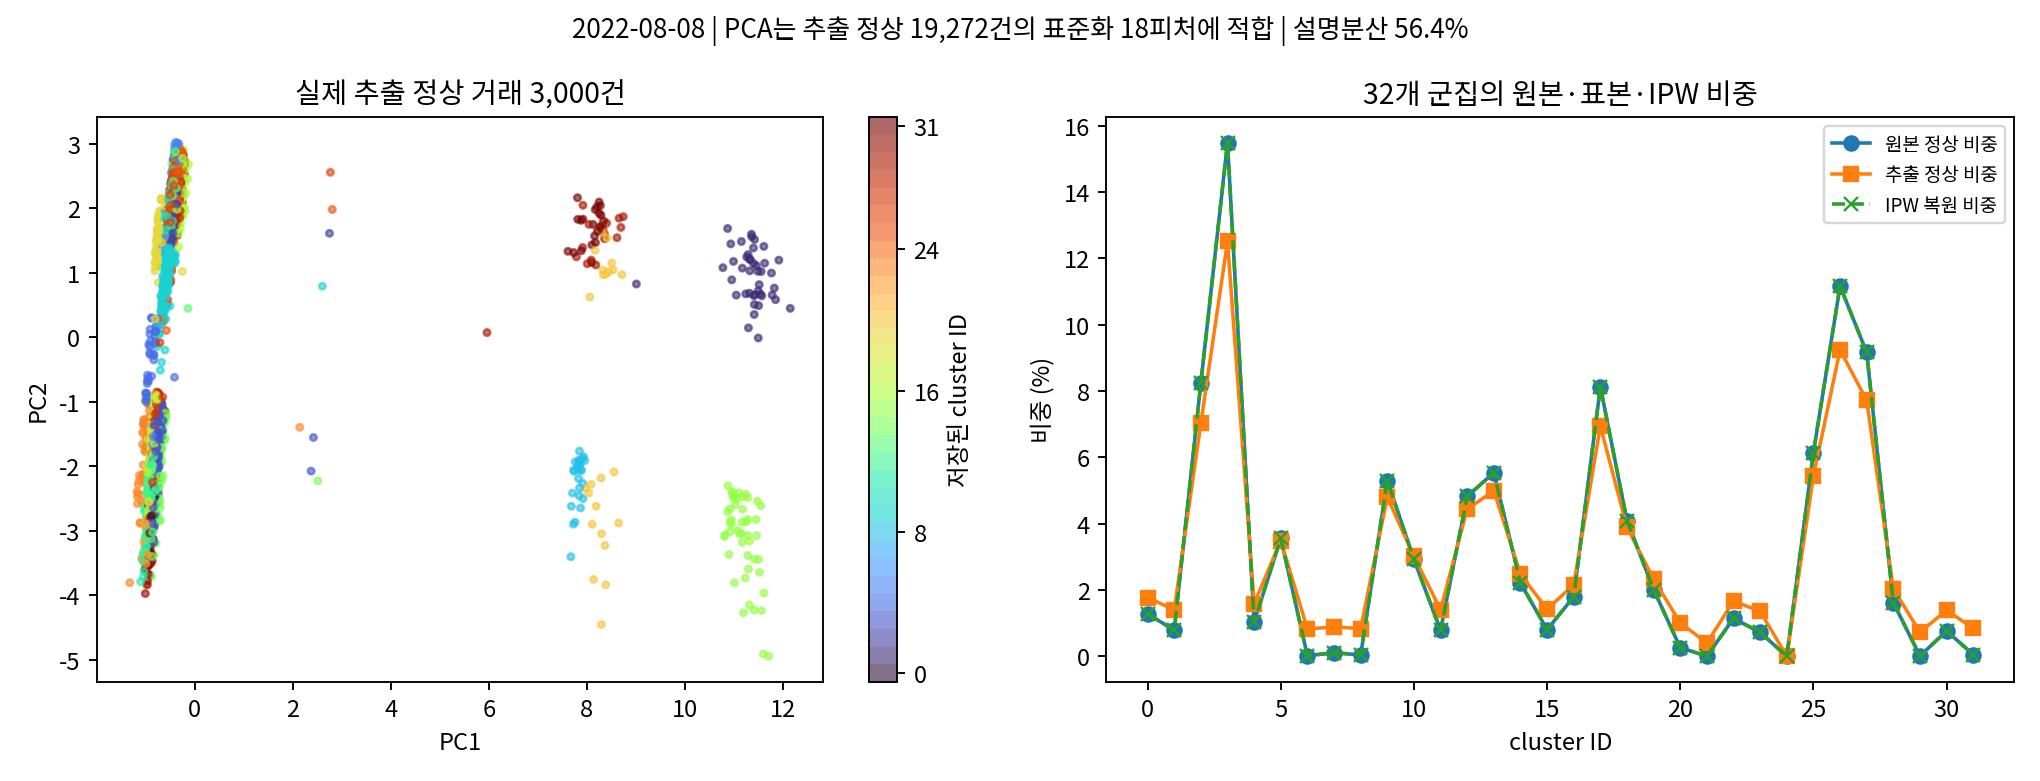

출처: `evidence_visuals/cluster_sample.png` · SHA-256: `3483c8663b6a2b161a917d14ee1cc22f8b404e34cfa74f4028e6c6561278f338`

## 군집별 할당과 추출률

군집별 원본 규모와 실제 추출 수, 추출률을 비교합니다. 작은 군집 보존 때문에 전체 평균 1%와 군집별 추출률은 다릅니다.

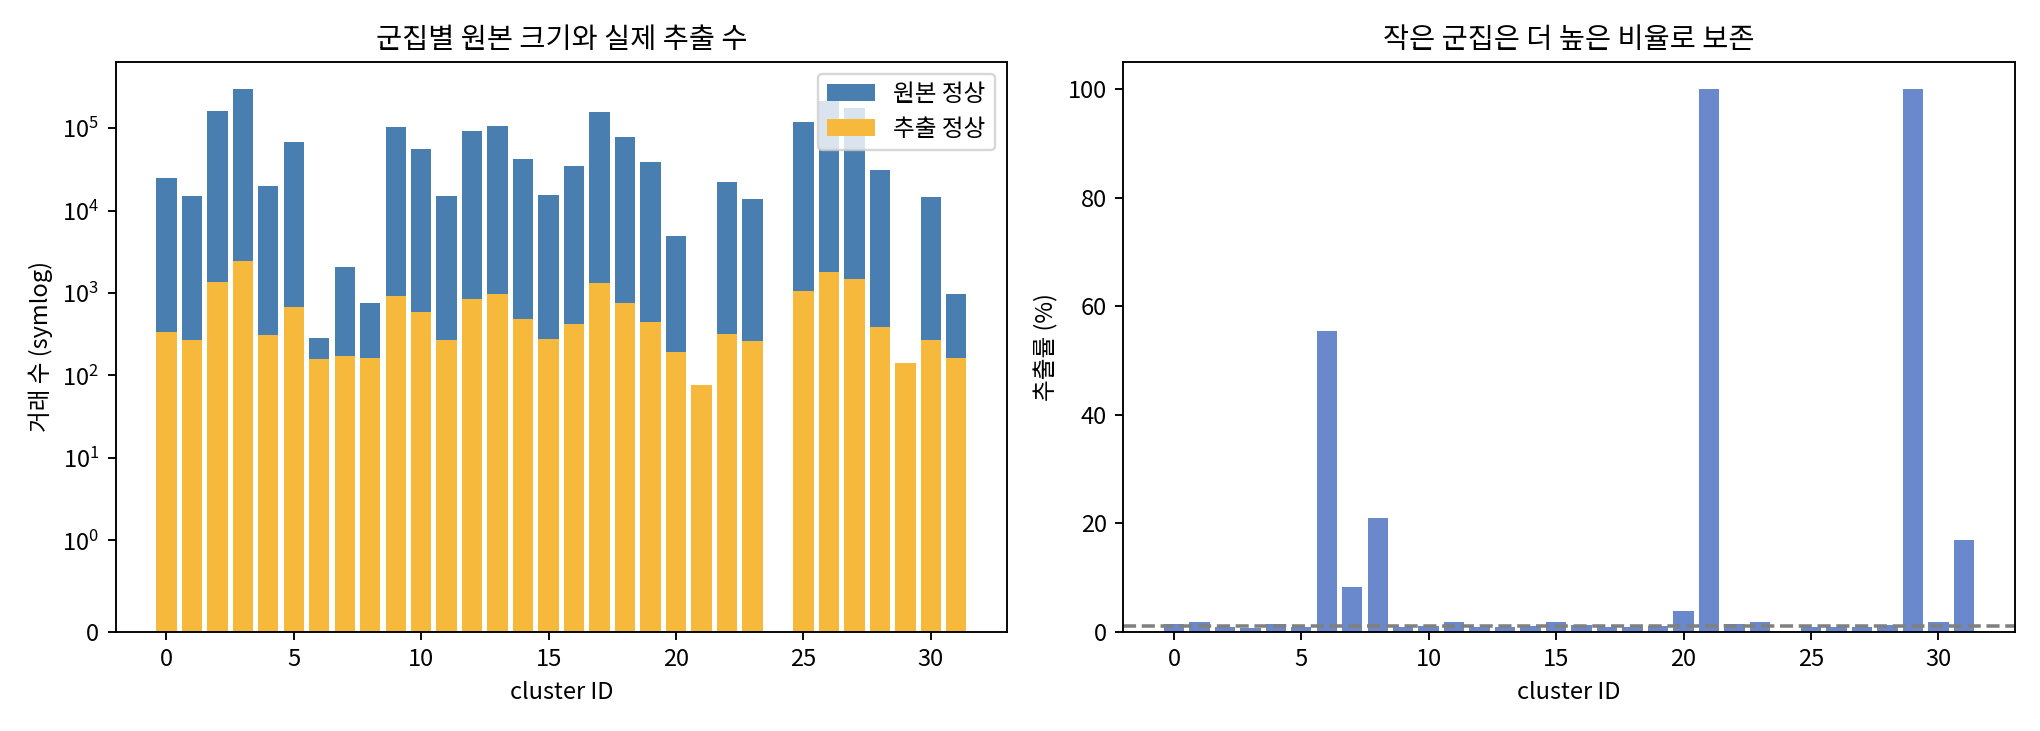

출처: `evidence_visuals/cluster_allocation.png` · SHA-256: `00adf06f375b3d1b4a17c5ad6ee93c384408d21e4a111bd433b74c3e00ccf872`

## 기존 전체 분포 감사

기존 실험의 62개 역할별 주변분포(거래 18개 + 송신 계좌 22개 + 수신 계좌 22개)를 검사한 결과입니다. 36피처 자체의 36개 분포로 오해하면 안 됩니다. 로그 축의 KL은 0에 가까울수록 원본의 해당 주변분포와 비슷합니다. IPW 보정 전후와 같은 규모의 랜덤 표본을 함께 비교합니다.

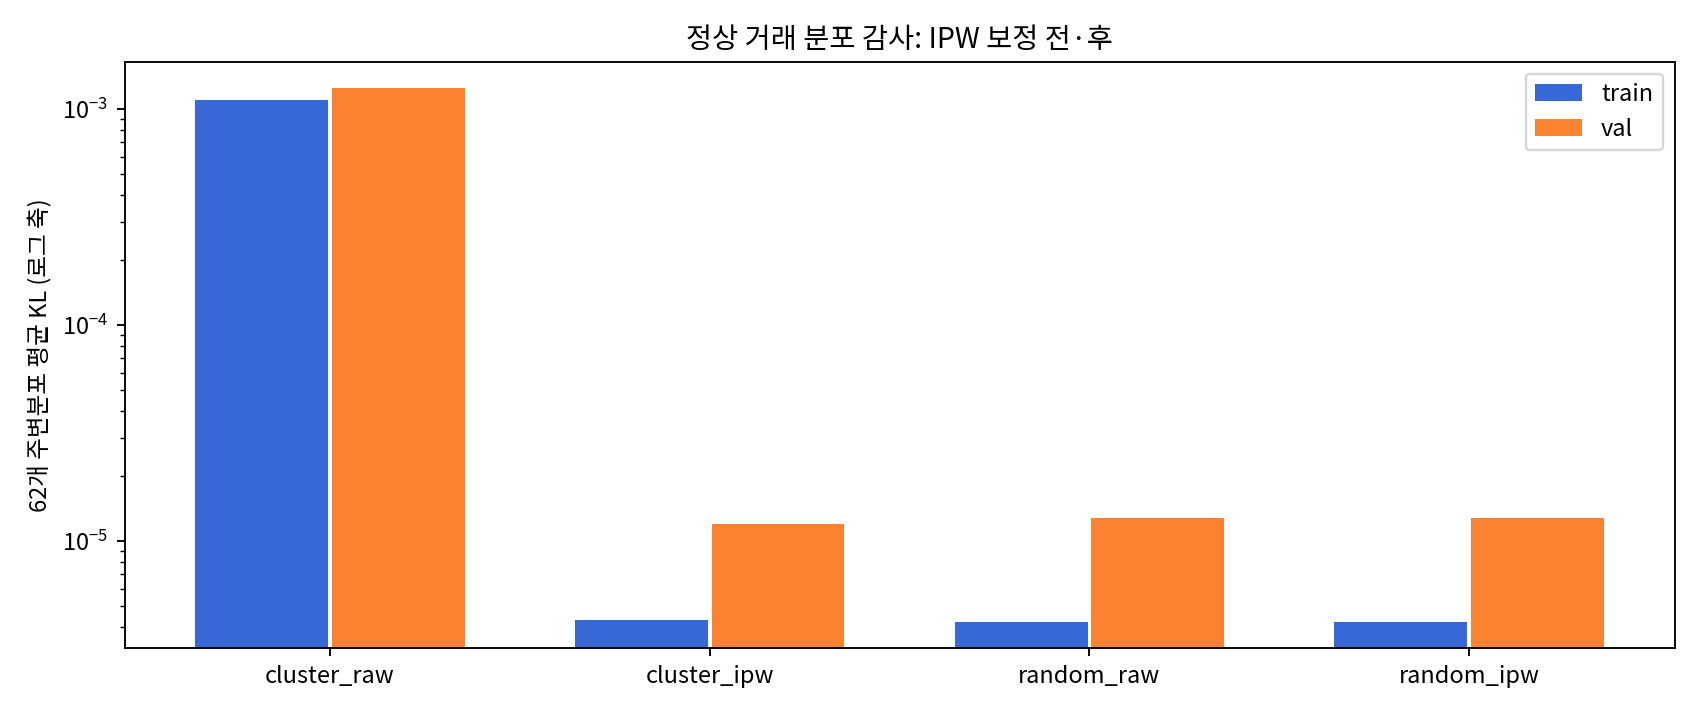

출처: `evidence_visuals/cluster_kl.png` · SHA-256: `2da2fe4cccf485ab0e97b77e75f2f61d78fb1ce451c4fe6380072424413e51b0`

## 실제 저장된 TGNN 증강 표본

TGNN seed 42의 표준화된 128차원 학습 이상 거래 표현 10,000건으로 공통 PCA를 적합했습니다. 실제와 각 생성 풀에서 동일한 행 번호 2,000건을 표시했습니다. 두 축 설명분산은 80.33%입니다. 반복/SMOTE/WGAN-GP 그림은 저장된 생성 풀에서 가져온 것이며 원본 계좌·거래 그래프를 합성한 그림이 아닙니다.

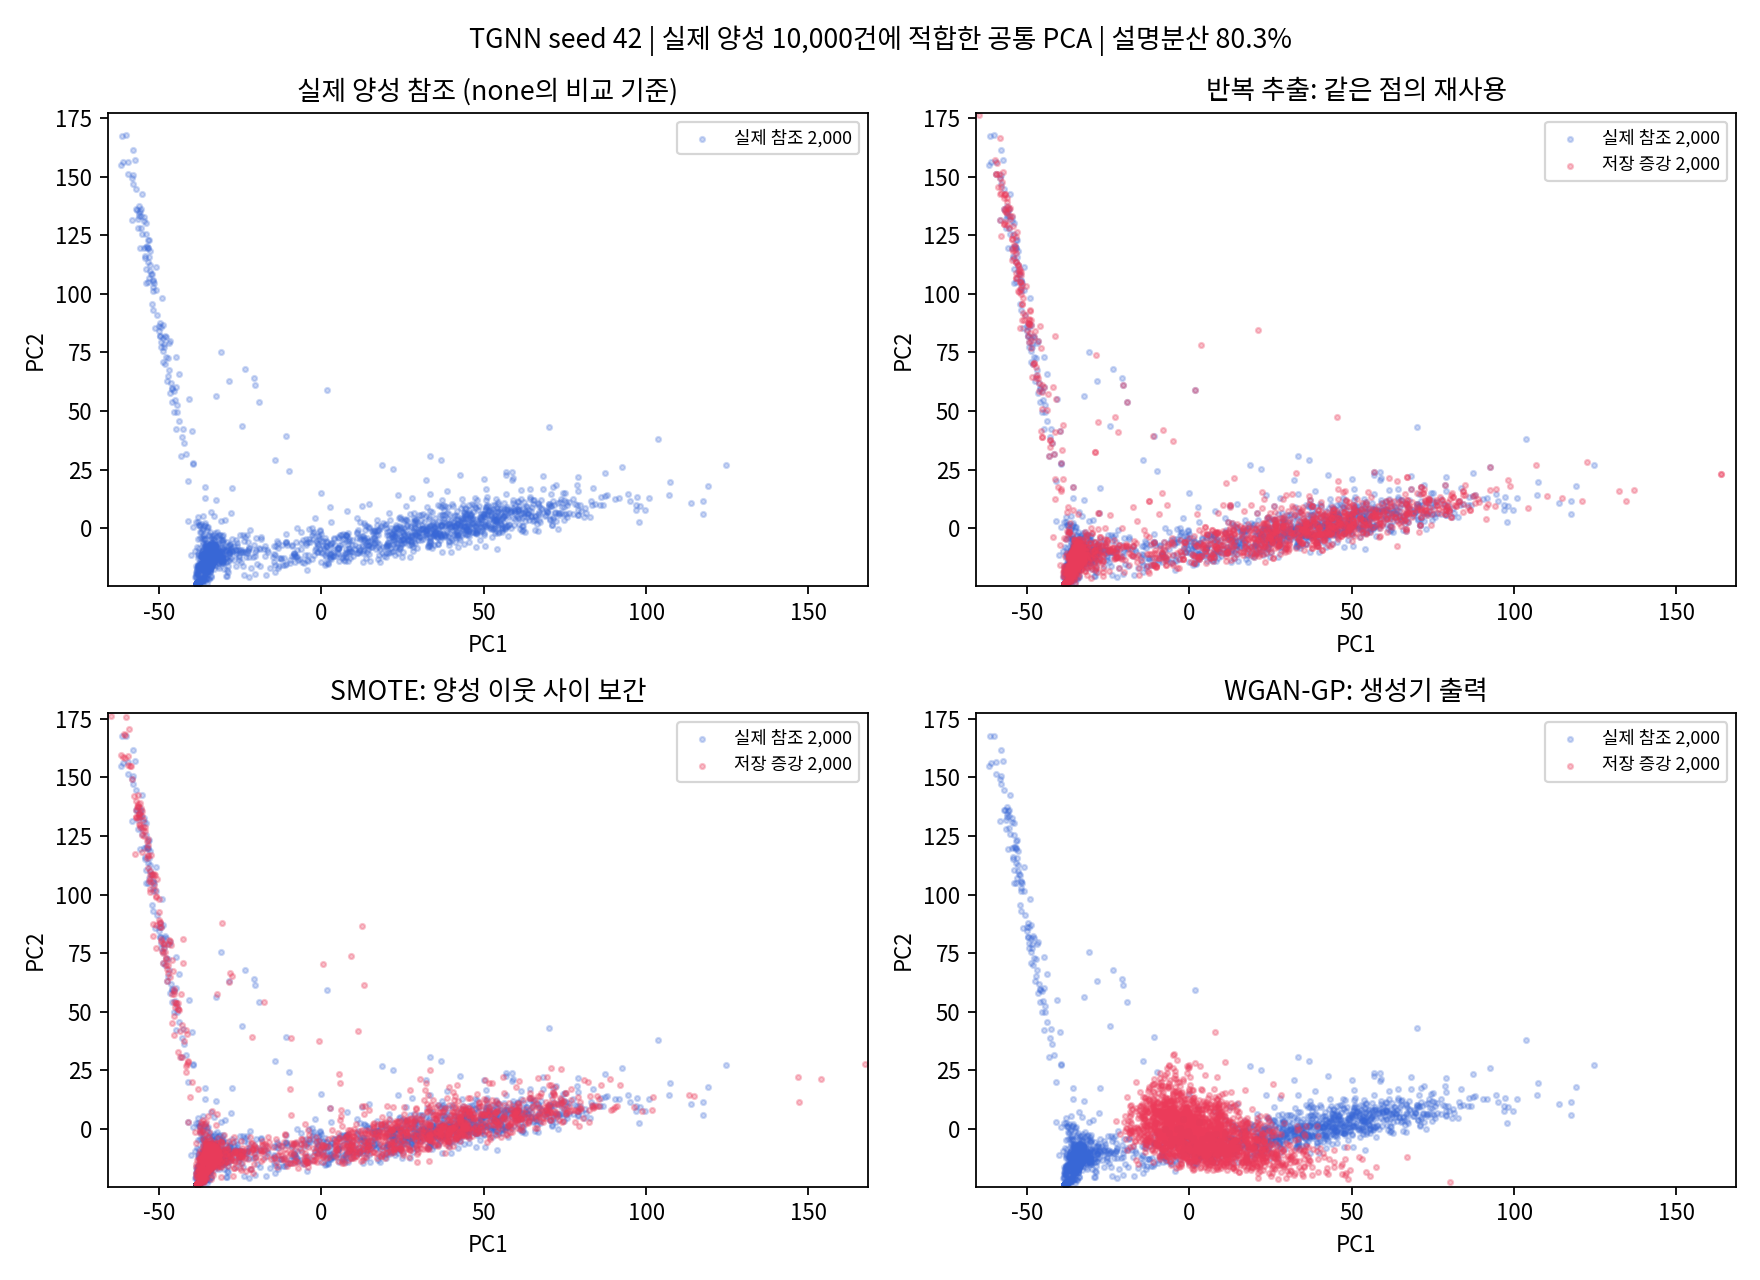

출처: `evidence_visuals/augmentation_pca.png` · SHA-256: `de6636935cae77ccd2a0c99c9dd8c08c8fb4baed40569e5bfe51fc49c5f894de`

## 기존 증강 품질 진단

128차원 표준화 공간에서 첫 2,048개 생성 표현의 실제 참조까지 최근접 거리와, 전체 생성 풀의 차원별 표준편차 비율 중앙값을 비교합니다. 반복 추출은 복제이므로 거리가 0인 것이 예상됩니다. SMOTE는 가까운 보간이고 GAN은 더 넓게 퍼질 수 있지만, 거리나 분산이 크다는 사실만으로 성능이 좋다는 결론을 내릴 수 없습니다.

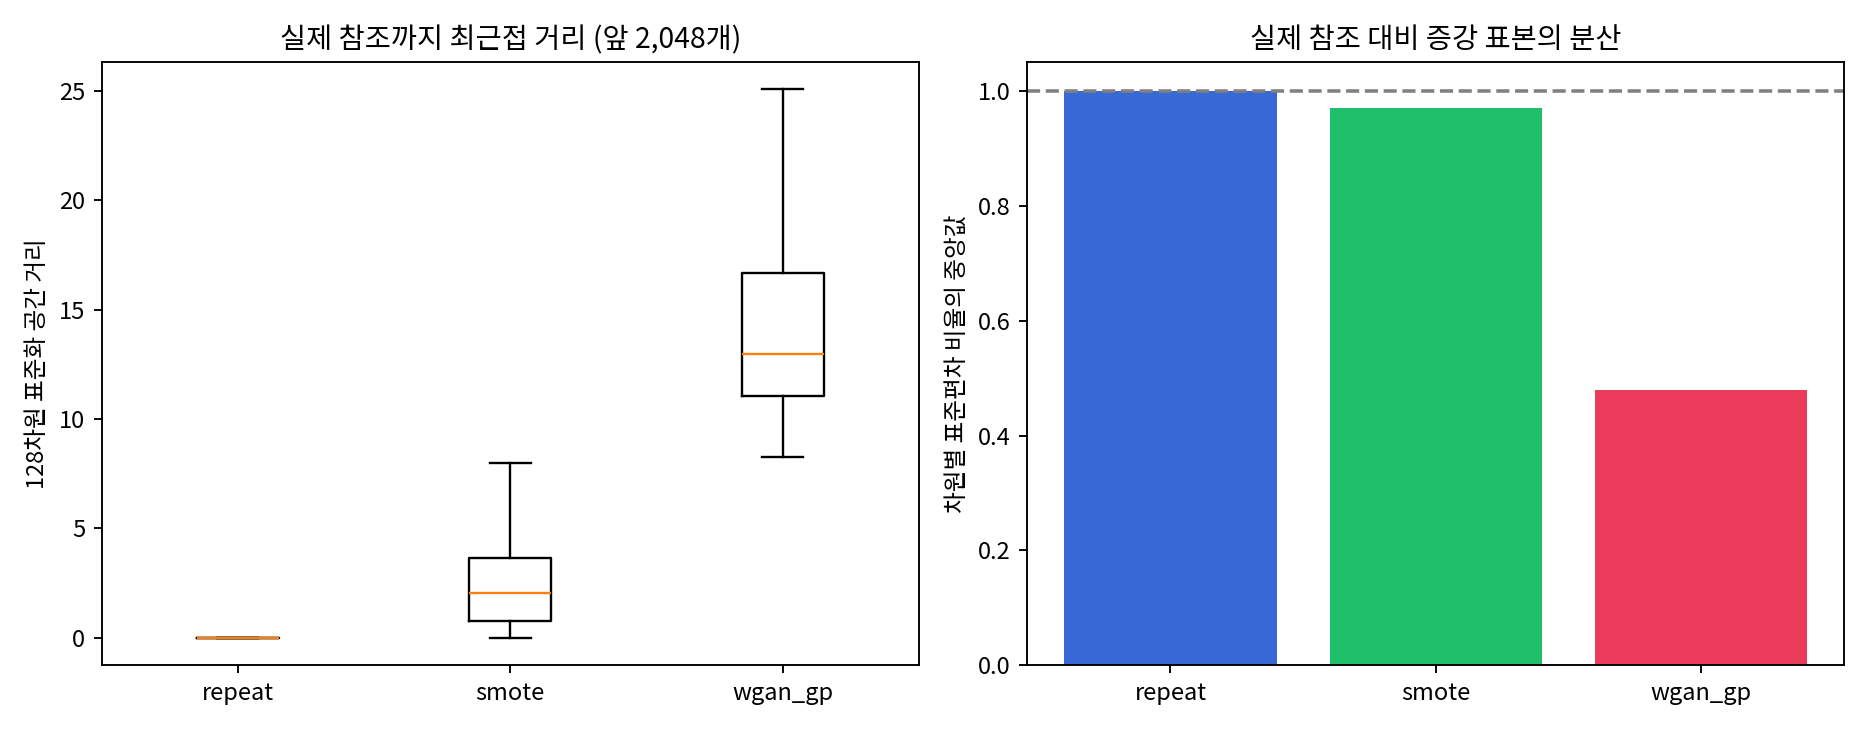

출처: `evidence_visuals/augmentation_diagnostics.png` · SHA-256: `c7606187ea73df143a67ef25104bf90da08aa339d001820ae66809575a5e4c56`

## 기존 감사 기록의 확인 항목

| 항목 | 저장된 확인 결과 |
|---|---:|
| 군집·표본 검사 날짜 수 | 68일 |
| 기존 군집 적합 참조 정상 수 | 208,896건 |
| 재예측 군집 ID 일치율 | 100% |
| 일별 KL 재계산 최대 절대 오차 | 9.93e-17 |
| 표현 파일 해시 확인 | 68개 |
| 저장 검증 점수 재현 최대 절대 오차 | 2.98e-07 |
| 저장 반복 추출 풀 재현 | True |
| 저장 SMOTE 풀 재현 | True |
| 기존 GAN 진단 건수 | 18 |
| 기존 진단 기준상 붕괴 판정 | 0건 |

저장된 테스트 로그에는 잠재공간 증강 구성요소 검사 **6개 통과**, 별도 원본 거래 반복 추출 실험 검사 **5개 통과**가 기록되어 있습니다. 후자의 원본 거래 반복 추출 실험 전체 코드는 이 통합본에 포함되지 않습니다. 기존 GAN 18건의 붕괴 판정 0건은 해당 휴리스틱 진단 결과이며, 모든 생성 표본이 현실적이라는 증명은 아닙니다.

**이번 통합본 실행:** 인공 데이터에서 GNN 6종 학습, 6종×4조건=24개 증강 비교, 코드 검사 5항목 및 모델별 데이터 분리/SMOTE 수식 검사를 통과했습니다. 독립 테스트셋 평가를 새로 수행하지 않았습니다.
